In [2]:
import pandas as pd
import numpy as np
import pyteomics
from pyteomics import fasta, auxiliary
from collections import defaultdict
from collections import Counter
import copy
import os
from os import path, listdir
import time
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.colors import to_rgba
from matplotlib.ticker import PercentFormatter
from matplotlib.gridspec import GridSpec
import seaborn as sns
# from matplotlib_venn import venn3, venn3_circles
# from pyteomics.openms import featurexml
# from venn import venn, draw_venn
from pyteomics.pylab_aux import plot_qvalue_curve
from scipy.optimize import curve_fit

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)

In [3]:
fasta_path = './fasta/human_ecoli_yeast_13072026.fasta'

h = 0
e = 0
y = 0
o = 0
i = 0
lfqbench_organism_dict = defaultdict(lambda :'Other')
with open(fasta_path, mode='r') as f:
    for descr, seq in fasta.read(f) :
        i += 1
        if len(descr.split('|')) > 2 :
            prot_id = descr.split('|')[1]
        else :
            prot_id = descr
        if 'HUMAN' in descr :
            lfqbench_organism_dict[prot_id] = 'Human'
            lfqbench_organism_dict[prot_id.split(' ')[0]] = 'Human'
            h += 1
        elif 'ECOLI' in descr :
            lfqbench_organism_dict[prot_id] = 'Ecoli'
            e += 1
        elif 'YEAST' in descr :
            lfqbench_organism_dict[prot_id] = 'Yeast'
            y += 1
        else :
            lfqbench_organism_dict[prot_id] = 'Other'
            # lfqbench_organism_dict['Other'].add(prot_id)
            o += 1
        # if 'A0ACI8SQ87' in descr :
        #     print(descr, seq)
print(h, e, y, o)

20652 4403 6066 0


# UPS-E.coli by quantitation (all comparisons) Fig 1D

In [198]:
comp_pairs_labels = ['50 / 25', '50 / 10', '50 / 5', '50 / 2_5', '50 / 1', '50 / 0_25', '50 / 0_1', 
                     '25 / 10', '25 / 5', '25 / 2_5', '25 / 1', '25 / 0_25', '25 / 0_1', 
                     '10 / 5', '10 / 2_5', '10 / 1', '10 / 0_25', '10 / 0_1', 
                     '5 / 2_5', '5 / 1', '5 / 0_25', '5 / 0_1', 
                     '2_5 / 1', '2_5 / 0_25', '2_5 / 0_1', 
                     '1 / 0_25', '1 / 0_1', 
                     '0_25 / 0_1'
                    ]
quant_tools = ['quant_alphastats', 'quant_directlfq', 'quant_manual', 'triqler', 'triqler_opt', ]
folders = ['diann231_ups_ecoli', 'fragpipe24_ups_ecoli_msfragger', 'fragpipe24_ups_ecoli_umpire']
search_engines = {'diann231_ups_ecoli':'DIA-NN', 
                  'fragpipe24_ups_ecoli_umpire':'DIA-Umpire',
                  'fragpipe24_ups_ecoli_msfragger':'MSFragger-DIA'}
search_engines_short = {'diann231_ups_ecoli':'diann', 
                        'fragpipe24_ups_ecoli_umpire':'dia-umpire', 
                        'fragpipe24_ups_ecoli_msfragger':'msfragger'}
quant_tools_short = {'Manual':'quant_manual', 'directLFQ':'quant_directlfq', 'AlphaPeptStats':'quant_alphastats', 'Triqler':'triqler', 'Triqler*':'triqler_opt'}
quant_tools = ['AlphaPeptStats', 'directLFQ', 'Manual', 'Triqler', 'Triqler*']
alphastats_imp = 'randomforest'
imputation = {'AlphaPeptStats':'_'+alphastats_imp, 'directLFQ':'_min', 'Manual':'_min', 'Triqler':'', 'Triqler*':''}
quant_dr = './quantitation'

In [199]:
ups_DE = {}
ecoli_DE = {}
all_DE = {}
for quant in quant_tools_short :
    ups_DE[quant] = {}
    ecoli_DE[quant] = {}
    all_DE[quant] = {}
    for tool_folder in folders :
        ups_DE[quant][tool_folder] = {}
        ecoli_DE[quant][tool_folder] = {}
        all_DE[quant][tool_folder] = {}
        for label in comp_pairs_labels :
            conc_1, conc_2 = label.split(' / ')
            fname = '_'.join([conc_1+'fmol_vs_'+conc_2+'fmol',
                              quant_tools_short[quant],  
                             ]) + imputation[quant] + '.tsv'
            tdf = pd.read_csv(path.join(quant_dr, tool_folder, fname), sep='\t')
            
            all_DE[quant][tool_folder][label] = len(tdf[(tdf['FDR_pass'] & tdf['FC_pass'])])
            ups_DE[quant][tool_folder][label] = len(tdf[(tdf['Human'] & tdf['FDR_pass'] & tdf['FC_pass'])])
            ecoli_DE[quant][tool_folder][label] = len(tdf[(tdf['Ecoli'] & tdf['FDR_pass'] & tdf['FC_pass'])])

In [200]:
ups_DE['Manual']['diann231_ups_ecoli']['25 / 5']

41

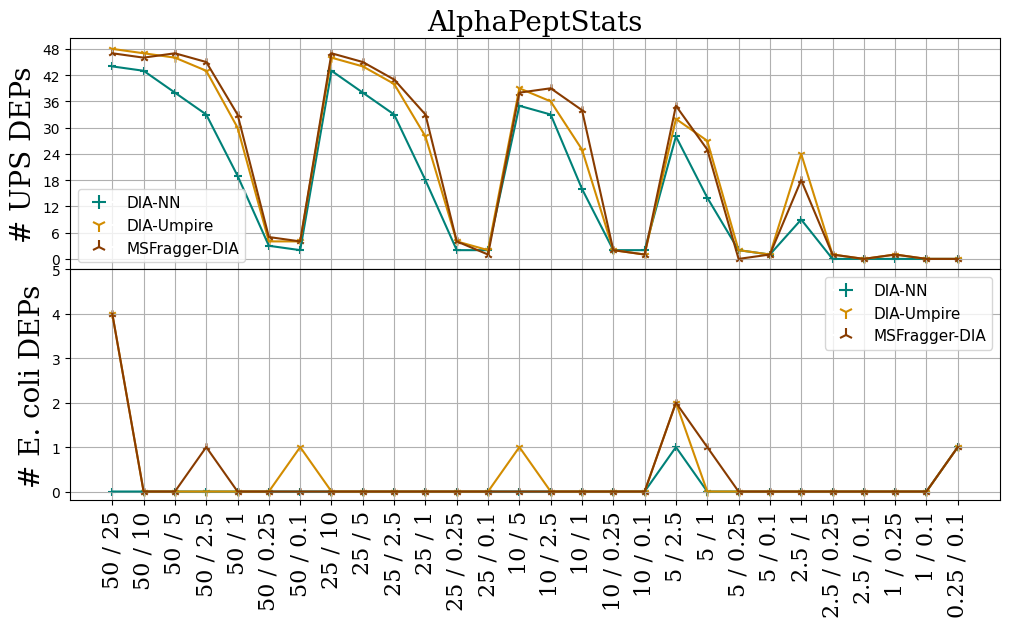

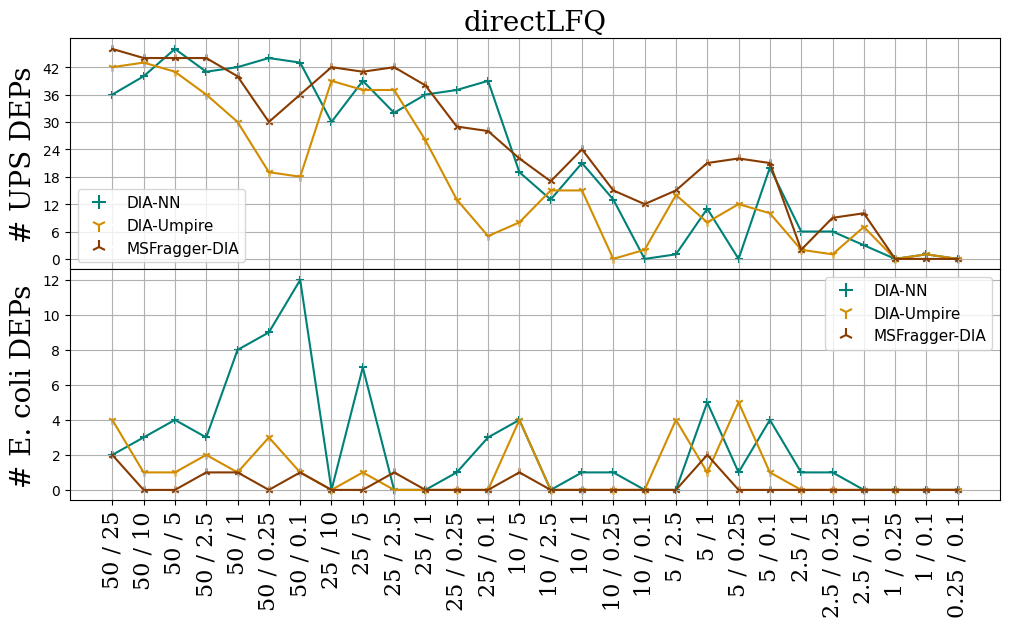

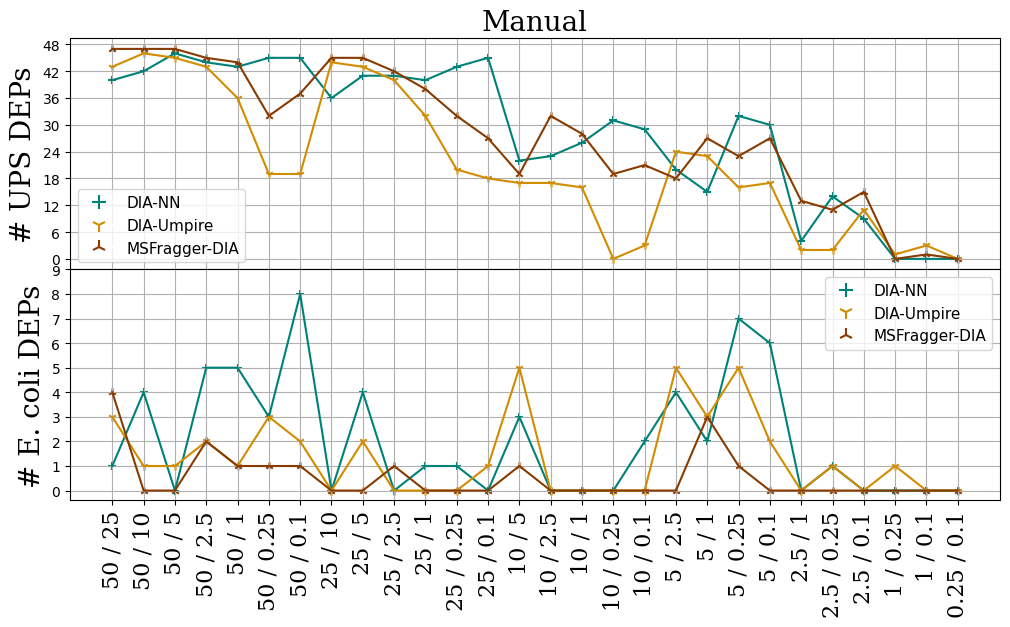

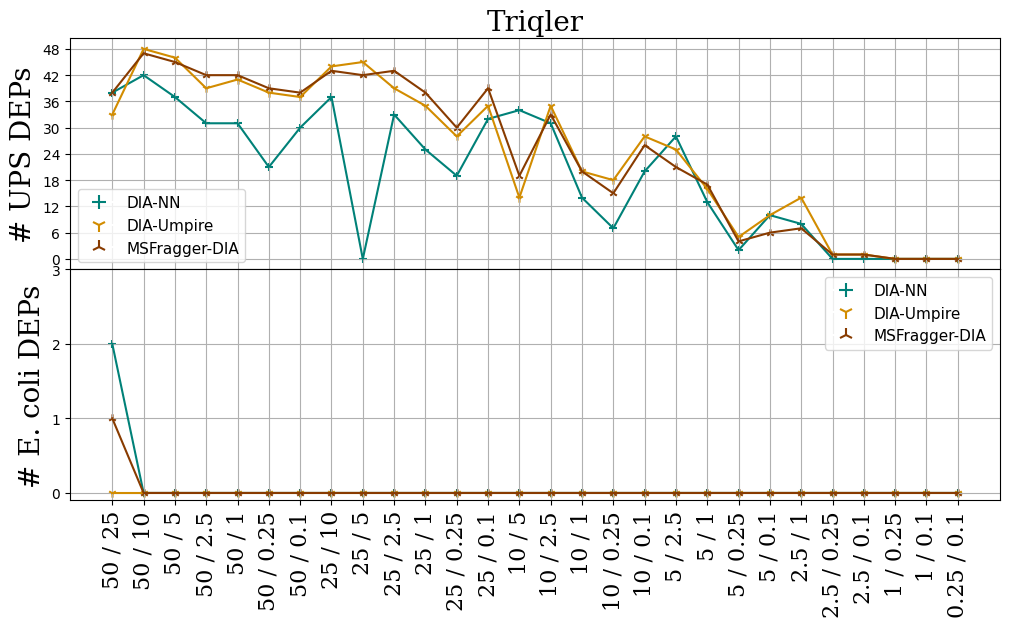

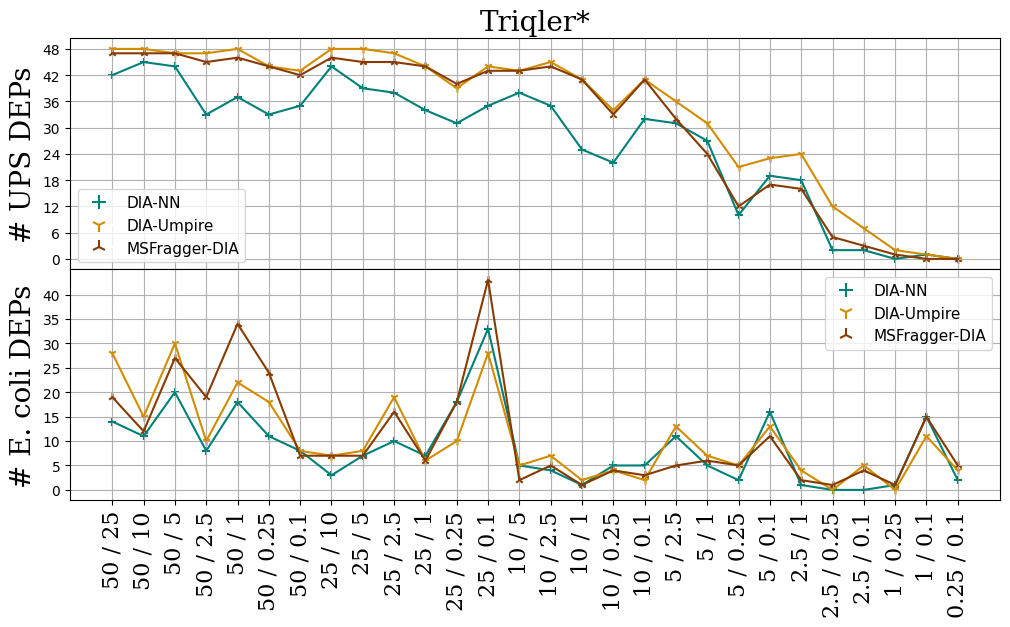

In [201]:
colors = ['#008178', '#D28C00', '#883B00', '#6482C6', '#0F358D']
legend_elements = [
    Line2D([0], [0], color = 'w', markerfacecolor = colors[0], marker = '+', markersize = 10,
              markeredgecolor = colors[0],  markeredgewidth = 1.5, label = 'DIA-NN'),
    Line2D([0], [0], color = 'w', markerfacecolor = colors[1], marker = '1', markersize = 10,
              markeredgecolor = colors[1],  markeredgewidth = 1.5, label = 'DIA-Umpire'),
    Line2D([0], [0], color = 'w', markerfacecolor = colors[2], marker = '2', markersize = 10,
              markeredgecolor = colors[2],  markeredgewidth = 1.5, label = 'MSFragger-DIA'),
    # Line2D([0], [0], color = 'w', markerfacecolor = colors[3], marker = '3', markersize = 10,
    #           markeredgecolor = colors[3],  markeredgewidth = 1.5, label = 'Triqler'),
]

for quant in quant_tools :

    fig, axes = plt.subplots(2, 1, figsize=(12, 6))
    
    dicts = (ups_DE, ecoli_DE)
    yticks = [np.arange(0, 50, 4), np.arange(0, 20, 2)]
    ylabels = ['# UPS DEPs', '# E. coli DEPs']
    legend_positions = ['lower left','upper right', ]
    for ax, DE_dict, ytick, ylabel, legend_pos in zip(axes, dicts, yticks, ylabels, legend_positions) :
        csfont = {'fontname':'serif'}
        # fig.suptitle('Ratio of false positive DE proteins', fontsize = 32)
        mxy = 0
        for tool_folder, color, marker in zip(folders, colors, ['+', '1', '2', '3', '4']) :
            y = [DE_dict[quant][tool_folder][label] for label in comp_pairs_labels]
            if max(y) > mxy :
                mxy = max(y)
            x = [i for i in range(0, 2*len(comp_pairs_labels), 2)]
        
            ax.scatter(x, y, color=color, marker=marker)
            ax.plot(x, y, color=color, )
        
            if ax == axes[-1]:
                ax.set_xticks([i for i in range(0, 2*len(comp_pairs_labels), 2)], labels=[label.replace('_', '.') for label in comp_pairs_labels], **csfont)
                ax.tick_params(axis='x', which='major', labelsize=16, rotation=90)
            else :
                ax.set_xticks([i for i in range(0, 2*len(comp_pairs_labels), 2)],)
                ax.tick_params(axis='x', which='major', tick1On=False, label1On=False,)
            if ax == axes[0] :
                ax.set_title(quant, size = 20, **csfont)
        if mxy == 0 :
            mxy = 8
        ax.legend(handles = legend_elements, fontsize = 11, markerscale = 1, loc=legend_pos)
        ax.set_yticks(np.arange(0, mxy+2, max(round(mxy/8), 1)))
        ax.set_ylabel(ylabel, size = 20, **csfont )
        ax.grid()
    # ax.set_xlabel(r'', size = 28)
    ax.tick_params(axis='x', which='major', labelsize=16, rotation=90)
    # ax.tick_params(axis='y', which='major', labelsize=16, )
    fig.subplots_adjust(hspace=0.,)
    fig.savefig('./figures/ups_scatter_{}.svg'.format(quant_tools_short[quant]), bbox_inches='tight')

# UPS-E.coli by search engine (all comparisons) Fig 2A

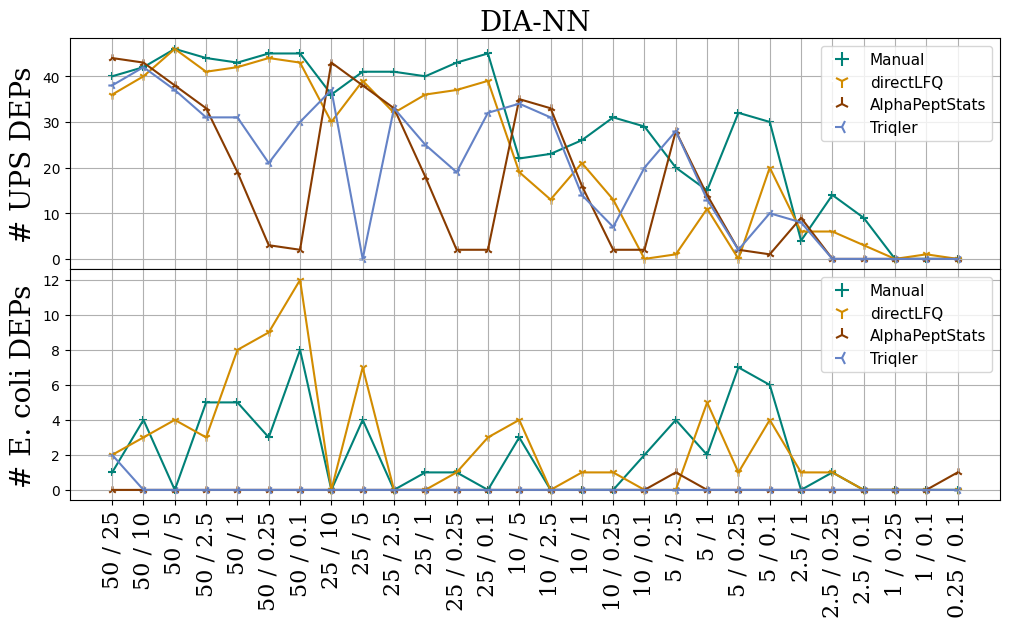

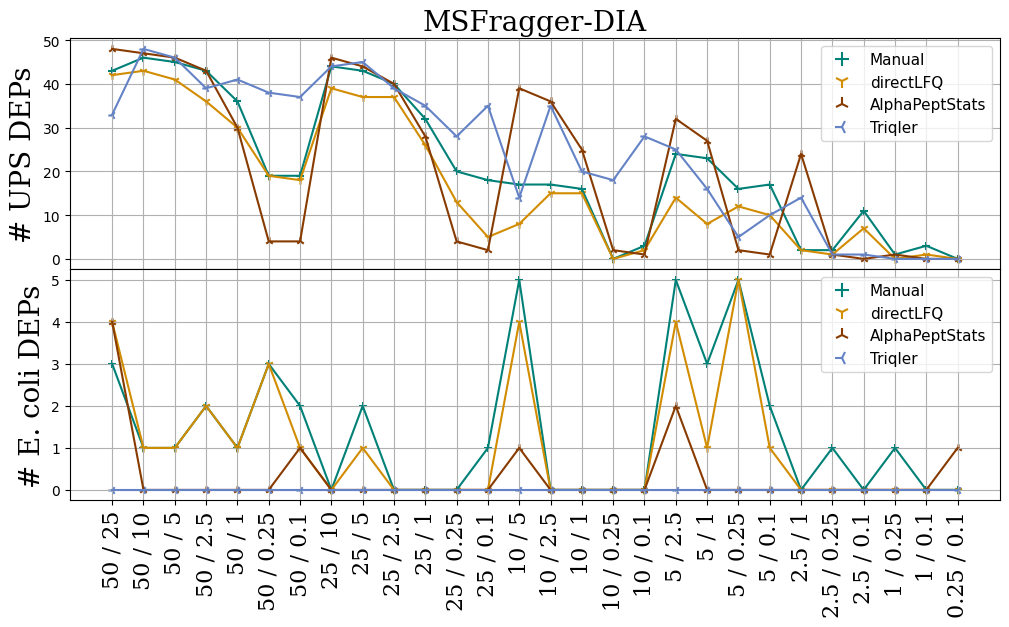

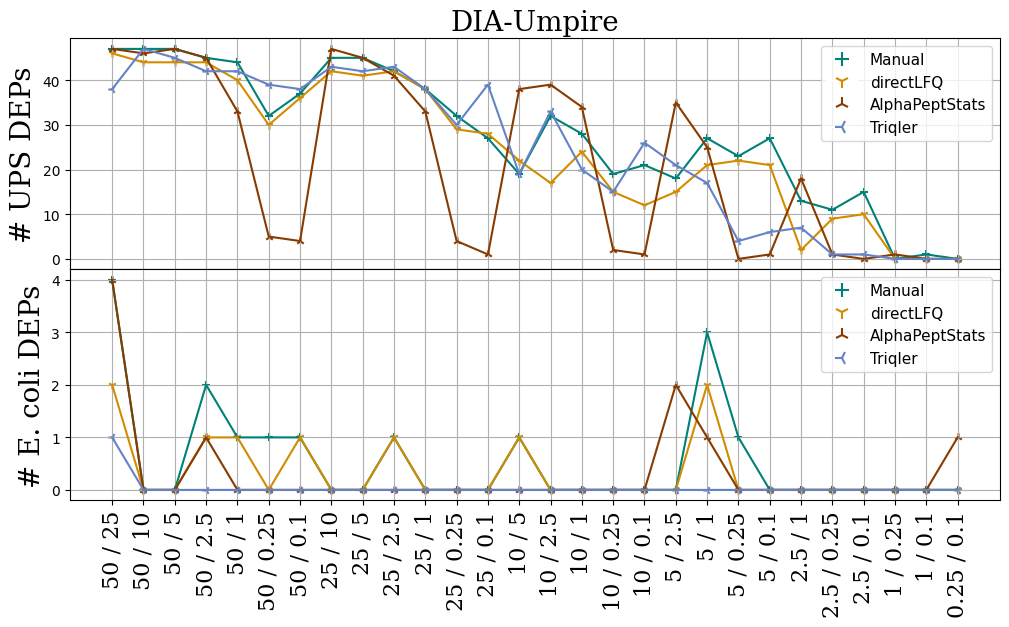

In [202]:
colors = ['#008178', '#D28C00', '#883B00', '#6482C6', '#0F358D']
legend_elements = [
    Line2D([0], [0], color = 'w', markerfacecolor = colors[0], marker = '+', markersize = 10,
              markeredgecolor = colors[0],  markeredgewidth = 1.5, label = 'Manual'),
    Line2D([0], [0], color = 'w', markerfacecolor = colors[1], marker = '1', markersize = 10,
              markeredgecolor = colors[1],  markeredgewidth = 1.5, label = 'directLFQ'),
    Line2D([0], [0], color = 'w', markerfacecolor = colors[2], marker = '2', markersize = 10,
              markeredgecolor = colors[2],  markeredgewidth = 1.5, label = 'AlphaPeptStats'),
    Line2D([0], [0], color = 'w', markerfacecolor = colors[3], marker = '3', markersize = 10,
              markeredgecolor = colors[3],  markeredgewidth = 1.5, label = 'Triqler'),
]

for tool_folder in folders :
# for tool_folder in folders[:1] :

    fig, axes = plt.subplots(2, 1, figsize=(12, 6))
    
    dicts = (ups_DE, ecoli_DE)
    yticks = [np.arange(0, 50, 4), np.arange(0, 20, 2)]
    ylabels = ['# UPS DEPs', '# E. coli DEPs']
    legend_positions = ['upper right','upper right', ]
    # legend_positions = ['lower left','upper right', ]
    for ax, DE_dict, ytick, ylabel, legend_pos in zip(axes, dicts, yticks, ylabels, legend_positions) :
        csfont = {'fontname':'serif'}
        # fig.suptitle('Ratio of false positive DE proteins', fontsize = 32)
        mxy = 0
        for quant, color, marker in zip(quant_tools_short, colors, ['+', '1', '2', '3']) :
        # for quant, color, marker in zip(['Manual'], colors, ['+', '1', '2', '3']) :
            # print(quant, color)
            # print(quant, tool_folder, label, DE_dict[quant][tool_folder][label])
            y = [DE_dict[quant][tool_folder][label] for label in comp_pairs_labels]
            if max(y) > mxy :
                mxy = max(y)
            x = [i for i in range(0, 2*len(comp_pairs_labels), 2)]
        
            ax.scatter(x, y, color=color, marker=marker)
            ax.plot(x, y, color=color, )
        
            if ax == axes[-1]:
                ax.set_xticks([i for i in range(0, 2*len(comp_pairs_labels), 2)], labels=[label.replace('_', '.') for label in comp_pairs_labels], **csfont)
                ax.tick_params(axis='x', which='major', labelsize=16, rotation=90)
            else :
                ax.set_xticks([i for i in range(0, 2*len(comp_pairs_labels), 2)],)
                ax.tick_params(axis='x', which='major', tick1On=False, label1On=False,)
            if ax == axes[0] :
                ax.set_title(search_engines[tool_folder], size = 20, **csfont)
        ax.legend(handles = legend_elements, fontsize = 11, markerscale = 1, loc=legend_pos)
        # ax.set_yticks(np.arange(0, mxy+2, round(mxy/8)))
        ax.set_ylabel(ylabel, size = 20, **csfont )
        ax.grid()
    # ax.set_xlabel(r'', size = 28)
    ax.tick_params(axis='x', which='major', labelsize=16, rotation=90)
    # ax.tick_params(axis='y', which='major', labelsize=16, )
    fig.subplots_adjust(hspace=0.,)
    fig.savefig('./figures/ups_scatter_{}.svg'.format(search_engines_short[tool_folder]), format='svg', bbox_inches='tight')

# UPS-Ecoli q-value plots 3x3

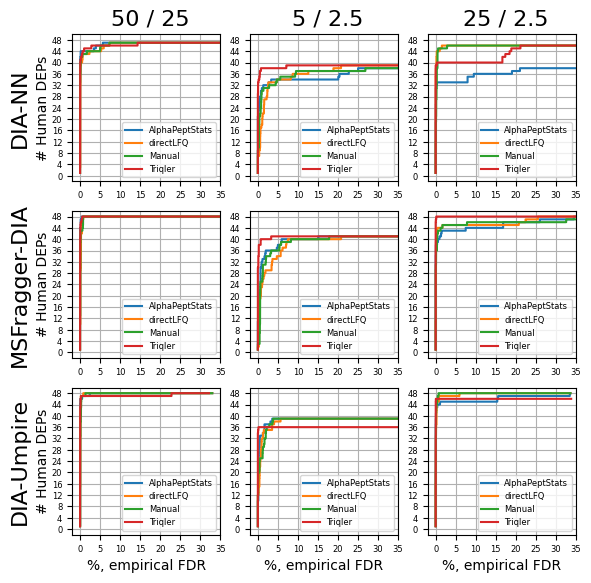

In [204]:
# %%capture stderr
dr = './quantitation'
organisms = ['Ecoli', 'Human'] # 'Yeast'
comp_pairs_labels = ['50 / 25', '50 / 10', '50 / 5', '50 / 2_5', '50 / 1', '50 / 0_25', '50 / 0_1', 
                     '25 / 10', '25 / 5', '25 / 2_5', '25 / 1', '25 / 0_25', '25 / 0_1', 
                     '10 / 5', '10 / 2_5', '10 / 1', '10 / 0_25', '10 / 0_1', 
                     '5 / 2_5', '5 / 1', '5 / 0_25', '5 / 0_1', 
                     '2_5 / 1', '2_5 / 0_25', '2_5 / 0_1', 
                     '1 / 0_25', '1 / 0_1', 
                     '0_25 / 0_1'
                    ]
quant_tools = ['quant_alphastats', 'quant_directlfq', 'quant_manual', 'triqler', ]
folders = ['diann231_ups_ecoli', 'fragpipe24_ups_ecoli_msfragger', 'fragpipe24_ups_ecoli_umpire']
search_engines = {'diann231_ups_ecoli':'DIA-NN', 
                  'fragpipe24_ups_ecoli_umpire':'DIA-Umpire',
                  'fragpipe24_ups_ecoli_msfragger':'MSFragger-DIA'}
search_engines_short = {'diann231_ups_ecoli':'diann', 
                        'fragpipe24_ups_ecoli_umpire':'dia-umpire', 
                        'fragpipe24_ups_ecoli_msfragger':'msfragger'}
quant_tools_short = {'Manual':'quant_manual', 'directLFQ':'quant_directlfq', 'AlphaPeptStats':'quant_alphastats', 'Triqler':'triqler', }
quant_tools = ['AlphaPeptStats', 'directLFQ', 'Manual', 'Triqler']
alphastats_imp = 'randomforest'
imputation = {'AlphaPeptStats':'_'+alphastats_imp, 'directLFQ':'_min', 'Manual':'_min', 'Triqler':'',}
quant_dr = './quantitation'

fdr_col = {'Manual':'pval', 'directLFQ':'pval', 'AlphaPeptStats':'pval','Triqler':'q_value'}
fdr_pass = defaultdict(lambda:'FDR_pass')
fc_col = {'manual':'log2_FC', 'directlfq':'log2_FC', 'alphastats':'log2fc','triqler':'log2_FC'}
fc_pass = 'FC_pass'

cm = 1/2.54

fig, axes = plt.subplots(3, 3, figsize=(6.5, 6.5))
i = 0
for tool_folder, axe in zip(folders, axes) :
    j = 0
    for label, ax in zip(['50 / 25', '5 / 2_5', '25 / 2_5' ], axe) :
        for quant in quant_tools :
            conc_1, conc_2 = label.split(' / ')
            fname = '_'.join([conc_1+'fmol_vs_'+conc_2+'fmol',
                              quant_tools_short[quant],  
                             ]) + imputation[quant] + '.tsv'
            tdf = pd.read_csv(path.join(quant_dr, tool_folder, fname), sep='\t')
            # tdf['FDR_pass'] = tdf[fdr[quant]]
            if 'protein' in tdf.columns :
                tdf['True_DE'] = tdf['protein'].map(lambda x: 'human' in x.lower()) #& tdf['FC_pass'] # & tdf['FDR_pass']
            else :
                tdf['True_DE'] = tdf['Protein.Group'].map(lambda x: 'human' in x.lower()) # & tdf['FC_pass'] # & tdf['FDR_pass']
            tdf['comparison'] = [label for _ in range(len(tdf)) ]
            tdf['cumulative_num_DE'] = tdf['True_DE'].cumsum()
            # tdf['cumulative_num_false_DE'] = (~tdf['True_DE']).cumsum()
            # tdf['real_fdr'] = tdf['cumulative_num_false_DE'] / (tdf['cumulative_num_false_DE'] + tdf['cumulative_num_DE'])
            tdf['real_fdr'] = auxiliary.target_decoy._calculate_qvalues(scores=tdf[fdr_col[quant]].to_numpy(), isdecoy=~tdf['True_DE'].to_numpy(), 
                                                                      remove_decoy=False, 
                                                                      formula=1,  # 1 for (decoy+1)/target
                                                                      correction=0)

            ax.plot(tdf['real_fdr'], tdf['cumulative_num_DE'], label=quant)
        ax.set_xlim([-2, 35])
        ax.set_xticks(list(np.arange(0, 40, 5)) )
        ax.set_ylim([-2, 50])
        ax.set_yticks(list(np.arange(0, 50, 4)) )
        ax.tick_params(axis='both', labelsize=6)
        # ax.set_xlabel('%, empirical FDR', size=10)
        # ax.set_ylabel('# Human DEPs', size=10)
        # ax.set_title(search_engines[tool_folder] + ' ' + label, size=4)
        ax.grid()
        ax.legend(loc='lower right', fontsize=6)
        if j == 0 :
            ax.text(-15, 24, search_engines[tool_folder], size=16, rotation=90, ha='center', va='center')
            ax.set_ylabel('# Human DEPs', size=10, labelpad=1.5)
        else :
            ax.set_ylabel('', size=10)
        if i == 0 :
            ax.text(17.5, 53, label.replace('_', '.'), size=16, ha='center')
            ax.set_xlabel('', size=10)
        elif i == 2 :
            ax.set_xlabel('%, empirical FDR', size=10)
        else :
            ax.set_xlabel('', size=10)
        j += 1
    i += 1

# savepath = './figures/ups_qval_3x3.svg'
# fig.savefig(savepath, format='svg', bbox_inches='tight')
fig.show()

# UPS-E.coli Triqler DIA-NN options comparison Fig 2C

In [227]:
comp_pairs_labels = ['50 / 25', '50 / 10', '50 / 5', '50 / 2_5', '50 / 1', '50 / 0_25', '50 / 0_1', 
                     '25 / 10', '25 / 5', '25 / 2_5', '25 / 1', '25 / 0_25', '25 / 0_1', 
                     '10 / 5', '10 / 2_5', '10 / 1', '10 / 0_25', '10 / 0_1', 
                     # '5 / 2_5', '5 / 1', '5 / 0_25', '5 / 0_1', 
                     # '2_5 / 1', '2_5 / 0_25', '2_5 / 0_1', 
                     # '1 / 0_25', '1 / 0_1', 
                     # '0_25 / 0_1'
                    ]
quant_tools = ['triqler', 'triqler_opt','triqler_opt_double_fasta', 'triqler_double_fasta']
# quant_tools = ['triqler', 'triqler_opt', 'triqler_mins2', 'triqler_opt_double_fasta', 'triqler_double_fasta']

folders = ['diann231_ups_ecoli',]
search_engines = {'diann231_ups_ecoli':'DIA-NN',} 
                  # 'fragpipe24_ups_ecoli_umpire':'DIA-Umpire',
                  # 'fragpipe24_ups_ecoli_msfragger':'MSFragger-DIA'}
search_engines_short = {'diann231_ups_ecoli':'diann',} 
                        # 'fragpipe24_ups_ecoli_umpire':'dia-umpire', 
                        # 'fragpipe24_ups_ecoli_msfragger':'msfragger'}
quant_tools_short = {'Min. samples 3\nFC threshold standart':'triqler', 
                     'Min. samples 3\nFC threshold optimized':'triqler_opt', 
                     # 'Min. samples 2\nFC threshold standart':'triqler_mins2', 
                     'Min. samples 3\nFC threshold standart\ndouble decoys':'triqler_double_fasta', 
                     # 'Min. samples 3\nFC threshold optimized\ndouble decoys':'triqler_opt_double_fasta'
                    }
quant_tools = ['AlphaPeptStats', 'directLFQ', 'Manual', 'Triqler', 'Triqler*']
alphastats_imp = 'randomforest'
imputation = defaultdict(lambda :'')
# imputation = {'Triqler':'', 'Triqler*':''}
quant_dr = './quantitation'

In [228]:
ups_DE = {}
ecoli_DE = {}
all_DE = {}
for quant in quant_tools_short :
    ups_DE[quant] = {}
    ecoli_DE[quant] = {}
    all_DE[quant] = {}
    for tool_folder in folders :
        ups_DE[quant][tool_folder] = {}
        ecoli_DE[quant][tool_folder] = {}
        all_DE[quant][tool_folder] = {}
        for label in comp_pairs_labels :
            conc_1, conc_2 = label.split(' / ')
            fname = '_'.join([conc_1+'fmol_vs_'+conc_2+'fmol',
                              quant_tools_short[quant],  
                             ]) + imputation[quant] + '.tsv'
            tdf = pd.read_csv(path.join(quant_dr, tool_folder, fname), sep='\t')
            
            all_DE[quant][tool_folder][label] = len(tdf[(tdf['FDR_pass'] & tdf['FC_pass'])])
            ups_DE[quant][tool_folder][label] = len(tdf[(tdf['Human'] & tdf['FDR_pass'] & tdf['FC_pass'])])
            ecoli_DE[quant][tool_folder][label] = len(tdf[(tdf['Ecoli'] & tdf['FDR_pass'] & tdf['FC_pass'])])

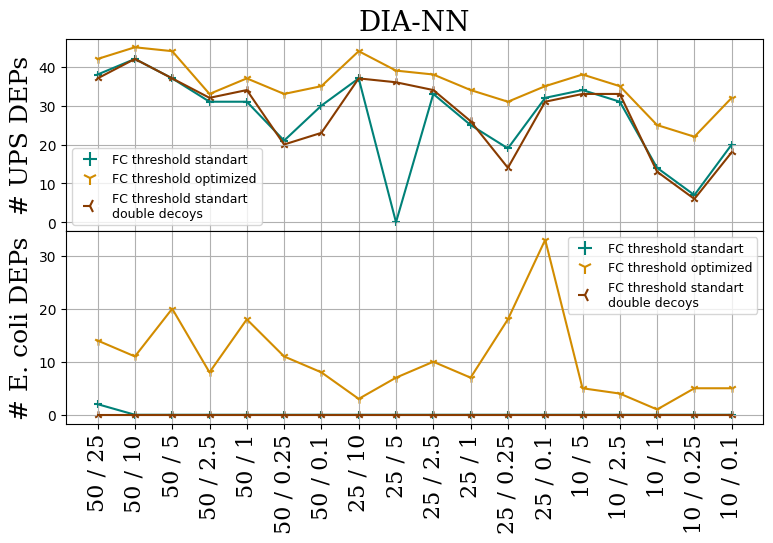

In [230]:
colors = ['#008178', '#D28C00', '#883B00', '#6482C6', '#0F358D']
legend_elements = [
    Line2D([0], [0], color = 'w', markerfacecolor = colors[0], marker = '+', markersize = 10,
              markeredgecolor = colors[0],  markeredgewidth = 1.5, label = 'FC threshold standart'),
    Line2D([0], [0], color = 'w', markerfacecolor = colors[1], marker = '1', markersize = 10,
              markeredgecolor = colors[1],  markeredgewidth = 1.5, label = 'FC threshold optimized'),
    # Line2D([0], [0], color = 'w', markerfacecolor = colors[2], marker = '2', markersize = 10,
    #           markeredgecolor = colors[2],  markeredgewidth = 1.5, label = 'Min. samples 2\nFC threshold standart'),
    Line2D([0], [0], color = 'w', markerfacecolor = colors[2], marker = '3', markersize = 10,
              markeredgecolor = colors[2],  markeredgewidth = 1.5, label = 'FC threshold standart\ndouble decoys'),
    # Line2D([0], [0], color = 'w', markerfacecolor = colors[4], marker = '4', markersize = 10,
    #           markeredgecolor = colors[4],  markeredgewidth = 1.5, label = 'Min. samples 3\nFC threshold optimized\ndouble decoys'),
]
count = 0
for tool_folder in folders :
# for tool_folder in folders[:1] :

    fig, axes = plt.subplots(2, 1, figsize=(9, 5))
    
    dicts = (ups_DE, ecoli_DE)
    yticks = [np.arange(0, 50, 4), np.arange(0, 20, 2)]
    ylabels = ['# UPS DEPs', '# E. coli DEPs']
    legend_positions = ['lower left','upper right', ]
    # legend_positions = ['lower left','upper right', ]
    for ax, DE_dict, ytick, ylabel, legend_pos in zip(axes, dicts, yticks, ylabels, legend_positions) :
        csfont = {'fontname':'serif'}
        # fig.suptitle('Ratio of false positive DE proteins', fontsize = 32)
        mxy = 0
        for quant, color, marker in zip(quant_tools_short, colors, ['+', '1', '2', '3', '4']) :
        # for quant, color, marker in zip(['Manual'], colors, ['+', '1', '2', '3']) :
            # print(quant, color)
            # print(quant, tool_folder, label, DE_dict[quant][tool_folder][label])
            y = [DE_dict[quant][tool_folder][label] for label in comp_pairs_labels]
            if max(y) > mxy :
                mxy = max(y)
            x = [i for i in range(0, 2*len(comp_pairs_labels), 2)]
        
            ax.scatter(x, y, color=color, marker=marker)
            ax.plot(x, y, color=color, )
        
            if ax == axes[-1]:
                ax.set_xticks([i for i in range(0, 2*len(comp_pairs_labels), 2)], labels=[label.replace('_', '.') for label in comp_pairs_labels], **csfont)
                ax.tick_params(axis='x', which='major', labelsize=16, rotation=90)
            else :
                ax.set_xticks([i for i in range(0, 2*len(comp_pairs_labels), 2)],)
                ax.tick_params(axis='x', which='major', tick1On=False, label1On=False,)
            if ax == axes[0] :
                ax.set_title(search_engines[tool_folder], size = 20, **csfont)
        count += 1
        ax.legend(handles = legend_elements, fontsize = 9, markerscale = 1, loc=legend_pos)
        # ax.set_yticks(np.arange(0, mxy+2, round(mxy/8)))
        ax.set_ylabel(ylabel, size = 18, **csfont )
        ax.grid()
    # ax.set_xlabel(r'', size = 28)
    ax.tick_params(axis='x', which='major', labelsize=16, rotation=90)
    # ax.tick_params(axis='y', which='major', labelsize=16, )
    fig.subplots_adjust(hspace=0.,)
    fig.savefig('./figures/ups_scatter_triqler_comp.svg', format='svg', bbox_inches='tight')

# Heatmap of DEPs LFQbench 

In [19]:
folder = './quantitation'
quant_tools = ['manual', 'directlfq', 'alphastats','triqler']
search_engines = {'diann':'DIA-NN', 
                  'umpire':'DIA-Umpire', 
                  'msfragger':'MSFragger-DIA'}

search_engines_file_mask = {  'diann':'diann231_LFQbench_quant_{}{}.tsv', 
                              'umpire':'fragpipe24_LFQbench_umpire_quant_{}{}.tsv', 
                              'msfragger':'fragpipe24_LFQbench_msfragger_quant_{}{}.tsv'}

quant_tools_full = {'manual':'Manual', 'directlfq':'directLFQ', 'alphastats':'AlphaPeptStats', 'triqler':'Triqler'}
alphastats_imp = 'randomforest'
imputation = {'alphastats':'_'+alphastats_imp, 'directlfq':'_min', 'manual':'_min', 'triqler':''}
fdr_pass = defaultdict(lambda:'FDR_pass')
organisms = ['Human', 'Yeast', 'Ecoli']
# print(quant_tools, search_engines)
deps = {}
for search_engine in search_engines :
    deps[search_engine] = {}
    for quant_tool in quant_tools :
        print(search_engine, quant_tool)
        deps[search_engine][quant_tool] = {'Ecoli':0, 'Yeast':0, 'Human':0 }
        filepath = path.join(folder, search_engines_file_mask[search_engine].format(quant_tool, imputation[quant_tool]))
        if quant_tool == 'triqler' and not 'diann' in search_engine :
            filepath = filepath.replace('_quant', '_triqler')
        elif quant_tool == 'triqler' :
            filepath = filepath.replace('_quant', '')
        df = pd.read_csv(filepath, sep='\t')

        for org in organisms :
            deps[search_engine][quant_tool][org] = len(df[(df['Organism'] == org) & (df[fdr_pass[quant_tool]]) & (df['FC_pass'])])
            # fc_range = np.abs(df[(df['Organism'] == org) & (df[fdr_pass[quant_tool]]) & (df['FC_pass'])]['log2_FC'].max() - df[(df['Organism'] == org) & (df[fdr_pass[quant_tool]]) & (df['FC_pass'])]['log2_FC'].min())
        # print(fname, df['Search Engine'][0], df['Quantitation'][0], df['Imputation'][0], *[deps[search_engine][quant_tool][org] for org in organisms], sep='\t')
        print(filepath, fdr_pass[org], *[deps[search_engine][quant_tool][org] for org in organisms], sum([deps[search_engine][quant_tool][org] for org in organisms]), sep='\t')
print(deps)

diann manual
./quantitation/diann231_LFQbench_quant_manual_min.tsv	FDR_pass	154	2304	540	2998
diann directlfq
./quantitation/diann231_LFQbench_quant_directlfq_min.tsv	FDR_pass	153	2280	541	2974
diann alphastats
./quantitation/diann231_LFQbench_quant_alphastats_randomforest.tsv	FDR_pass	81	1950	343	2374
diann triqler
./quantitation/diann231_LFQbench_triqler.tsv	FDR_pass	411	2470	652	3533
umpire manual
./quantitation/fragpipe24_LFQbench_umpire_quant_manual_min.tsv	FDR_pass	72	1370	369	1811
umpire directlfq
./quantitation/fragpipe24_LFQbench_umpire_quant_directlfq_min.tsv	FDR_pass	74	1368	368	1810
umpire alphastats
./quantitation/fragpipe24_LFQbench_umpire_quant_alphastats_randomforest.tsv	FDR_pass	65	1357	347	1769
umpire triqler
./quantitation/fragpipe24_LFQbench_umpire_triqler_triqler.tsv	FDR_pass	39	1328	350	1717
msfragger manual
./quantitation/fragpipe24_LFQbench_msfragger_quant_manual_min.tsv	FDR_pass	94	2039	544	2677
msfragger directlfq
./quantitation/fragpipe24_LFQbench_msfragger_q

[5.1, 5.1, 3.4, 11.6, 4.0, 4.1, 3.7, 2.3, 3.5, 3.2, 3.0, 1.1]


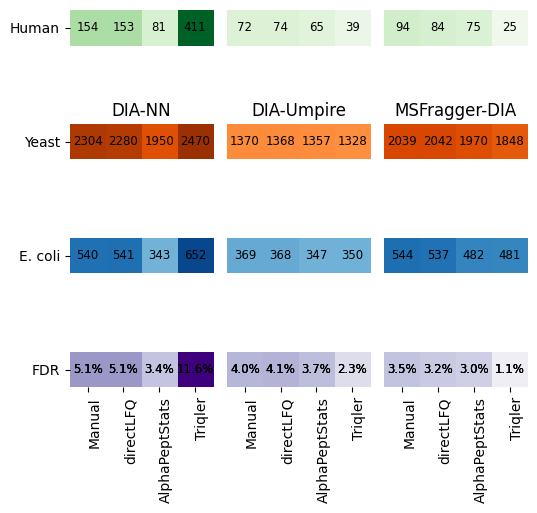

In [20]:
colormap_dict = {'Yeast':'Oranges', 'Ecoli':'Blues', 'Human':'Greens', 'fdr':'Purples'}
org_name = {'Yeast':'Yeast', 'Ecoli':'E. coli', 'Human':'Human'}
deps_lists = {}
for org in organisms :
    deps_lists[org] = [deps[search_engine][quant_tool][org] for search_engine in search_engines for quant_tool in quant_tools]
deps_lists['fdr'] = [round(deps[search_engine][quant_tool]['Human']/(deps[search_engine][quant_tool]['Human']
                                                               + deps[search_engine][quant_tool]['Ecoli']
                                                               + deps[search_engine][quant_tool]['Yeast'])*100,
                          1)
                     for search_engine in search_engines 
                     for quant_tool in quant_tools
                    ]

cm = 1/2.54
fig, axes = plt.subplots(4, 3, figsize=(15*cm, 15*cm), gridspec_kw={'wspace':0.1, 'hspace':0.01, 'height_ratios':[0.25, 0.25, 0.25, 0.25]} )
for axe, org in zip(axes, organisms) :
    for search_engine, ax in zip(search_engines, axe) :
        ylabels = [org_name[org]]
        xlabels = [quant_tools_full[quant_tool] for quant_tool in quant_tools]
        
        # org = 'Human'
        data = np.array([ [deps[search_engine][quant_tool][org] for quant_tool in quant_tools] ])
        
        im = ax.imshow(data/np.max(deps_lists[org]), cmap=mpl.colormaps[colormap_dict[org]], vmin=0, vmax=1.1)
        # Show all ticks and label them with the respective list entries
        # if org == 'Human' :
        #     ax.set_xticks(range(len(xlabels)), labels=xlabels, rotation=90, ha="right", rotation_mode="anchor")
        # else :
        ax.set_xticks([])

        if search_engine == 'diann' :
            ax.set_yticks(range(len(ylabels)), labels=ylabels)
        else :
            ax.set_yticks([])
            
        if org == 'Yeast' :
            ax.set_title(search_engines[search_engine])
        # 
        # Loop over data dimensions and create text annotations.
        for i in range(len(ylabels)):
            for j in range(len(xlabels)):
                # print(i, j)
                text = ax.text(j, i, data[i][j],
                               ha="center", va="center", color="black", size=8.5)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['bottom'].set_visible(False)
        ax.spines['left'].set_visible(False)
        # ax.set_title("Harvest of local farmers (in tons/year)")
        # fig.tight_layout()
        # plt.show()
i = 0
for ax in axes[-1] :
    ylabels = ['FDR']
    if i == 0 :
        ax.set_yticks(range(len(ylabels)), labels=ylabels)
    else :
        ax.set_yticks([])
    im = ax.imshow([deps_lists['fdr'][i*4:(i+1)*4]], cmap=mpl.colormaps[colormap_dict['fdr']], vmin=0, vmax=10)
    xlabels = [quant_tools_full[quant_tool] for quant_tool in quant_tools]  
    ax.set_xticks(range(len(xlabels)), labels=xlabels, rotation=90, ha="right", rotation_mode="anchor")
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)
    for _ in range(3) :
        for j in range(len(xlabels)):
            # print(i, j)
            text = ax.text(j, 0, str(deps_lists['fdr'][i*4+j])+'%',
                           ha="center", va="center", color="black", size=8.5)
    i += 1
    
print(deps_lists['fdr'])
savepath = './figures/LFQ_deps_heatmap_randomforest.svg'
plt.savefig(savepath, format=savepath.split('.')[-1])

# Heatmap of DEPs Extended LFQbench 

In [168]:
folder = './quantitation'
quant_tools = ['manual', 'directlfq', 'alphastats','triqler', 'triqler_opt']
search_engines = {'diann':'DIA-NN', 
                  'umpire':'DIA-Umpire', 
                  'msfragger':'MSFragger-DIA',
                  'diann tof':'DIA-NN timsTOF',
                  'diatracer':'diaTracer', 
                 }

search_engines_file_mask = {  'diann':'diann231_LFQbench_quant_{}{}.tsv', 
                              'umpire':'fragpipe24_LFQbench_umpire_quant_{}{}.tsv', 
                              'msfragger':'fragpipe24_LFQbench_msfragger_quant_{}{}.tsv',
                              'diann tof':'diann231_LFQbenchTOF_quant_{}{}.tsv', 
                              'diatracer':'fragpipe24_LFQbenchTOF_diatracer_quant_{}{}.tsv'

                           }

quant_tools_full = {'manual':'Manual', 'directlfq':'directLFQ', 'alphastats':'AlphaPeptStats', 'triqler':'Triqler', 'triqler_opt':'Triqler*'}
alphastats_imp = 'randomforest'
suffix = {'alphastats':'_'+alphastats_imp, 'directlfq':'_min', 'manual':'_min', 'triqler':'', 'triqler_opt':'_mins9'}
fdr_pass = defaultdict(lambda:'FDR_pass')
organisms = ['Human', 'Yeast', 'Ecoli']
# print(quant_tools, search_engines)
deps = {}
for search_engine in search_engines :
    deps[search_engine] = {}
    for quant_tool in quant_tools :
        print(search_engine, quant_tool)
        deps[search_engine][quant_tool] = {'Ecoli':0, 'Yeast':0, 'Human':0 }
        filepath = path.join(folder, search_engines_file_mask[search_engine].format(quant_tool, suffix[quant_tool]))
        if 'triqler' in quant_tool and not 'diann' in search_engine :
            filepath = filepath.replace('_quant', '_triqler')
        elif 'triqler' in quant_tool :
            filepath = filepath.replace('_quant', '')
        df = pd.read_csv(filepath, sep='\t')

        for org in organisms :
            deps[search_engine][quant_tool][org] = len(df[(df['Organism'] == org) & (df[fdr_pass[quant_tool]]) & (df['FC_pass'])])
            # fc_range = np.abs(df[(df['Organism'] == org) & (df[fdr_pass[quant_tool]]) & (df['FC_pass'])]['log2_FC'].max() - df[(df['Organism'] == org) & (df[fdr_pass[quant_tool]]) & (df['FC_pass'])]['log2_FC'].min())
        # print(fname, df['Search Engine'][0], df['Quantitation'][0], df['suffix'][0], *[deps[search_engine][quant_tool][org] for org in organisms], sep='\t')
        print(filepath, fdr_pass[org], *[deps[search_engine][quant_tool][org] for org in organisms], sum([deps[search_engine][quant_tool][org] for org in organisms]), sep='\t')
print(deps)

diann manual
./quantitation/diann231_LFQbench_quant_manual_min.tsv	FDR_pass	154	2304	540	2998
diann directlfq
./quantitation/diann231_LFQbench_quant_directlfq_min.tsv	FDR_pass	153	2280	541	2974
diann alphastats
./quantitation/diann231_LFQbench_quant_alphastats_randomforest.tsv	FDR_pass	81	1950	343	2374
diann triqler
./quantitation/diann231_LFQbench_triqler.tsv	FDR_pass	218	2192	528	2938
diann triqler_opt
./quantitation/diann231_LFQbench_triqler_opt_mins9.tsv	FDR_pass	278	2223	531	3032
umpire manual
./quantitation/fragpipe24_LFQbench_umpire_quant_manual_min.tsv	FDR_pass	72	1370	369	1811
umpire directlfq
./quantitation/fragpipe24_LFQbench_umpire_quant_directlfq_min.tsv	FDR_pass	74	1368	368	1810
umpire alphastats
./quantitation/fragpipe24_LFQbench_umpire_quant_alphastats_randomforest.tsv	FDR_pass	65	1357	347	1769
umpire triqler
./quantitation/fragpipe24_LFQbench_umpire_triqler_triqler.tsv	FDR_pass	41	1328	349	1718
umpire triqler_opt
./quantitation/fragpipe24_LFQbench_umpire_triqler_triqle

[5.1, 5.1, 3.4, 7.4, 9.2, 4.0, 4.1, 3.7, 2.4, 3.2, 3.5, 3.2, 3.0, 1.4, 2.5, 4.1, 4.3, 2.2, 0.7, 12.6, 1.7, 1.8, 1.4, 0.2, 10.5]


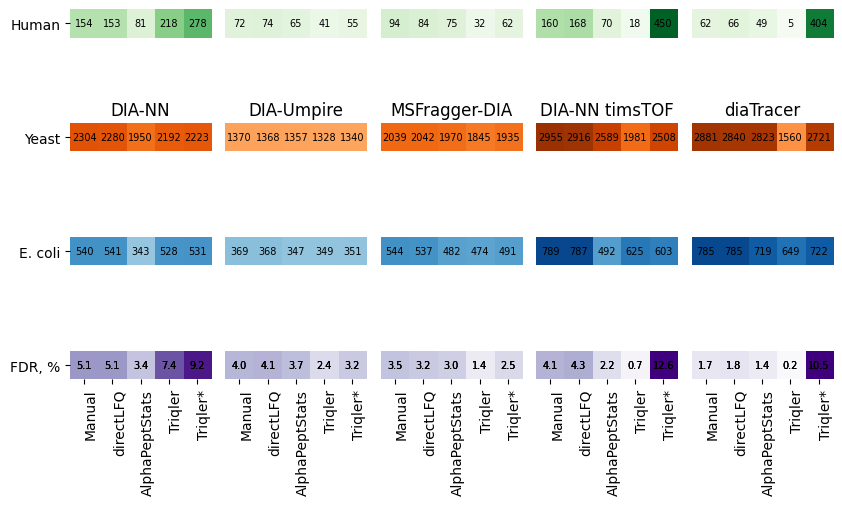

In [169]:
colormap_dict = {'Yeast':'Oranges', 'Ecoli':'Blues', 'Human':'Greens', 'fdr':'Purples'}
org_name = {'Yeast':'Yeast', 'Ecoli':'E. coli', 'Human':'Human'}
deps_lists = {}
for org in organisms :
    deps_lists[org] = [deps[search_engine][quant_tool][org] for search_engine in search_engines for quant_tool in quant_tools]
deps_lists['fdr'] = [round(deps[search_engine][quant_tool]['Human']/(deps[search_engine][quant_tool]['Human']
                                                               + deps[search_engine][quant_tool]['Ecoli']
                                                               + deps[search_engine][quant_tool]['Yeast'])*100,
                          1)
                     for search_engine in search_engines 
                     for quant_tool in quant_tools
                    ]

cm = 1/2.54
fig, axes = plt.subplots(4, 5, figsize=(25*cm, 15*cm), gridspec_kw={'wspace':0.1, 'hspace':0.01, 'height_ratios':[0.25, 0.25, 0.25, 0.25]} )
for axe, org in zip(axes, organisms) :
    for search_engine, ax in zip(search_engines, axe) :
        ylabels = [org_name[org]]
        xlabels = [quant_tools_full[quant_tool] for quant_tool in quant_tools]
        
        # org = 'Human'
        data = np.array([ [deps[search_engine][quant_tool][org] for quant_tool in quant_tools] ])
        
        im = ax.imshow(data/np.max(deps_lists[org]), cmap=mpl.colormaps[colormap_dict[org]], vmin=0, vmax=1.1)
        # Show all ticks and label them with the respective list entries
        # if org == 'Human' :
        #     ax.set_xticks(range(len(xlabels)), labels=xlabels, rotation=90, ha="right", rotation_mode="anchor")
        # else :
        ax.set_xticks([])

        if search_engine == 'diann' :
            ax.set_yticks(range(len(ylabels)), labels=ylabels)
        else :
            ax.set_yticks([])
            
        if org == 'Yeast' :
            ax.set_title(search_engines[search_engine])
        # 
        # Loop over data dimensions and create text annotations.
        for i in range(len(ylabels)):
            for j in range(len(xlabels)):
                # print(i, j)
                text = ax.text(j, i, data[i][j],
                               ha="center", va="center", color="black", size=7,)# rotation=10)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['bottom'].set_visible(False)
        ax.spines['left'].set_visible(False)
        # ax.set_title("Harvest of local farmers (in tons/year)")
        # fig.tight_layout()
        # plt.show()
i = 0
for ax in axes[-1] :
    ylabels = ['FDR, %']
    if i == 0 :
        ax.set_yticks(range(len(ylabels)), labels=ylabels)
    else :
        ax.set_yticks([])
    im = ax.imshow([deps_lists['fdr'][i*5:(i+1)*5]], cmap=mpl.colormaps[colormap_dict['fdr']], vmin=0, vmax=10)
    xlabels = [quant_tools_full[quant_tool] for quant_tool in quant_tools]  
    ax.set_xticks(range(len(xlabels)), labels=xlabels, rotation=90, ha="right", rotation_mode="anchor")
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)
    for _ in range(3) :
        for j in range(len(xlabels)):
            # print(i, j)
            text = ax.text(j, 0, str(deps_lists['fdr'][i*5+j]),#+'%',
                           ha="center", va="center", color="black", size=7,) #rotation=10)
    i += 1
    
print(deps_lists['fdr'])
savepath = './figures/LFQ_deps_heatmap_extended.svg'
plt.savefig(savepath, format=savepath.split('.')[-1], bbox_inches='tight')

# LFQbench volcano plot 3x4 Fig S3

manual FDR_pass 0.0211385262939028 1.6749252935061485
manual FDR_pass 0.0232180095487261 1.6341750145310137
manual FDR_pass 0.026105417614044 1.5832693548944003
directlfq FDR_pass 0.019373668605624 1.7127881333170512
directlfq FDR_pass 0.01852378877019 1.732270179981315
directlfq FDR_pass 0.019128944998061 1.7183089815751669
alphastats FDR_pass 0.015618915137325 1.8063491347503717
alphastats FDR_pass 0.0228484097730246 1.6411440210135317
alphastats FDR_pass 0.0252557238508905 1.5976401797177593
triqler FDR_pass 0.04992 1.3017254233256323
triqler FDR_pass 0.04965 1.3040807471686
triqler FDR_pass 0.04987 1.302160631781637


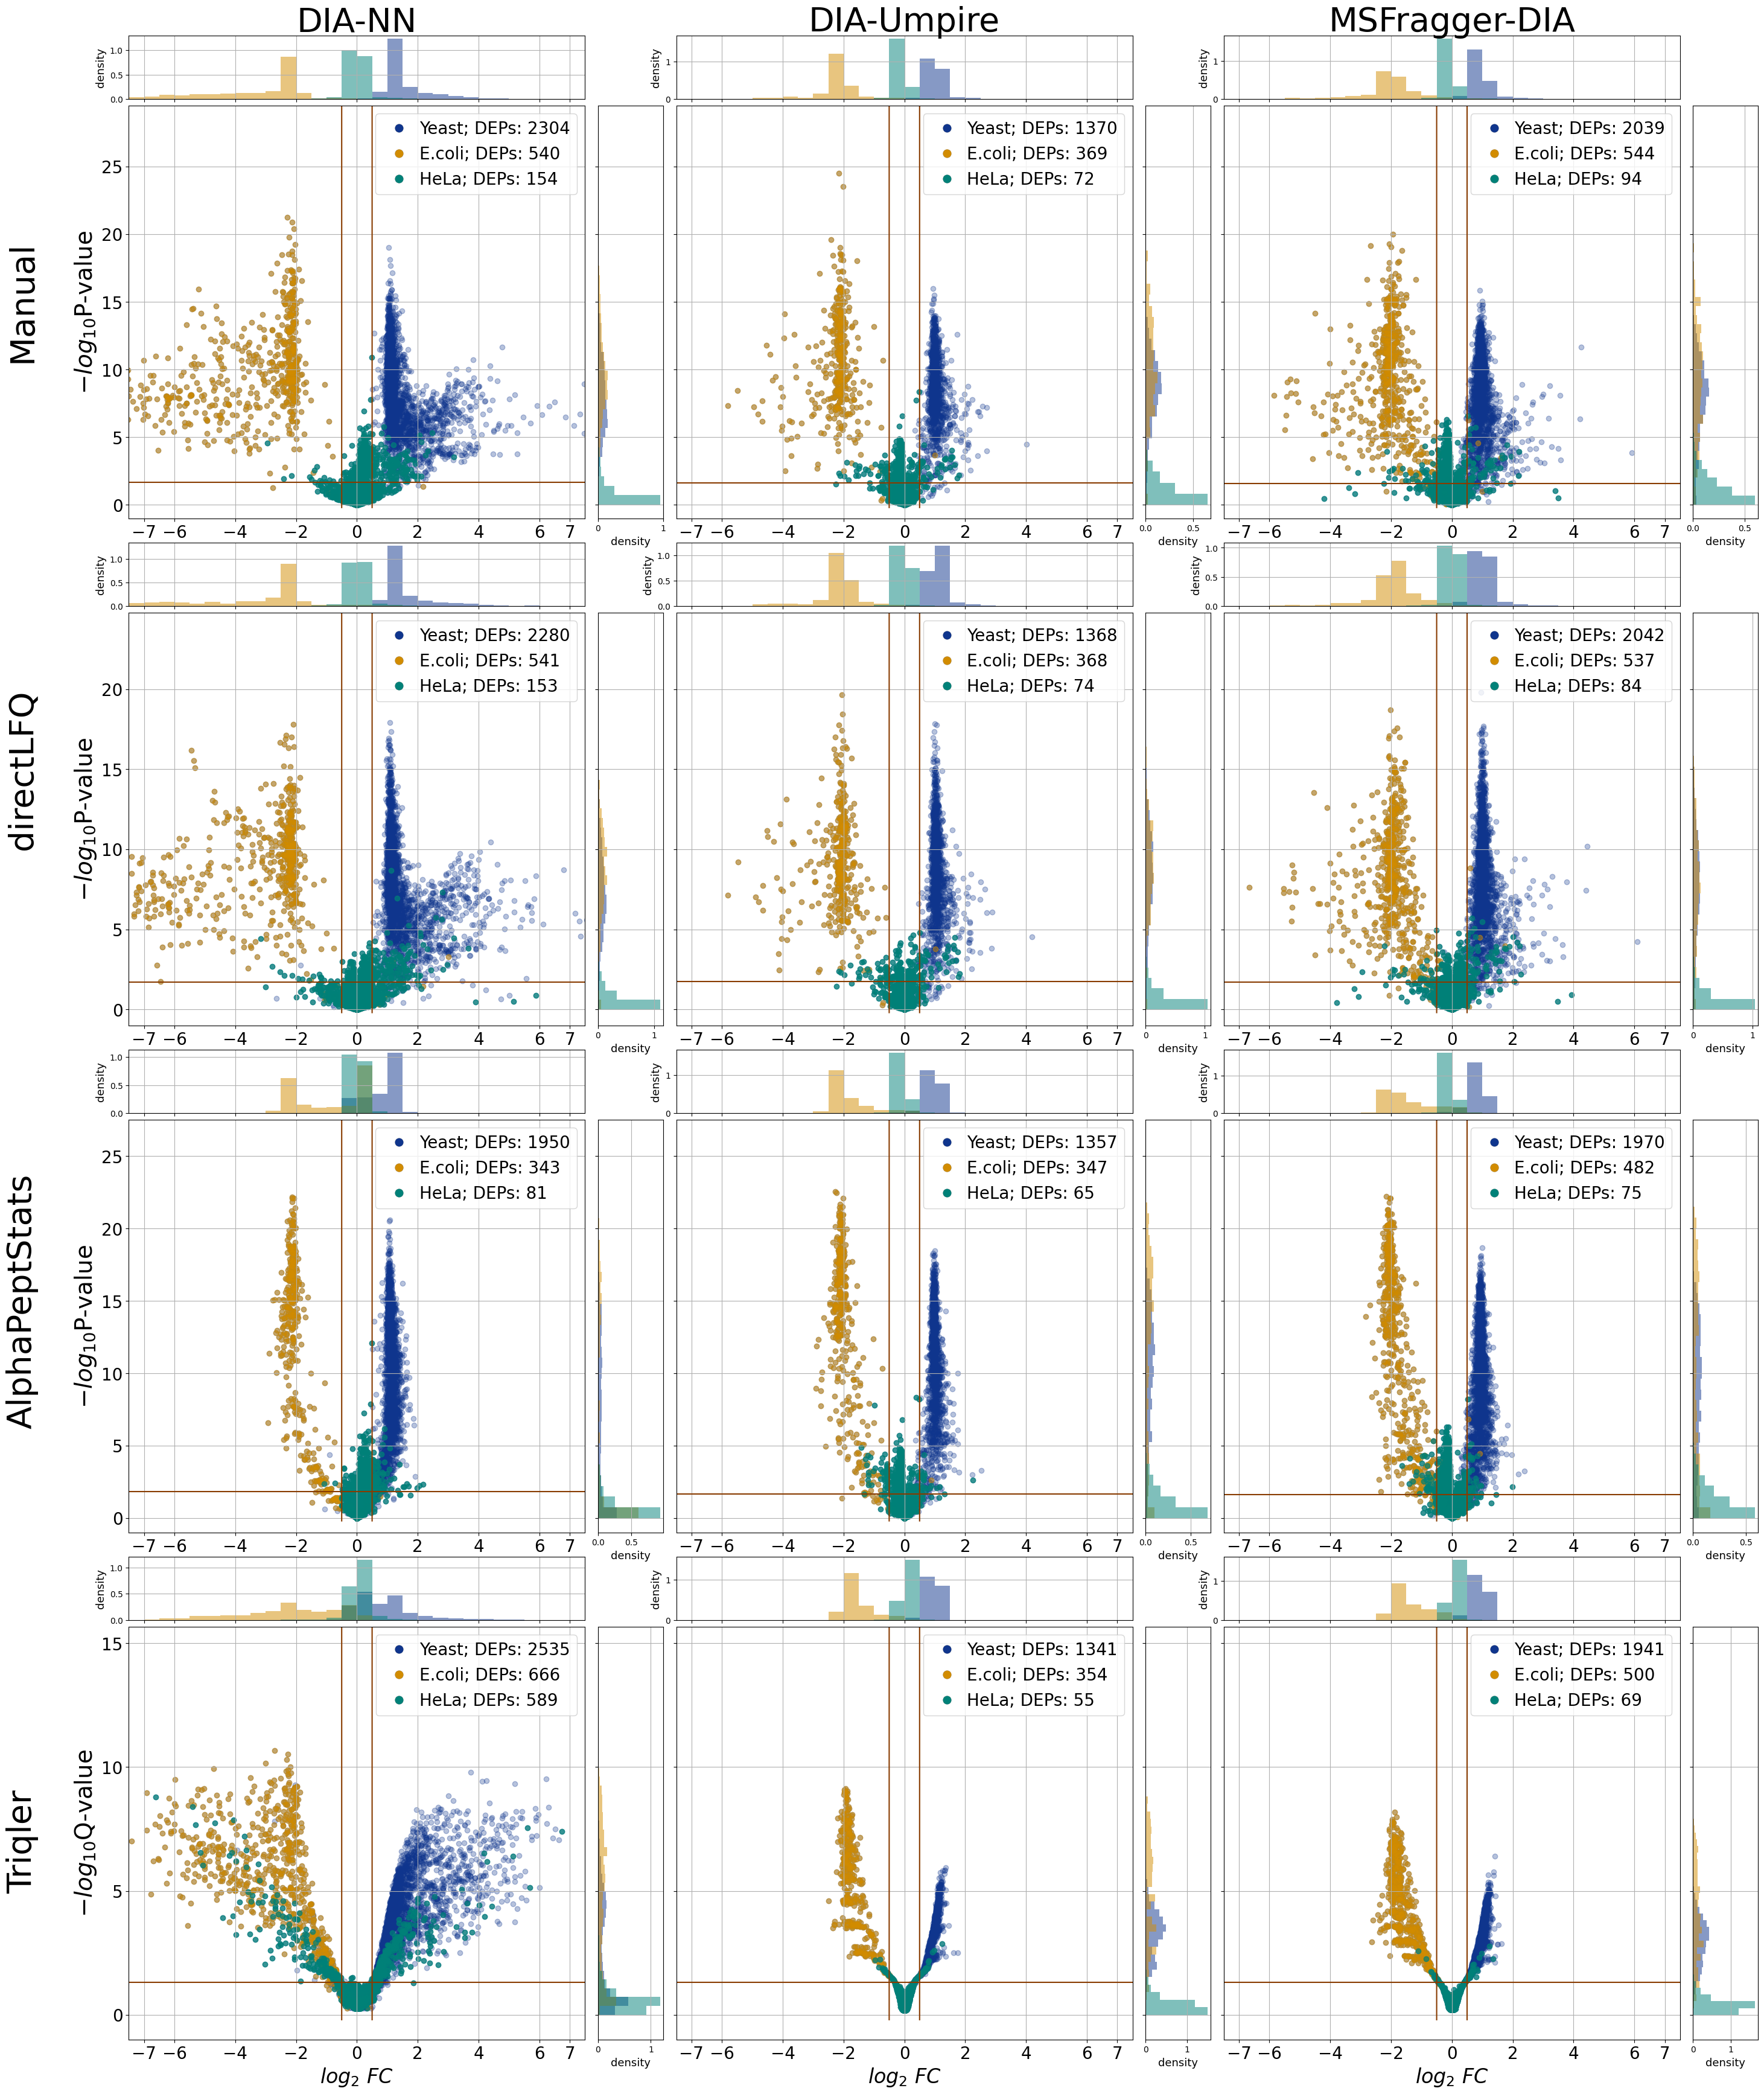

In [171]:
folder = './quantitation'
quant_tools = ['manual', 'directlfq', 'alphastats','triqler']

# quant_tools = ['manual', 'directLFQ', 'AlphaPeptStats','Triqler']
search_engines = {'diann':'DIA-NN', 
                  'umpire':'DIA-Umpire', 
                  'msfragger':'MSFragger-DIA'}

search_engines_file_mask = {  'diann':'diann231_LFQbench_quant_{}{}.tsv', 
                              'umpire':'fragpipe24_LFQbench_umpire_quant_{}{}.tsv', 
                              'msfragger':'fragpipe24_LFQbench_msfragger_quant_{}{}.tsv'}

quant_tools_full = {'manual':'Manual', 'directlfq':'directLFQ', 'alphastats':'AlphaPeptStats', 'triqler':'Triqler'}
alphastats_imp = 'randomforest'
imputation = {'alphastats':'_'+alphastats_imp, 'directlfq':'_min', 'manual':'_min', 'triqler':'_opt'}

fdr_col = {'manual':'pval', 'directlfq':'pval', 'alphastats':'pval','triqler':'q_value'}
fdr_pass = defaultdict(lambda:'FDR_pass')
fc_col = {'manual':'log2_FC', 'directlfq':'log2_FC', 'alphastats':'log2fc','triqler':'log2_FC'}
fc_pass = 'FC_pass'

colors = ['#008178', '#D28C00', '#0F358D', '#883B00', '#6482C6']
csfont = {'fontname':'sans-serif'}
base_fontsize = 20
cm = 1/2.54

fig = plt.figure(figsize=(30, 40))

h=0.2
space=0.01
zero_lvl = 0.9

xlim = [-7.5, 7.5]
xticks = [-7, -6, -4, -2, 0, 2, 4, 6, 7]
border_fc = 0.5


axes = []
for j in range(4) :
    bbot, ttop = zero_lvl-(j)*(space+h)-h, zero_lvl-(j)*(space+h)
    # print(bbot, ttop)
    axe1, axe2 = [], []
    gs1 = GridSpec(7, 21, bottom=bbot, top=ttop, left=0.05, right=0.95, wspace=0.2, hspace=0.1)
    mult = 7
    for i in range(3) :
        ax1 = fig.add_subplot(gs1[0, i*mult:(i+1)*mult-1])
        ax2 = fig.add_subplot(gs1[0, (i+1)*mult-1])
        ax3 = fig.add_subplot(gs1[1:, i*mult:(i+1)*mult-1])
        ax4 = fig.add_subplot(gs1[1:, (i+1)*mult-1])
        axe1.append(ax1)
        axe1.append(ax2)
        axe2.append(ax3)
        axe2.append(ax4)
    axes.append(axe1)
    axes.append(axe2)

mx_x = []
ll = 2

for j, quant in zip([0, 2, 4, 6], quant_tools) :
    up = []
    down = []
    mx_y = []
    reg_human = []
    reg_ecoli = []
    reg_yeast = []
    
    for i, engine in zip([0, 2, 4, ], search_engines) :
        filepath = path.join(folder, search_engines_file_mask[engine].format(quant, imputation[quant]))
        if quant == 'triqler' and not 'diann' in engine :
            filepath = filepath.replace('_quant', '_triqler')
        elif quant == 'triqler' :
            filepath = filepath.replace('_quant', '')
        table = pd.read_csv(filepath, sep = '\t')
        fdr_col_name = fdr_col[quant]
        # table['log2_FC'] = np.log2(table['s1']/table['s2'])
        # table['FC'] = table['s1']/table['s2']
        if 'Protein.Group' in table.columns :
            prot_col = 'Protein.Group'
        else :
            prot_col = 'protein'
        # table['Human'] = table[prot_col].apply(lambda x: True if (x.find('HUMAN') >= 0 and x.find('ECOLI') < 0 and x.find('YEAST') < 0) else False)
        # table['Ecoli'] = table[prot_col].apply(lambda x: True if (x.find('HUMAN') < 0 and x.find('ECOLI') >= 0 and x.find('YEAST') < 0) else False)
        # table['Yeast'] = table[prot_col].apply(lambda x: True if (x.find('HUMAN') < 0 and x.find('ECOLI') < 0 and x.find('YEAST') >= 0) else False)
    
        table.sort_values(fdr_col_name, ascending=True, inplace=True)
    
        x = np.array(table[fc_col[quant]])
        y = np.array(-np.log10(table[fdr_col_name]))
        mx_y.append(max(y))
        mx_x.append(max(abs(x)))
        human_mask = np.array(table['Human'] )
        ecoli_mask = np.array(table['Ecoli'] )
        yeast_mask = np.array(table['Yeast'] )
    
        num_proteins = len(table)
        xlim_sum = np.abs(xlim[1] - xlim[0])
        p_line_x = np.arange(xlim[0], xlim[1], xlim_sum/1000)
        if fdr_pass[quant] == 'Bonf_pass' :
            pval = 0.05/num_proteins
        else : 
            pval = max(table[table[fdr_pass[quant]]][fdr_col_name])
        p_y = -np.log10(pval)
        p_line_y = p_y*np.ones(len(p_line_x))
        axes[j+1][i].plot(p_line_x , p_line_y, color=colors[3])
        print(quant, fdr_pass[quant], pval, p_y)
        
        area = np.array((x, y))
        log10_bonfferroni = -np.log10(0.05/num_proteins)
        bonfferroni = 0.05/num_proteins
    
        mask = []
        for log_fc, p in zip(x, y) :
            if abs(log_fc) >= border_fc and p >= log10_bonfferroni :
                mask.append(True)
            else :
                mask.append(False)
        mask = np.array( mask )
    
        # print(reg_human)
    #    fc_cond = abs(x)>= 1
    #    p_cond = p >= -np.log10(0.05)
    
        # np.ma.masked_where показывает только False маскируя True
        numbins = int(xlim_sum*2)
        xbbins = [xlim[0] + i*xlim_sum/numbins for i in range(numbins) ]
        ybbins = [0 + i*max(y)/numbins for i in range(numbins) ]
        # Yeast
        axes[j+1][i].scatter( np.ma.masked_where( human_mask & ecoli_mask, x), np.ma.masked_where(  human_mask & ecoli_mask , y),
                    color = colors[2], alpha = 0.3, label= 'Yeast')
    
        axes[j][i].hist(x[np.logical_and(~human_mask, ~ecoli_mask)], color = colors[2], alpha = 0.5, bins=xbbins, density=True)
        
        axes[j+1][i+1].hist(y[np.logical_and(~human_mask, ~ecoli_mask)], color = colors[2], orientation='horizontal', alpha = 0.5, bins=ybbins, density=True)
        # Это - E.coli
        axes[j+1][i].scatter( np.ma.masked_where( ~ecoli_mask , x), np.ma.masked_where( ~ecoli_mask , y),
                    color = colors[1], alpha = 0.5, label= 'E.coli')
        axes[j][i].hist(x[ecoli_mask], color = colors[1], alpha = 0.5, bins=xbbins, density=True)
        
        axes[j+1][i+1].hist(y[ecoli_mask], color = colors[1], orientation='horizontal', alpha = 0.5, bins=ybbins, density=True)
    
        # Это - Human
        axes[j+1][i].scatter( np.ma.masked_where( ~human_mask , x), np.ma.masked_where( ~human_mask , y),
                    color = colors[0], alpha = 0.7, label= 'Human')
        axes[j][i].hist(x[human_mask], color = colors[0], alpha = 0.5, bins=xbbins, density=True)
        
        axes[j+1][i+1].hist(y[human_mask], color = colors[0], orientation='horizontal', alpha = 0.5, bins=ybbins, density=True)
        
        reg_human.append(len(table[(table[fdr_pass[quant]] & table[fc_pass] & table['Human'])]))
        reg_ecoli.append(len(table[(table[fdr_pass[quant]] & table[fc_pass] & table['Ecoli'])]))
        reg_yeast.append(len(table[(table[fdr_pass[quant]] & table[fc_pass] & table['Yeast'])]))
        # print(engine, quant, reg_human[-1], reg_ecoli[-1], reg_yeast[-1])
        fig.delaxes(axes[j][i+1])

        xlim_sum = sum([abs(el) for el in xlim])
        axes[j+1][i].set_xlim(xlim)
        axes[j][i].set_xlim(xlim)
        axes[j+1][i].set_xticks(xticks)
        axes[j][i].set_xticks(xticks)
        axes[j+1][i].tick_params(axis='both', which='major', labelsize=base_fontsize)
        if i == 0 :
            if quant == 'triqler' :
                ax_stat_name = 'Q-value'
                axes[j+1][i].text(-11, 7, quant_tools_full[quant], size=base_fontsize*2, rotation=90, ha='center', va='center')
            else :
                ax_stat_name = 'P-value'
                axes[j+1][i].text(-11, 15, quant_tools_full[quant], size=base_fontsize*2, rotation=90, ha='center', va='center')
            axes[j+1][i].set_ylabel(r'$-log_{10}$' + ax_stat_name, size = base_fontsize*1.4, **csfont)
        else :
            axes[j+1][i].set_ylabel(r'', size = base_fontsize*0.6, **csfont)
        if j == 6 :
            axes[j+1][i].set_xlabel(r'$log_{2}\ FC$', size = base_fontsize*1.2, **csfont)
        elif j == 0 :
            axes[j+1][i].text(0, 35, search_engines[engine], size=base_fontsize*2, ha='center')
        else :
            axes[j+1][i].set_xlabel(r'', size = base_fontsize*0.6, **csfont)
        axes[j][i].set_ylabel('density', size = base_fontsize*0.65, **csfont)
        axes[j+1][i+1].set_xlabel('density', size = base_fontsize*0.65, rotation=0, **csfont)
        # axes[j][i].set_title(search_engines[engine]+' '+quant, size = 28, **csfont)
        
        legend_elements = [
                Line2D([0], [0], color = 'w', markerfacecolor = colors[2], marker = 'o', markersize = 5,
                          markeredgecolor = 'k',  markeredgewidth = .1, label = 'Yeast; DEPs: {}'.format(reg_yeast[-1])),
                Line2D([0], [0], color = 'w', markerfacecolor = colors[1], marker = 'o', markersize = 5,
                          markeredgecolor = 'k',  markeredgewidth = .1, label = 'E.coli; DEPs: {}'.format(reg_ecoli[-1])),
                Line2D([0], [0], color = 'w', markerfacecolor = colors[0], marker = 'o', markersize = 5,
                          markeredgecolor = 'k',  markeredgewidth = .1, label = 'HeLa; DEPs: {}'.format(reg_human[-1])),
                            ]
        axes[j+1][i].legend(handles = legend_elements, fontsize = base_fontsize, markerscale = 2., loc='upper right', handletextpad=0.2)  
        
    for i, hum, enum, ynum in zip([0, 2, 4, ], reg_human, reg_ecoli,reg_yeast ) :
        axes[j+1][i].set_yticks(np.arange(0, max(mx_y)+5, 5))
        axes[j+1][i+1].set_yticks(np.arange(0, max(mx_y)+5, 5))
        axes[j+1][i].set_ylim([-1, max(mx_y)+5])
        axes[j+1][i+1].set_ylim([-1, max(mx_y)+5])
        fc_line_y = np.arange(-0.2, max(mx_y)+5+0.2, 0.01)
        fc_line_x1 = border_fc*np.ones(len(fc_line_y),)
        fc_line_x2 = -border_fc*np.ones(len(fc_line_y),)
        axes[j+1][i].plot(fc_line_x1 , fc_line_y, color=colors[3])
        axes[j+1][i].plot(fc_line_x2 , fc_line_y, color=colors[3])
        text_y = max(mx_y)*0.7
        # axes[j+1][i].text( 4.05, text_y, 'Yeast: \nE.coli: \nHeLa: ', size = 20, style='italic')
        # axes[j+1][i].text( 5.75, text_y, '{}\n{}\n{}'.format(ynum, enum, hum), size = 20, color='red')
        axes[j+1][i+1].tick_params(axis="y", labelleft=False)
        axes[j][i+1].tick_params(axis="y", labelleft=False)
        axes[j][i].tick_params(axis="x", labelbottom=False)
        axes[j+1][i+1].grid()
        axes[j+1][i].grid()
        axes[j][i].grid()
        if i > 0 :
            axes[j+1][i].tick_params(axis="y", labelleft=False)

savepath = './figures/LFQ_volcano_3x4.svg'
plt.savefig(savepath, format=savepath.split('.')[-1], dpi=300, bbox_inches='tight')
fig.show()

# FC distribution AlphaPeptStats imputation on DIA-NN (Fig S5-6)

Counter({'AlphaPeptStats_randomforest': 9064, 'AlphaPeptStats_knn': 9064, 'AlphaPeptStats_mean': 9064, 'AlphaPeptStats_none': 8298})
5598
5549
5510
5598
AlphaPeptStats_randomforest
30112
1306
6551
22255


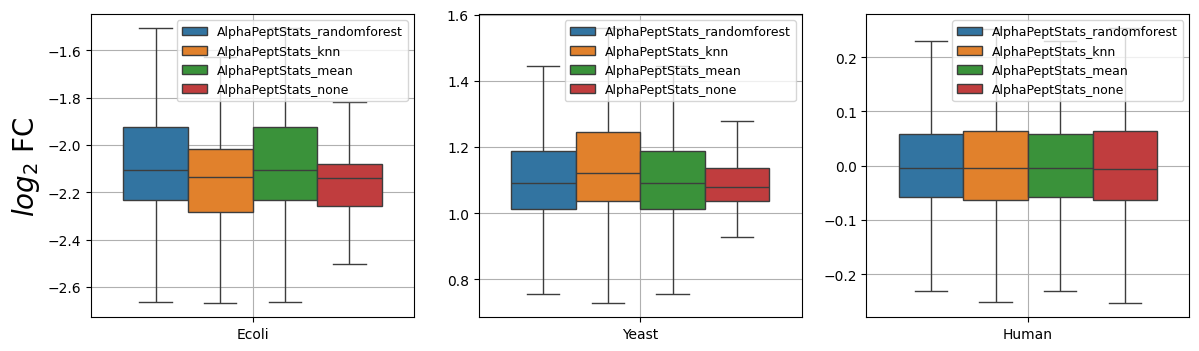

In [239]:
df1 = pd.read_csv('./quantitation/diann231_LFQbench_quant_alphastats_randomforest.tsv', sep='\t')
df1['log2_FC'] = df1['log2fc'].copy()
df2 = pd.read_csv('./quantitation/diann231_LFQbench_quant_alphastats_knn.tsv', sep='\t')
df2['log2_FC'] = df2['log2fc'].copy()
# df2 = pd.read_csv('./quantitation/diann231_LFQbench_quant_manual_min.tsv', sep='\t')
# df3 = pd.read_csv('./quantitation/diann231_LFQbench_quant_directlfq_min.tsv', sep='\t')
# df4 = pd.read_csv('./quantitation/diann231_LFQbench_triqler.tsv', sep='\t')
df5 = pd.read_csv('./quantitation/diann231_LFQbench_quant_alphastats_mean.tsv', sep='\t')
df5['log2_FC'] = df5['log2fc'].copy()
df6 = pd.read_csv('./quantitation/diann231_LFQbench_quant_alphastats_None.tsv', sep='\t')
df6['log2_FC'] = df6['log2fc'].copy()
# df4['Protein.Group'] = df4['Protein.Group'].apply(lambda x: x.split('|')[-1])
df = pd.concat([df1, df2, df5, df6], ignore_index=True)
df['quant_method'] = df['Quantitation'] + '_' + df['Imputation']
df.loc[:, 'quant_method'] = df['quant_method'].fillna('AlphaPeptStats_none')
c = Counter()
for v in df['quant_method'].values :
    c[v] += 1
print(c)
sort_dict = {'Manual':1, 'directLFQ':2, 'AlphaPeptStats':3, 'Triqler':4, }
df = df[df['Organism'].isin(['Ecoli','Yeast','Human',])].copy()
search_engines = {'diann':'DIA-NN', 'dia-umpire':'DIA-Umpire', 'msfragger':'MSFragger-DIA'}
letter = {'diann':'A', 'dia-umpire':'B', 'msfragger':'C'}
prot_sets = {}
for quant in set(df.quant_method.values) :
    prot_sets[quant] = {}
    for org in set(df.Organism.values) :
        prot_sets[quant][org] = set(df[(df['Organism'] == org) & (df['quant_method'] == quant)]['Protein.Group'].values)
    print(len(prot_sets[quant][org]))
common_set = set()
i = 0
for quant in set(df.quant_method.values) :
    tmp_quant_set = prot_sets[quant]['Yeast'] | prot_sets[quant]['Ecoli']
    if i == 0 :
        common_set = tmp_quant_set
        i += 1
    else :
        common_set = common_set & tmp_quant_set
        # print(quant, len(common_set))
df['common'] = df['Protein.Group'].isin(common_set)
print(quant, )
df['needed'] = [False for _ in range(len(df))]
dct = {'Human':True, 'Ecoli':False, 'Yeast':False, }
def get_needed(org, fc_pass, fdr_pass, common) :
    return org | (fc_pass & fdr_pass & common) 
df['needed'] = df[['Organism', 'FC_pass', 'FDR_pass', 'common']].apply(lambda x: get_needed(dct[x['Organism']], x['FC_pass'], x['FDR_pass'], x['common']), axis=1)
print(df['needed'].sum(), )

cm = 1/2.54
i = 0
fig, axes = plt.subplots(1, 3, figsize=(36*cm, 10*cm))
locs = ['upper right', 'upper right', 'upper right']
mx = 0
for org, ax, legend_loc in zip(['Ecoli','Yeast','Human',], axes, locs) :
    tdf = df[(df['Organism'] == org) & (df['needed'])].copy()
    if tdf['log2_FC'].max() > mx :
        mx = tdf['log2_FC'].max()
    print(len(tdf))
    sns.boxplot(x='Organism',
                y="log2_FC", 
                hue='quant_method',
                data=tdf, 
                ax=ax, 
                showfliers=False, 
                # color=colors[org],
               )
    if i < 1 :
        ax.set_ylabel(r'$log_{2}$ FC', size=20)
        i += 1
    else :
        ax.set_ylabel('')
    ax.set_xlabel('')
    ax.grid()
    # ax.legend(loc='lower right')
    ax.legend(loc=legend_loc, fontsize=9)
    # ax.text(-1.04, 1.08, letter[engine], size=30)
# fig.suptitle('DIA-NN Quantitation comparison')

fig.savefig('./figures/LFQ_fc_distr_alphastats_imp_diann.svg', format='svg', bbox_inches='tight')
fig.savefig('./figures/LFQ_fc_distr_alphastats_imp_diann.png', format='png', bbox_inches='tight')

In [236]:
folder = './quantitation'
quant_tools = ['alphastats_randomforest','alphastats_knn','alphastats_mean','alphastats_None']
search_engines = {'diann':'DIA-NN', 
                  # 'umpire':'DIA-Umpire', 
                  # 'msfragger':'MSFragger-DIA'
                 }

search_engines_file_mask = {  'diann':'diann231_LFQbench_quant_{}{}.tsv', 
                              'umpire':'fragpipe24_LFQbench_umpire_quant_{}{}.tsv', 
                              'msfragger':'fragpipe24_LFQbench_msfragger_quant_{}{}.tsv'}

quant_tools_full = {'alphastats_randomforest':'Random Forest', 
                    'alphastats_knn':'kNN', 
                    'alphastats_mean':'Mean', 
                    'alphastats_None':'None'
                   }
# alphastats_imp = 'randomforest'
imputation = defaultdict(lambda:'')
# imputation = {'alphastats':'_'+alphastats_imp, 'directlfq':'_min', 'manual':'_min', 'triqler':''}
fdr_pass = defaultdict(lambda:'FDR_pass')
organisms = ['Yeast', 'Ecoli', 'Human']
# print(quant_tools, search_engines)
deps = {}
for search_engine in search_engines :
    deps[search_engine] = {}
    for quant_tool in quant_tools :
        print(search_engine, quant_tool)
        deps[search_engine][quant_tool] = {'Ecoli':0, 'Yeast':0, 'Human':0 }
        filepath = path.join(folder, search_engines_file_mask[search_engine].format(quant_tool, imputation[quant_tool]))
        if quant_tool == 'triqler' and not 'diann' in search_engine :
            filepath = filepath.replace('_quant', '_triqler')
        elif quant_tool == 'triqler' :
            filepath = filepath.replace('_quant', '')
        df = pd.read_csv(filepath, sep='\t')

        for org in organisms :
            deps[search_engine][quant_tool][org] = len(df[(df['Organism'] == org) & (df[fdr_pass[quant_tool]]) & (df['FC_pass'])])
            # fc_range = np.abs(df[(df['Organism'] == org) & (df[fdr_pass[quant_tool]]) & (df['FC_pass'])]['log2_FC'].max() - df[(df['Organism'] == org) & (df[fdr_pass[quant_tool]]) & (df['FC_pass'])]['log2_FC'].min())
        # print(fname, df['Search Engine'][0], df['Quantitation'][0], df['Imputation'][0], *[deps[search_engine][quant_tool][org] for org in organisms], sep='\t')
        print(filepath, fdr_pass[org], *[deps[search_engine][quant_tool][org] for org in organisms], sum([deps[search_engine][quant_tool][org] for org in organisms]), sep='\t')
print(deps)

diann alphastats_randomforest
./quantitation/diann231_LFQbench_quant_alphastats_randomforest.tsv	FDR_pass	1950	343	81	2374
diann alphastats_knn
./quantitation/diann231_LFQbench_quant_alphastats_knn.tsv	FDR_pass	2238	406	177	2821
diann alphastats_mean
./quantitation/diann231_LFQbench_quant_alphastats_mean.tsv	FDR_pass	1914	342	78	2334
diann alphastats_None
./quantitation/diann231_LFQbench_quant_alphastats_None.tsv	FDR_pass	543	219	0	762
{'diann': {'alphastats_randomforest': {'Ecoli': 343, 'Yeast': 1950, 'Human': 81}, 'alphastats_knn': {'Ecoli': 406, 'Yeast': 2238, 'Human': 177}, 'alphastats_mean': {'Ecoli': 342, 'Yeast': 1914, 'Human': 78}, 'alphastats_None': {'Ecoli': 219, 'Yeast': 543, 'Human': 0}}}


0 0
0 1
0 2
0 3
[3.4, 6.3, 3.3, 0.0]


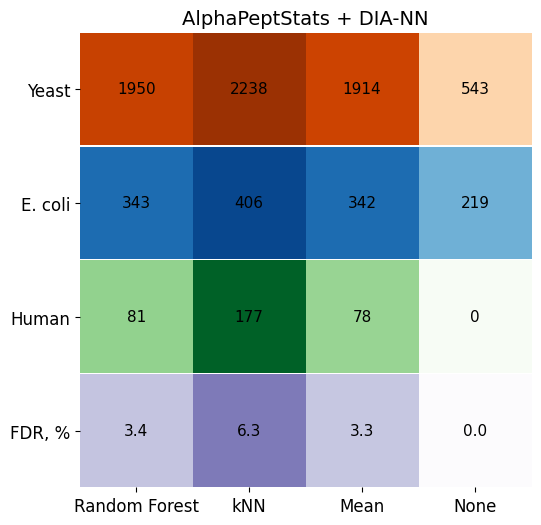

In [237]:
colormap_dict = {'Yeast':'Oranges', 'Ecoli':'Blues', 'Human':'Greens', 'fdr':'Purples'}
org_name = {'Yeast':'Yeast', 'Ecoli':'E. coli', 'Human':'Human'}
deps_lists = {}
for org in organisms :
    deps_lists[org] = [deps[search_engine][quant_tool][org] for search_engine in search_engines for quant_tool in quant_tools]
deps_lists['fdr'] = [round(deps[search_engine][quant_tool]['Human']/(deps[search_engine][quant_tool]['Human']
                                                               + deps[search_engine][quant_tool]['Ecoli']
                                                               + deps[search_engine][quant_tool]['Yeast'])*100,
                          1)
                     for search_engine in search_engines 
                     for quant_tool in quant_tools
                    ]

cm = 1/2.54
fig, axes = plt.subplots(4, 1, figsize=(15*cm, 15*cm), gridspec_kw={'wspace':0.1, 'hspace':0.01, 'height_ratios':[0.25, 0.25, 0.25, 0.25]} )
for ax, org in zip(axes, organisms) :
    se = 0
    for search_engine in search_engines :
    # for search_engine, ax in zip(search_engines, axe) :
        se += 1
        ylabels = [org_name[org]]
        xlabels = [quant_tools_full[quant_tool] for quant_tool in quant_tools]
        
        # org = 'Human'
        data = np.array([ [deps[search_engine][quant_tool][org] for quant_tool in quant_tools] ])
        
        im = ax.imshow(data/np.max(deps_lists[org]), cmap=mpl.colormaps[colormap_dict[org]], vmin=0, vmax=1.1)
        ax.set_xticks([])

        if se == 1 :
            ax.set_yticks(range(len(ylabels)), labels=ylabels, size=12)
        else :
            ax.set_yticks([])
            
        if org == 'Yeast' :
            ax.set_title('AlphaPeptStats + ' + search_engines[search_engine], size=14)
        # 
        for i in range(len(ylabels)):
            for j in range(len(xlabels)):
                # print(i, j)
                text = ax.text(j, i, data[i][j],
                               ha="center", va="center", color="black", size=11)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['bottom'].set_visible(False)
        ax.spines['left'].set_visible(False)
        # ax.set_title("Harvest of local farmers (in tons/year)")
        # fig.tight_layout()
        # plt.show()
i = 0
# for ax in axes[-1] :
ax = axes[-1]
ylabels = ['FDR, %']
if i == 0 :
    ax.set_yticks(range(len(ylabels)), labels=ylabels, size=12)
else :
    ax.set_yticks([])
im = ax.imshow([deps_lists['fdr'][i*5:(i+1)*5]], cmap=mpl.colormaps[colormap_dict['fdr']], vmin=0, vmax=10)
xlabels = [quant_tools_full[quant_tool] for quant_tool in quant_tools]  
ax.set_xticks(range(len(xlabels)), labels=xlabels, rotation=0, ha="center", rotation_mode="anchor", size=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)
for _ in range(len(search_engines)) :
    for j in range(len(xlabels)):
        print(i, j)
        text = ax.text(j, 0, str(deps_lists['fdr'][i*5+j]),
                       ha="center", va="center", color="black", size=11)
i += 1
    
print(deps_lists['fdr'])
savepath = './figures/LFQbench_diann_alphastats_imp_comp.svg'
plt.savefig(savepath, format=savepath.split('.')[-1], bbox_inches='tight')
plt.savefig(savepath.replace('svg', 'png'), format='png', bbox_inches='tight')

Counter({'Triqler_Triqler': 11521, 'AlphaPeptStats_randomforest': 11374, 'manual_min': 10290, 'directlfq_min': 8286})
6430
5361
6349
6872
AlphaPeptStats_randomforest
34638
1869
7757
25012


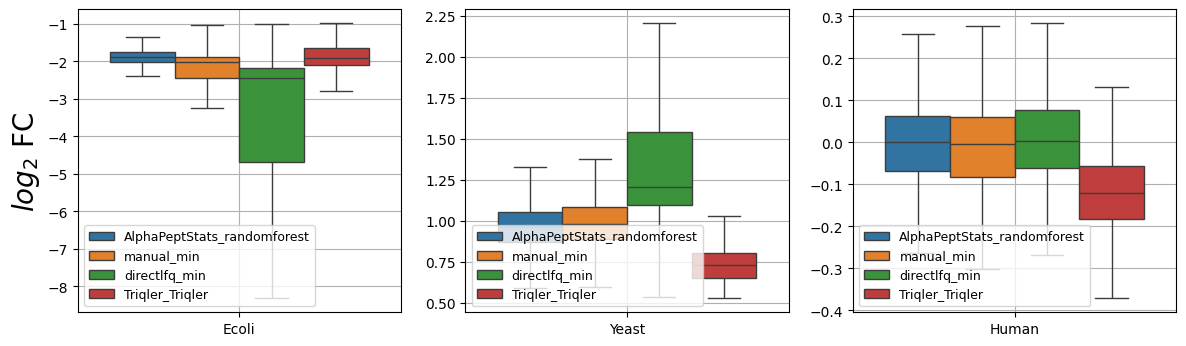

In [241]:
df1 = pd.read_csv('./quantitation/diann231_LFQbenchTOF_quant_alphastats_randomforest.tsv', sep='\t')
df1['log2_FC'] = df1['log2fc'].copy()
df2 = pd.read_csv('./quantitation/diann231_LFQbenchTOF_quant_manual_min.tsv', sep='\t')
df3 = pd.read_csv('./quantitation/diann231_LFQbench_quant_directlfq_min.tsv', sep='\t')
df4 = pd.read_csv('./quantitation/diann231_LFQbenchTOF_triqler_output_st_mins9.tsv', sep='\t')

# df4['Protein.Group'] = df4['Protein.Group'].apply(lambda x: x.split('|')[-1])
df = pd.concat([df1, df2, df3, df4], ignore_index=True)
df['quant_method'] = df['Quantitation'] + '_' + df['Imputation']
df.loc[:, 'quant_method'] = df['quant_method'].fillna('AlphaPeptStats_none')
c = Counter()
for v in df['quant_method'].values :
    c[v] += 1
print(c)
sort_dict = {'Manual':1, 'directLFQ':2, 'AlphaPeptStats':3, 'Triqler':4, }
df = df[df['Organism'].isin(['Ecoli','Yeast','Human',])].copy()
search_engines = {'diann':'DIA-NN', 'dia-umpire':'DIA-Umpire', 'msfragger':'MSFragger-DIA'}
letter = {'diann':'A', 'dia-umpire':'B', 'msfragger':'C'}
prot_sets = {}
for quant in set(df.quant_method.values) :
    prot_sets[quant] = {}
    for org in set(df.Organism.values) :
        prot_sets[quant][org] = set(df[(df['Organism'] == org) & (df['quant_method'] == quant)]['Protein.Group'].values)
    print(len(prot_sets[quant][org]))
common_set = set()
i = 0
for quant in set(df.quant_method.values) :
    tmp_quant_set = prot_sets[quant]['Yeast'] | prot_sets[quant]['Ecoli']
    if i == 0 :
        common_set = tmp_quant_set
        i += 1
    else :
        common_set = common_set & tmp_quant_set
        # print(quant, len(common_set))
df['common'] = df['Protein.Group'].isin(common_set)
print(quant, )
df['needed'] = [False for _ in range(len(df))]
dct = {'Human':True, 'Ecoli':False, 'Yeast':False, }
def get_needed(org, fc_pass, fdr_pass, common) :
    return org | (fc_pass & fdr_pass & common) 
df['needed'] = df[['Organism', 'FC_pass', 'FDR_pass', 'common']].apply(lambda x: get_needed(dct[x['Organism']], x['FC_pass'], x['FDR_pass'], x['common']), axis=1)
print(df['needed'].sum(), )

cm = 1/2.54
i = 0
fig, axes = plt.subplots(1, 3, figsize=(36*cm, 10*cm))
locs = ['lower left', 'lower left', 'lower left']
mx = 0
for org, ax, legend_loc in zip(['Ecoli','Yeast','Human',], axes, locs) :
    tdf = df[(df['Organism'] == org) & (df['needed'])].copy()
    if tdf['log2_FC'].max() > mx :
        mx = tdf['log2_FC'].max()
    print(len(tdf))
    sns.boxplot(x='Organism',
                y="log2_FC", 
                hue='quant_method',
                data=tdf, 
                ax=ax, 
                showfliers=False, 
                # color=colors[org],
               )
    if i < 1 :
        ax.set_ylabel(r'$log_{2}$ FC', size=20)
        i += 1
    else :
        ax.set_ylabel('')
    ax.set_xlabel('')
    ax.grid()
    # ax.legend(loc='lower right')
    ax.legend(loc=legend_loc, fontsize=9)
    # ax.text(-1.04, 1.08, letter[engine], size=30)
# fig.suptitle('DIA-NN Quantitation comparison')

# fig.savefig('./figures/LFQ_fc_distr_alphastats_imp_diann.svg', format='svg', bbox_inches='tight')
# fig.savefig('./figures/LFQ_fc_distr_alphastats_imp_diann.png', format='png', bbox_inches='tight')

Counter({'AlphaPeptStats_randomforest': 10390, 'directlfq_min': 10327, 'manual_min': 10322, 'Triqler_Triqler': 10010})
6475
6476
6306
6514
AlphaPeptStats_randomforest
38369
2808
9790
25771


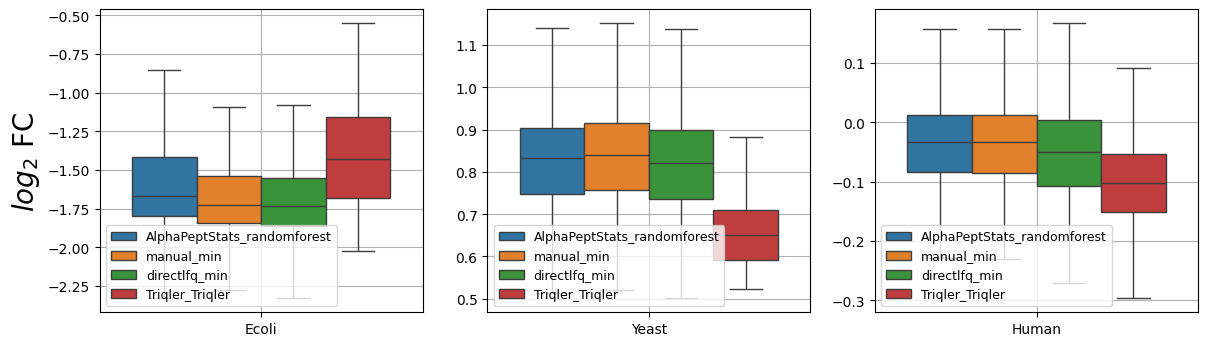

In [245]:
df1 = pd.read_csv('./quantitation/fragpipe24_LFQbenchTOF_diatracer_quant_alphastats_randomforest.tsv', sep='\t')
df1['log2_FC'] = df1['log2fc'].copy()
df2 = pd.read_csv('./quantitation/fragpipe24_LFQbenchTOF_diatracer_quant_manual_min.tsv', sep='\t')
df3 = pd.read_csv('./quantitation/fragpipe24_LFQbenchTOF_diatracer_quant_directlfq_min.tsv', sep='\t')
df4 = pd.read_csv('./quantitation/fragpipe24_LFQbenchTOF_diatracer_triqler_triqler_output_st_mins9.tsv', sep='\t')
# DIA_tools_manuscript/quantitation/fragpipe24_LFQbenchTOF_diatracer_quant_alphastats_mean.tsv
# df4['Protein.Group'] = df4['Protein.Group'].apply(lambda x: x.split('|')[-1])
df = pd.concat([df1, df2, df3, df4], ignore_index=True)
df['quant_method'] = df['Quantitation'] + '_' + df['Imputation']
df.loc[:, 'quant_method'] = df['quant_method'].fillna('AlphaPeptStats_none')
c = Counter()
for v in df['quant_method'].values :
    c[v] += 1
print(c)
sort_dict = {'Manual':1, 'directLFQ':2, 'AlphaPeptStats':3, 'Triqler':4, }
df = df[df['Organism'].isin(['Ecoli','Yeast','Human',])].copy()
search_engines = {'diann':'DIA-NN', 'dia-umpire':'DIA-Umpire', 'msfragger':'MSFragger-DIA'}
letter = {'diann':'A', 'dia-umpire':'B', 'msfragger':'C'}
prot_sets = {}
for quant in set(df.quant_method.values) :
    prot_sets[quant] = {}
    for org in set(df.Organism.values) :
        prot_sets[quant][org] = set(df[(df['Organism'] == org) & (df['quant_method'] == quant)]['Protein.Group'].values)
    print(len(prot_sets[quant][org]))
common_set = set()
i = 0
for quant in set(df.quant_method.values) :
    tmp_quant_set = prot_sets[quant]['Yeast'] | prot_sets[quant]['Ecoli']
    if i == 0 :
        common_set = tmp_quant_set
        i += 1
    else :
        common_set = common_set & tmp_quant_set
        # print(quant, len(common_set))
df['common'] = df['Protein.Group'].isin(common_set)
print(quant, )
df['needed'] = [False for _ in range(len(df))]
dct = {'Human':True, 'Ecoli':False, 'Yeast':False, }
def get_needed(org, fc_pass, fdr_pass, common) :
    return org | (fc_pass & fdr_pass & common) 
df['needed'] = df[['Organism', 'FC_pass', 'FDR_pass', 'common']].apply(lambda x: get_needed(dct[x['Organism']], x['FC_pass'], x['FDR_pass'], x['common']), axis=1)
print(df['needed'].sum(), )

cm = 1/2.54
i = 0
fig, axes = plt.subplots(1, 3, figsize=(36*cm, 10*cm))
locs = ['lower left', 'lower left', 'lower left']
mx = 0
for org, ax, legend_loc in zip(['Ecoli','Yeast','Human',], axes, locs) :
    tdf = df[(df['Organism'] == org) & (df['needed'])].copy()
    if tdf['log2_FC'].max() > mx :
        mx = tdf['log2_FC'].max()
    print(len(tdf))
    sns.boxplot(x='Organism',
                y="log2_FC", 
                hue='quant_method',
                data=tdf, 
                ax=ax, 
                showfliers=False, 
                # color=colors[org],
               )
    if i < 1 :
        ax.set_ylabel(r'$log_{2}$ FC', size=20)
        i += 1
    else :
        ax.set_ylabel('')
    ax.set_xlabel('')
    ax.grid()
    # ax.legend(loc='lower right')
    ax.legend(loc=legend_loc, fontsize=9)
    # ax.text(-1.04, 1.08, letter[engine], size=30)
# fig.suptitle('DIA-NN Quantitation comparison')

# fig.savefig('./figures/LFQ_fc_distr_alphastats_imp_diann.svg', format='svg', bbox_inches='tight')
# fig.savefig('./figures/LFQ_fc_distr_alphastats_imp_diann.png', format='png', bbox_inches='tight')

# FC distribution Manual quant

msfragger 1760
diann231 1696
1058
3960
13668


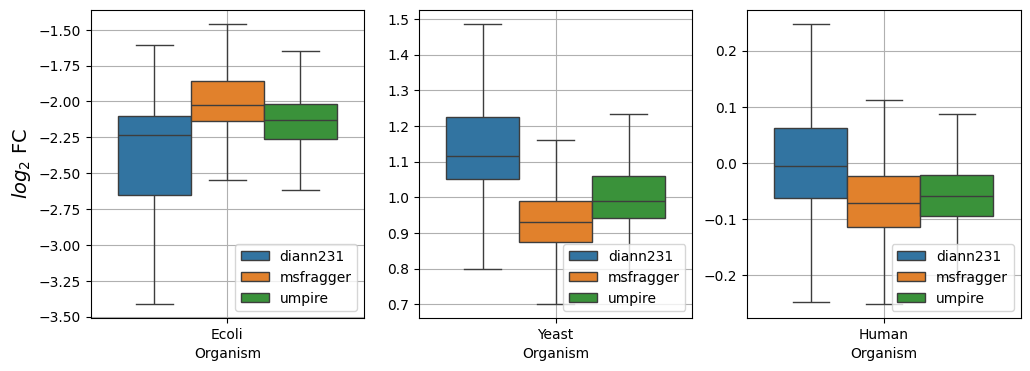

In [96]:
save_flag = True

df1 = pd.read_csv('./quantitation/diann231_LFQbench_quant_manual_min.tsv', sep='\t')
df2 = pd.read_csv('./quantitation/fragpipe24_LFQbench_msfragger_quant_manual_min.tsv', sep='\t')
df3 = pd.read_csv('./quantitation/fragpipe24_LFQbench_umpire_quant_manual_min.tsv', sep='\t')

df = pd.concat([ df1, df2, df3])
df = df[df['Organism'].isin(['Ecoli','Human','Yeast'])].copy()

prot_sets = {}
for quant in set(df['Search Engine'].values) :
    prot_sets[quant] = {}
    for org in set(df.Organism.values) :
        prot_sets[quant][org] = set(df[(df['Organism'] == org) & (df['Search Engine'] == quant)]['Protein.Group'].values)
    # print(len(prot_sets[imp][org]))
common_set = set()
i = 0
for quant in set(df['Search Engine'].values) :
    tmp_quant_set = prot_sets[quant]['Yeast'] | prot_sets[quant]['Ecoli']
    if i == 0 :
        common_set = tmp_quant_set
        i += 1
    else :
        common_set = common_set & tmp_quant_set
        print(quant, len(common_set))
df['common'] = df['Protein.Group'].isin(common_set)

df['needed'] = [False for _ in range(len(df))]
dct = {'Human':True, 'Ecoli':False, 'Yeast':False, }
def get_needed(org, fc_pass, fdr_pass, common) :
    return org | (fc_pass & fdr_pass & common) 
df['needed'] = df[['Organism', 'FC_pass', 'FDR_pass', 'common']].apply(lambda x: get_needed(dct[x['Organism']], x['FC_pass'], x['FDR_pass'], x['common']), axis=1)
# print(df['needed'].sum())

cm = 1/2.54
i = 0
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for org, ax in zip(['Ecoli','Yeast','Human'], axes) :
    tdf = df[(df['Organism'] == org) & (df['needed'])].copy()
    print(len(tdf))
    sns.boxplot(x='Organism',
                y="log2_FC", 
                hue='Search Engine',
                data=tdf, 
                ax=ax, 
                showfliers=False, 
                # color=colors[org],
               )
    if i < 1 :
        ax.set_ylabel(r'$log_{2}$ FC', size=14)
        i += 1        
    else :
        ax.set_ylabel('')
    if i != 1 :
        ax.set_xlabel()
    ax.grid()
    # ax.legend(loc='lower right')
    ax.legend(loc='lower right')
# fig.suptitle('Search engines comparison')
# ax.set_title(conc.replace('_', '.'))
# ax.hlines( fc,-1,4, linestyles = '--')#, color=colors[org])
# ax.set_xlabel('Организм', size=18 )
# ax.set_xlabel('', size=18 )
# ax.set_xticks([0], labels=[organism_fancy_names[org]], size=16)
# ax.tick_params('x', rotation=70)
# ax.set_xlim([-0.5, 1])
# ax.set_ylim(ylim)

if save_flag :
    fig.savefig('./figures/LFQ_FC_distr_3searchengine_manual.svg', format='svg', bbox_inches='tight')

# FC distribution directLFQ quant

msfragger 1761
diann231 1700
1057
3966
13787


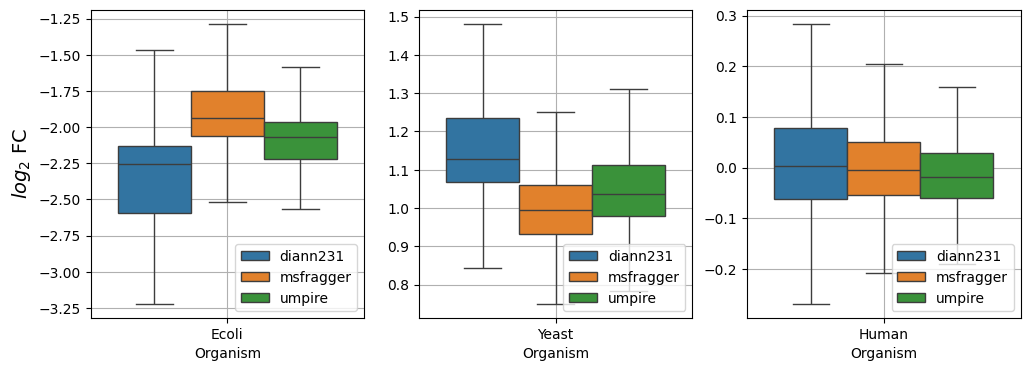

In [97]:
save_flag = True

df1 = pd.read_csv('./quantitation/diann231_LFQbench_quant_directlfq_min.tsv', sep='\t')
df2 = pd.read_csv('./quantitation/fragpipe24_LFQbench_msfragger_quant_directlfq_min.tsv', sep='\t')
df3 = pd.read_csv('./quantitation/fragpipe24_LFQbench_umpire_quant_directlfq_min.tsv', sep='\t')

df = pd.concat([ df1, df2, df3])
# df = pd.concat([df1, df2, df3, df4])

df = df[df['Organism'].isin(['Ecoli','Human','Yeast'])].copy()

prot_sets = {}
for quant in set(df['Search Engine'].values) :
    prot_sets[quant] = {}
    for org in set(df.Organism.values) :
        prot_sets[quant][org] = set(df[(df['Organism'] == org) & (df['Search Engine'] == quant)]['Protein.Group'].values)
    # print(len(prot_sets[imp][org]))
common_set = set()
i = 0
for quant in set(df['Search Engine'].values) :
    tmp_quant_set = prot_sets[quant]['Yeast'] | prot_sets[quant]['Ecoli']
    if i == 0 :
        common_set = tmp_quant_set
        i += 1
    else :
        common_set = common_set & tmp_quant_set
        print(quant, len(common_set))
df['common'] = df['Protein.Group'].isin(common_set)

df['needed'] = [False for _ in range(len(df))]
dct = {'Human':True, 'Ecoli':False, 'Yeast':False, }
def get_needed(org, fc_pass, fdr_pass, common) :
    return org | (fc_pass & fdr_pass & common) 
df['needed'] = df[['Organism', 'FC_pass', 'FDR_pass', 'common']].apply(lambda x: get_needed(dct[x['Organism']], x['FC_pass'], x['FDR_pass'], x['common']), axis=1)
# print(df['needed'].sum())

cm = 1/2.54
i = 0
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for org, ax in zip(['Ecoli','Yeast','Human'], axes) :
    tdf = df[(df['Organism'] == org) & (df['needed'])].copy()
    print(len(tdf))
    sns.boxplot(x='Organism',
                y="log2_FC", 
                hue='Search Engine',
                data=tdf, 
                ax=ax, 
                showfliers=False, 
                # color=colors[org],
               )
    if i < 1 :
        ax.set_ylabel(r'$log_{2}$ FC', size=14)
        i += 1        
    else :
        ax.set_ylabel('')
    if i != 1 :
        ax.set_xlabel()
    ax.grid()
    # ax.legend(loc='lower right')
    ax.legend(loc='lower right')
# fig.suptitle('Search engines comparison')
# ax.set_title(conc.replace('_', '.'))
# ax.hlines( fc,-1,4, linestyles = '--')#, color=colors[org])
# ax.set_xlabel('Организм', size=18 )
# ax.set_xlabel('', size=18 )
# ax.set_xticks([0], labels=[organism_fancy_names[org]], size=16)
# ax.tick_params('x', rotation=70)
# ax.set_xlim([-0.5, 1])
# ax.set_ylim(ylim)

if save_flag :
    fig.savefig('./figures/LFQ_FC_distr_3searchengine_directlfq.svg', format='svg', bbox_inches='tight')

# FC distribution AlphaPeptStats quant

msfragger 1772
diann231 1719
1003
3953
14061


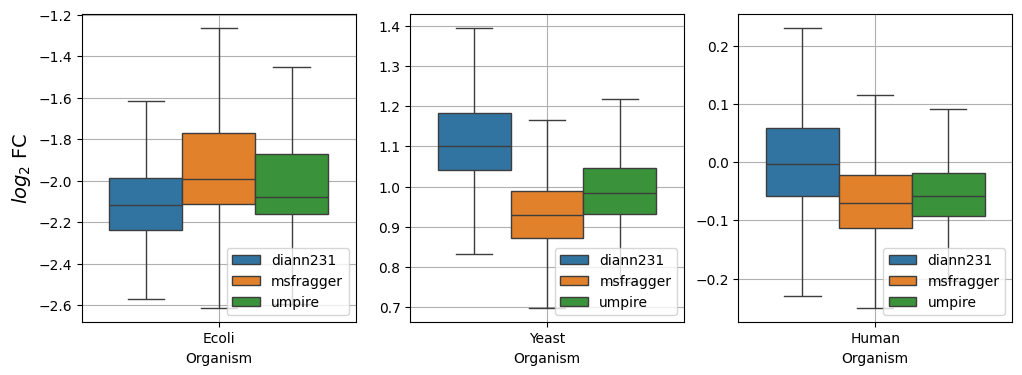

In [98]:
save_flag = True

df1 = pd.read_csv('./quantitation/diann231_LFQbench_quant_alphastats_randomforest.tsv', sep='\t')
df2 = pd.read_csv('./quantitation/fragpipe24_LFQbench_msfragger_quant_alphastats_randomforest.tsv', sep='\t')
df3 = pd.read_csv('./quantitation/fragpipe24_LFQbench_umpire_quant_alphastats_randomforest.tsv', sep='\t')

df = pd.concat([ df1, df2, df3])
df['log2_FC'] = df['log2fc']
df = df[df['Organism'].isin(['Ecoli','Human','Yeast'])].copy()

prot_sets = {}
for quant in set(df['Search Engine'].values) :
    prot_sets[quant] = {}
    for org in set(df.Organism.values) :
        prot_sets[quant][org] = set(df[(df['Organism'] == org) & (df['Search Engine'] == quant)]['Protein.Group'].values)
    # print(len(prot_sets[imp][org]))
common_set = set()
i = 0
for quant in set(df['Search Engine'].values) :
    tmp_quant_set = prot_sets[quant]['Yeast'] | prot_sets[quant]['Ecoli']
    if i == 0 :
        common_set = tmp_quant_set
        i += 1
    else :
        common_set = common_set & tmp_quant_set
        print(quant, len(common_set))
df['common'] = df['Protein.Group'].isin(common_set)

df['needed'] = [False for _ in range(len(df))]
dct = {'Human':True, 'Ecoli':False, 'Yeast':False, }
def get_needed(org, fc_pass, fdr_pass, common) :
    return org | (fc_pass & fdr_pass & common) 
df['needed'] = df[['Organism', 'FC_pass', 'FDR_pass', 'common']].apply(lambda x: get_needed(dct[x['Organism']], x['FC_pass'], x['FDR_pass'], x['common']), axis=1)
# print(df['needed'].sum())

cm = 1/2.54
i = 0
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for org, ax in zip(['Ecoli','Yeast','Human'], axes) :
    tdf = df[(df['Organism'] == org) & (df['needed'])].copy()
    print(len(tdf))
    sns.boxplot(x='Organism',
                y="log2_FC", 
                hue='Search Engine',
                data=tdf, 
                ax=ax, 
                showfliers=False, 
                # color=colors[org],
               )
    if i < 1 :
        ax.set_ylabel(r'$log_{2}$ FC', size=14)
        i += 1        
    else :
        ax.set_ylabel('')
    if i != 1 :
        ax.set_xlabel()
    ax.grid()
    # ax.legend(loc='lower right')
    ax.legend(loc='lower right')
# fig.suptitle('Search engines comparison')
# ax.set_title(conc.replace('_', '.'))
# ax.hlines( fc,-1,4, linestyles = '--')#, color=colors[org])
# ax.set_xlabel('Организм', size=18 )
# ax.set_xlabel('', size=18 )
# ax.set_xticks([0], labels=[organism_fancy_names[org]], size=16)
# ax.tick_params('x', rotation=70)
# ax.set_xlim([-0.5, 1])
# ax.set_ylim(ylim)

if save_flag :
    fig.savefig('./figures/LFQ_FC_distr_3searchengine_alphastats.svg', format='svg', bbox_inches='tight')

# FC distribution Triqler quant

DIA-Umpire 1700
diann231 1638
1032
3805
13281


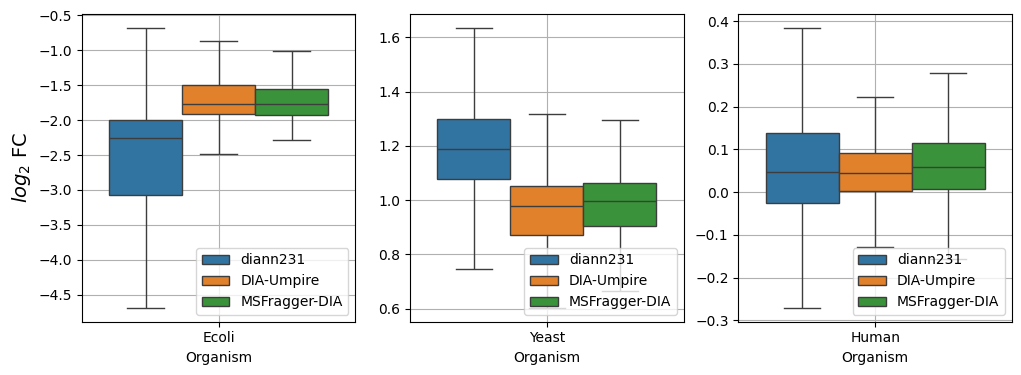

In [99]:
save_flag = True

df1 = pd.read_csv('./quantitation/diann231_LFQbench_triqler.tsv', sep='\t')
df2 = pd.read_csv('./quantitation/fragpipe24_LFQbench_umpire_triqler_triqler.tsv', sep='\t')
df2['Search Engine'] = ['DIA-Umpire' for _ in range(len(df2))]
df3 = pd.read_csv('./quantitation/fragpipe24_LFQbench_msfragger_triqler_triqler.tsv', sep='\t')
df3['Search Engine'] = ['MSFragger-DIA' for _ in range(len(df3))]

df = pd.concat([ df1, df2, df3])
# df['Protein.Group'] = df['protein']
# df = pd.concat([df1, df2, df3, df4])

df = df[df['Organism'].isin(['Ecoli','Human','Yeast'])].copy()

prot_sets = {}
for quant in set(df['Search Engine'].values) :
    prot_sets[quant] = {}
    for org in set(df.Organism.values) :
        prot_sets[quant][org] = set(df[(df['Organism'] == org) & (df['Search Engine'] == quant)]['Protein.Group'].values)
    # print(len(prot_sets[imp][org]))
common_set = set()
i = 0
for quant in set(df['Search Engine'].values) :
    tmp_quant_set = prot_sets[quant]['Yeast'] | prot_sets[quant]['Ecoli']
    if i == 0 :
        common_set = tmp_quant_set
        i += 1
    else :
        common_set = common_set & tmp_quant_set
        print(quant, len(common_set))
df['common'] = df['Protein.Group'].isin(common_set)

df['needed'] = [False for _ in range(len(df))]
dct = {'Human':True, 'Ecoli':False, 'Yeast':False, }
def get_needed(org, fc_pass, fdr_pass, common) :
    return org | (fc_pass & fdr_pass & common) 
df['needed'] = df[['Organism', 'FC_pass', 'FDR_pass', 'common']].apply(lambda x: get_needed(dct[x['Organism']], x['FC_pass'], x['FDR_pass'], x['common']), axis=1)
# print(df['needed'].sum())

cm = 1/2.54
i = 0
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for org, ax in zip(['Ecoli','Yeast','Human'], axes) :
    tdf = df[(df['Organism'] == org) & (df['needed'])].copy()
    print(len(tdf))
    sns.boxplot(x='Organism',
                y="log2_FC", 
                hue='Search Engine',
                data=tdf, 
                ax=ax, 
                showfliers=False, 
                # color=colors[org],
               )
    if i < 1 :
        ax.set_ylabel(r'$log_{2}$ FC', size=14)
        i += 1        
    else :
        ax.set_ylabel('')
    if i != 1 :
        ax.set_xlabel()
    ax.grid()
    # ax.legend(loc='lower right')
    ax.legend(loc='lower right')
# fig.suptitle('Search engines comparison')
# ax.set_title(conc.replace('_', '.'))
# ax.hlines( fc,-1,4, linestyles = '--')#, color=colors[org])
# ax.set_xlabel('Организм', size=18 )
# ax.set_xlabel('', size=18 )
# ax.set_xticks([0], labels=[organism_fancy_names[org]], size=16)
# ax.tick_params('x', rotation=70)
# ax.set_xlim([-0.5, 1])
# ax.set_ylim(ylim)

if save_flag :
    fig.savefig('./figures/LFQ_FC_distr_3searchengine_triqler.svg', format='svg', bbox_inches='tight')

# FC distribution DIA-NN quantitations Fig 2B

5598
5165
5243
5361
directlfq
1915
8485
21367


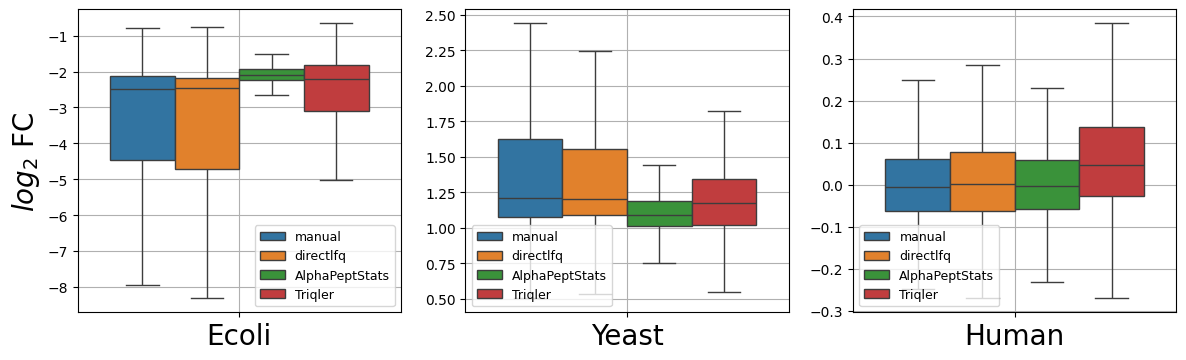

In [231]:
df1 = pd.read_csv('./quantitation/diann231_LFQbench_quant_alphastats_randomforest.tsv', sep='\t')
df1['log2_FC'] = df1['log2fc'].copy()
df1['FDR_pass'] = df1['FDR_pass']
df2 = pd.read_csv('./quantitation/diann231_LFQbench_quant_manual_min.tsv', sep='\t')
df2['FDR_pass'] = df2['FDR_pass']
df3 = pd.read_csv('./quantitation/diann231_LFQbench_quant_directlfq_min.tsv', sep='\t')
df3['FDR_pass'] = df3['FDR_pass']
df4 = pd.read_csv('./quantitation/diann231_LFQbench_triqler.tsv', sep='\t')
df4['FDR_pass'] = df4['FDR_pass']
# df4['Protein.Group'] = df4['Protein.Group'].apply(lambda x: x.split('|')[-1])
df = pd.concat([df2, df3, df1, df4], ignore_index=True)
sort_dict = {'Manual':1, 'directLFQ':2, 'AlphaPeptStats':3, 'Triqler':4, }
df = df[df['Organism'].isin(['Ecoli','Yeast','Human',])].copy()
search_engines = {'diann':'DIA-NN', 'dia-umpire':'DIA-Umpire', 'msfragger':'MSFragger-DIA'}
letter = {'diann':'A', 'dia-umpire':'B', 'msfragger':'C'}
prot_sets = {}
for quant in set(df.Quantitation.values) :
    prot_sets[quant] = {}
    for org in set(df.Organism.values) :
        prot_sets[quant][org] = set(df[(df['Organism'] == org) & (df['Quantitation'] == quant)]['Protein.Group'].values)
    print(len(prot_sets[quant][org]))
common_set = set()
i = 0
for quant in set(df.Quantitation.values) :
    tmp_quant_set = prot_sets[quant]['Yeast'] | prot_sets[quant]['Ecoli']
    if i == 0 :
        common_set = tmp_quant_set
        i += 1
    else :
        common_set = common_set & tmp_quant_set
        # print(quant, len(common_set))
df['common'] = df['Protein.Group'].isin(common_set)
print(quant, )
df['needed'] = [False for _ in range(len(df))]
dct = {'Human':True, 'Ecoli':False, 'Yeast':False, }
def get_needed(org, fc_pass, fdr_pass, common) :
    return org | (fc_pass & fdr_pass & common) 
df['needed'] = df[['Organism', 'FC_pass', 'FDR_pass', 'common']].apply(lambda x: get_needed(dct[x['Organism']], x['FC_pass'], x['FDR_pass'], x['common']), axis=1)
# print(df['needed'].sum())

cm = 1/2.54
i = 0
fig, axes = plt.subplots(1, 3, figsize=(36*cm, 10*cm))
locs = ['lower right', 'lower left', 'lower left']
mx = 0
for org, ax, legend_loc in zip(['Ecoli','Yeast','Human',], axes, locs) :
    tdf = df[(df['Organism'] == org) & (df['needed'])].copy()
    if tdf['log2_FC'].max() > mx :
        mx = tdf['log2_FC'].max()
    print(len(tdf))
    sns.boxplot(x='Organism',
                y="log2_FC", 
                hue='Quantitation',
                data=tdf, 
                ax=ax, 
                showfliers=False, 
                # color=colors[org],
               )
    ax.tick_params(axis='x', labelsize=20)  
    if i < 1 :
        ax.set_ylabel(r'$log_{2}$ FC', size=20)
        i += 1
    else :
        ax.set_ylabel('')
    ax.set_xlabel('')
    ax.grid()
    # ax.legend(loc='lower right')
    ax.legend(loc=legend_loc, fontsize=9)
    # ax.text(-1.04, 1.08, letter[engine], size=30)
# fig.suptitle('DIA-NN Quantitation comparison')

fig.savefig('./figures/LFQ_fc_distr_diann.svg', format='svg', bbox_inches='tight')

# FC distribution Umpire quantitations

3571
3457
3552
3553
directlfq
1377
5235
14133


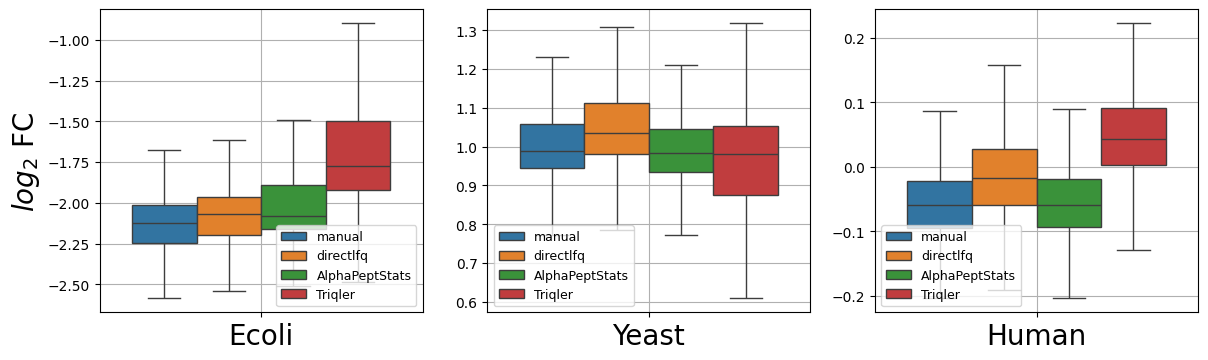

In [287]:
df1 = pd.read_csv('./quantitation/fragpipe24_LFQbench_umpire_quant_alphastats_randomforest.tsv', sep='\t')
df1['log2_FC'] = df1['log2fc'].copy()
df1['FDR_pass'] = df1['FDR_pass']
df2 = pd.read_csv('./quantitation/fragpipe24_LFQbench_umpire_quant_manual_min.tsv', sep='\t')
df2['FDR_pass'] = df2['FDR_pass']
df3 = pd.read_csv('./quantitation/fragpipe24_LFQbench_umpire_quant_directlfq_min.tsv', sep='\t')
df3['FDR_pass'] = df3['FDR_pass']
df4 = pd.read_csv('./quantitation/fragpipe24_LFQbench_umpire_triqler_triqler.tsv', sep='\t')
df4['FDR_pass'] = df4['FDR_pass']
# df4['Protein.Group'] = df4['Protein.Group'].apply(lambda x: x.split('|')[-1])
df = pd.concat([df2, df3, df1, df4], ignore_index=True)
sort_dict = {'Manual':1, 'directLFQ':2, 'AlphaPeptStats':3, 'Triqler':4, }
df = df[df['Organism'].isin(['Ecoli','Human','Yeast'])].copy()
search_engines = {'diann':'DIA-NN', 'dia-umpire':'DIA-Umpire', 'msfragger':'MSFragger-DIA'}
letter = {'diann':'A', 'dia-umpire':'B', 'msfragger':'C'}
prot_sets = {}
for quant in set(df.Quantitation.values) :
    prot_sets[quant] = {}
    for org in set(df.Organism.values) :
        prot_sets[quant][org] = set(df[(df['Organism'] == org) & (df['Quantitation'] == quant)]['Protein.Group'].values)
    print(len(prot_sets[quant][org]))
common_set = set()
i = 0
for quant in set(df.Quantitation.values) :
    tmp_quant_set = prot_sets[quant]['Yeast'] | prot_sets[quant]['Ecoli']
    if i == 0 :
        common_set = tmp_quant_set
        i += 1
    else :
        common_set = common_set & tmp_quant_set
        # print(quant, len(common_set))
df['common'] = df['Protein.Group'].isin(common_set)
print(quant, )
df['needed'] = [False for _ in range(len(df))]
dct = {'Human':True, 'Ecoli':False, 'Yeast':False, }
def get_needed(org, fc_pass, fdr_pass, common) :
    return org | (fc_pass & fdr_pass & common) 
df['needed'] = df[['Organism', 'FC_pass', 'FDR_pass', 'common']].apply(lambda x: get_needed(dct[x['Organism']], x['FC_pass'], x['FDR_pass'], x['common']), axis=1)
# print(df['needed'].sum())

cm = 1/2.54
i = 0
fig, axes = plt.subplots(1, 3, figsize=(36*cm, 10*cm))
locs = ['lower right', 'lower left', 'lower left']
mx = 0
for org, ax, legend_loc in zip(['Ecoli','Yeast','Human'], axes, locs) :
    tdf = df[(df['Organism'] == org) & (df['needed'])].copy()
    if tdf['log2_FC'].max() > mx :
        mx = tdf['log2_FC'].max()
    print(len(tdf))
    sns.boxplot(x='Organism',
                y="log2_FC", 
                hue='Quantitation',
                data=tdf, 
                ax=ax, 
                showfliers=False, 
                # color=colors[org],
               )
    ax.tick_params(axis='x', labelsize=20)  
    if i < 1 :
        ax.set_ylabel(r'$log_{2}$ FC', size=20)
        i += 1
    else :
        ax.set_ylabel('')
    ax.set_xlabel('')
    ax.grid()
    # ax.legend(loc='lower right')
    ax.legend(loc=legend_loc, fontsize=9)
    # ax.text(-1.04, 1.08, letter[engine], size=30)
# fig.suptitle('DIA-NN Quantitation comparison')

fig.savefig('./figures/LFQ_fc_distr_umpire.svg')

# FC distribution MSFragger quantitations

4892
4659
4873
4873
directlfq
1944
7547
19297


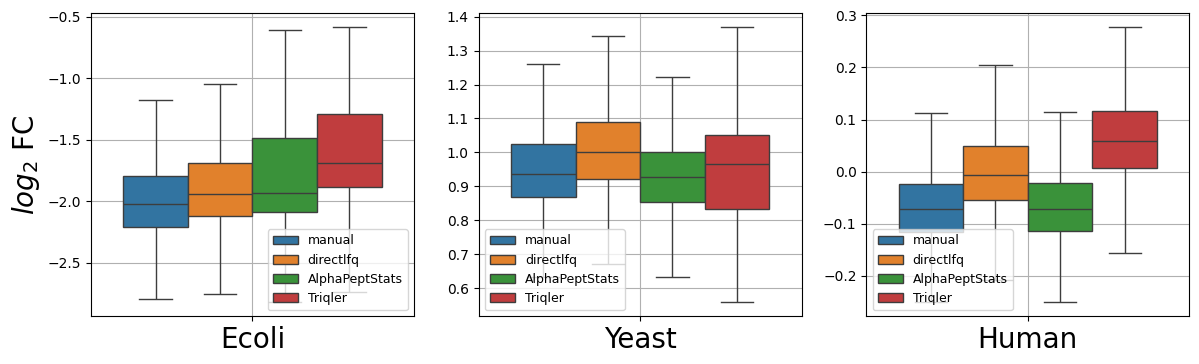

In [288]:
df1 = pd.read_csv('./quantitation/fragpipe24_LFQbench_msfragger_quant_alphastats_randomforest.tsv', sep='\t')
df1['log2_FC'] = df1['log2fc'].copy()
df1['FDR_pass'] = df1['FDR_pass']
df2 = pd.read_csv('./quantitation/fragpipe24_LFQbench_msfragger_quant_manual_min.tsv', sep='\t')
df2['FDR_pass'] = df2['FDR_pass']
df3 = pd.read_csv('./quantitation/fragpipe24_LFQbench_msfragger_quant_directlfq_min.tsv', sep='\t')
df3['Protein.Group'] = df3['protein'].copy()
df3['FDR_pass'] = df3['FDR_pass']
df4 = pd.read_csv('./quantitation/fragpipe24_LFQbench_msfragger_triqler_triqler.tsv', sep='\t')
df4['FDR_pass'] = df4['FDR_pass']
# df4['Protein.Group'] = df4['protein'].copy()

# df4['Protein.Group'] = df4['Protein.Group'].apply(lambda x: x.split('|')[-1])
df = pd.concat([df2, df3, df1, df4], ignore_index=True)
sort_dict = {'Manual':1, 'directLFQ':2, 'AlphaPeptStats':3, 'Triqler':4, }
df = df[df['Organism'].isin(['Ecoli','Human','Yeast'])].copy()
search_engines = {'diann':'DIA-NN', 'dia-umpire':'DIA-Umpire', 'msfragger':'MSFragger-DIA'}
letter = {'diann':'A', 'dia-umpire':'B', 'msfragger':'C'}
prot_sets = {}
for quant in set(df.Quantitation.values) :
    prot_sets[quant] = {}
    for org in set(df.Organism.values) :
        prot_sets[quant][org] = set(df[(df['Organism'] == org) & (df['Quantitation'] == quant)]['Protein.Group'].values)
    print(len(prot_sets[quant][org]))
common_set = set()
i = 0
for quant in set(df.Quantitation.values) :
    tmp_quant_set = prot_sets[quant]['Yeast'] | prot_sets[quant]['Ecoli']
    if i == 0 :
        common_set = tmp_quant_set
        i += 1
    else :
        common_set = common_set & tmp_quant_set
        # print(quant, len(common_set))
df['common'] = df['Protein.Group'].isin(common_set)
print(quant, )
df['needed'] = [False for _ in range(len(df))]
dct = {'Human':True, 'Ecoli':False, 'Yeast':False, }
def get_needed(org, fc_pass, fdr_pass, common) :
    return org | (fc_pass & fdr_pass & common) 
df['needed'] = df[['Organism', 'FC_pass', 'FDR_pass', 'common']].apply(lambda x: get_needed(dct[x['Organism']], x['FC_pass'], x['FDR_pass'], x['common']), axis=1)
# print(df['needed'].sum())

cm = 1/2.54
i = 0
fig, axes = plt.subplots(1, 3, figsize=(36*cm, 10*cm))
locs = ['lower right', 'lower left', 'lower left']
mx = 0
for org, ax, legend_loc in zip(['Ecoli','Yeast','Human'], axes, locs) :
    tdf = df[(df['Organism'] == org) & (df['needed'])].copy()
    if tdf['log2_FC'].max() > mx :
        mx = tdf['log2_FC'].max()
    print(len(tdf))
    sns.boxplot(x='Organism',
                y="log2_FC", 
                hue='Quantitation',
                data=tdf, 
                ax=ax, 
                showfliers=False, 
                # color=colors[org],
               )
    ax.tick_params(axis='x', labelsize=20)  
    if i < 1 :
        ax.set_ylabel(r'$log_{2}$ FC', size=20)
        i += 1
    else :
        ax.set_ylabel('')
    ax.set_xlabel('')
    ax.grid()
    # ax.legend(loc='lower right')
    ax.legend(loc=legend_loc, fontsize=9)
    # ax.text(-1.04, 1.08, letter[engine], size=30)
# fig.suptitle('DIA-NN Quantitation comparison')

fig.savefig('./figures/LFQ_fc_distr_msfragger.svg')

# Numbers of identifications LFQbench

{'DIA-Umpire': {'Ecoli': 387, 'Human': 3576, 'Yeast': 1418}, 'DIA-Umpire\ndouble decoys': {'Ecoli': 373, 'Human': 3474, 'Other': 29, 'Yeast': 1374}, 'MSFragger-DIA': {'Ecoli': 594, 'Human': 4899, 'Yeast': 2194}, 'MSFragger-DIA\ndouble decoys': {'Ecoli': 552, 'Human': 4684, 'Other': 48, 'Yeast': 2034}, 'DIA-NN': {'Ecoli': 720, 'Human': 5557, 'Other': 94, 'Yeast': 2701}}


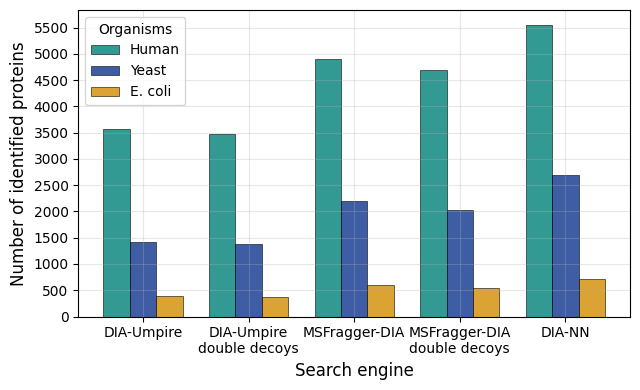

In [232]:
saveflag = True

files = [
'./search_results/fragpipe24_LFQbench_umpire/dia-quant-output/report.pg_matrix.tsv', 
'./search_results/fragpipe24_LFQbench_umpire_triqler/dia-quant-output/report.pg_matrix.tsv', 
'./search_results/fragpipe24_LFQbench_msfragger/dia-quant-output/report.pg_matrix.tsv',
'./search_results/fragpipe24_LFQbench_msfragger_triqler/dia-quant-output/report.pg_matrix.tsv',
'./search_results/diann231_LFQbench/report.pg_matrix.tsv', 
'./search_results/fragpipe24_LFQbenchTOF_diatracer/dia-quant-output/report.pg_matrix.tsv',
'./search_results/fragpipe24_LFQbenchTOF_diatracer_triqler/dia-quant-output/report.pg_matrix.tsv',
'./search_results/diann231_LFQbenchTOF/report.pg_matrix.tsv', 
]

names = ['DIA-Umpire', 'DIA-Umpire\ndouble decoys', 'MSFragger-DIA', 'MSFragger-DIA\ndouble decoys', 'DIA-NN',  ]
num_prots = {}
num_prots_by_organism = {}

for file, name in zip(files, names):
    tdf = pd.read_csv(file, sep='\t', usecols=['Protein.Group'])
    tdf['Organism'] = tdf['Protein.Group'].map(lfqbench_organism_dict)
    # tdf['Organism'] = tdf['Protein.Ids'].apply(lambda x : ';'.join(set([prot_id_name_dct[p].split('_')[-1] for p in x.split(';')])))
    num_prots[name] = len(set(tdf['Protein.Group']))
    num_prots_by_organism[name] = {}
    for org in sorted(set(tdf['Organism'])) :
        num_prots_by_organism[name][org] = len(set(tdf[tdf['Organism'] == org]['Protein.Group']))

tools = list([key for key in num_prots_by_organism.keys() if not ';' in key])
organisms = ['Human', 'Yeast', 'Ecoli', ]
organism_name = {'Human':'Human', 'Yeast':'Yeast', 'Ecoli':'E. coli',}
colors = ['#008178', '#0F358D', '#D28C00', '#883B00', '#6482C6', ]

# Set up the bar positions
x = np.arange(len(tools))  # positions for tools
width = 0.25  # width of bars
multiplier = 0

# Create the plot
fig, ax = plt.subplots(figsize=(6.5, 4))

# Plot bars for each organism
for organism, c in zip(organisms, colors):
    values = [num_prots_by_organism[tool][organism] for tool in tools]
    offset = width * multiplier
    ax.bar(x + offset, values, width, label=organism_name[organism], color=c, edgecolor='black', linewidth=.5, alpha=0.8)
    multiplier += 1
print(num_prots_by_organism)
# Customize the plot
ax.set_xlabel('Search engine', fontsize=12)
ax.set_ylabel('Number of identified proteins', fontsize=12)
# ax.set_title('Protein Counts by Tool and Organism', fontsize=14)
ax.set_xticks(x + width)
ax.set_xticklabels(tools)
ax.set_yticks([0, ] + list(np.arange(500, 6000, 500)))
# ax.legend()
ax.grid(True, alpha=0.3)

# legend_elements = [
#     Line2D([0], [0], color = 'w', markerfacecolor = colors[1], marker = 's', markersize = 5,
#               markeredgecolor = 'k',  markeredgewidth = .1, label = 'E. coli'),
#     Line2D([0], [0], color = 'w', markerfacecolor = colors[2], marker = 's', markersize = 5,
#               markeredgecolor = 'k',  markeredgewidth = .1, label = 'Yeast'),
#     Line2D([0], [0], color = 'w', markerfacecolor = colors[0], marker = 's', markersize = 5,
#               markeredgecolor = 'k',  markeredgewidth = .1, label = 'Human'),
#                 ]
ax.legend(fontsize = 10, loc='upper left', title='Organisms')
ax.tick_params(axis='x', which='major',  rotation=0) #labelsize=16,
fig.tight_layout()
fig.show()
if saveflag :
    fig.savefig('./figures/LFQ_identifications_3search_engines_with_double_fasta.svg')

{'diaTracer': {'Ecoli': 827, 'Human': 6522, 'Yeast': 3051}, 'diaTracer\ndouble decoys': {'Ecoli': 779, 'Human': 6343, 'Other': 58, 'Yeast': 2936}, 'DIA-NN': {'Ecoli': 1008, 'Human': 6823, 'Other': 108, 'Yeast': 3446}}


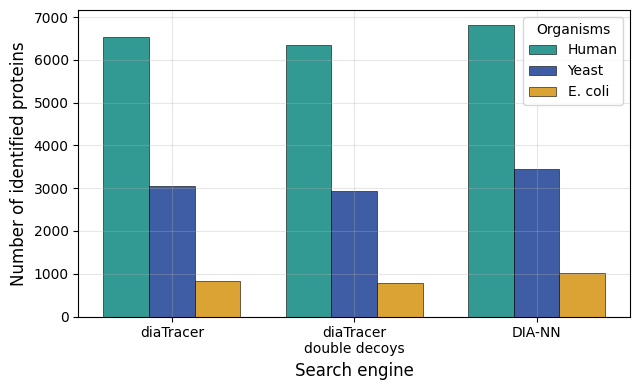

In [233]:
saveflag = True

files = [
# './search_results/fragpipe24_LFQbench_umpire/dia-quant-output/report.pg_matrix.tsv', 
# './search_results/fragpipe24_LFQbench_umpire_triqler/dia-quant-output/report.pg_matrix.tsv', 
# './search_results/fragpipe24_LFQbench_msfragger/dia-quant-output/report.pg_matrix.tsv',
# './search_results/fragpipe24_LFQbench_msfragger_triqler/dia-quant-output/report.pg_matrix.tsv',
# './search_results/diann231_LFQbench/report.pg_matrix.tsv', 
'./search_results/fragpipe24_LFQbenchTOF_diatracer/dia-quant-output/report.pg_matrix.tsv',
'./search_results/fragpipe24_LFQbenchTOF_diatracer_triqler/dia-quant-output/report.pg_matrix.tsv',
'./search_results/diann231_LFQbenchTOF/report.pg_matrix.tsv', 
]

names = ['diaTracer', 'diaTracer\ndouble decoys', 'DIA-NN']
num_prots = {}
num_prots_by_organism = {}

for file, name in zip(files, names):
    tdf = pd.read_csv(file, sep='\t', usecols=['Protein.Group'])
    tdf['Organism'] = tdf['Protein.Group'].map(lfqbench_organism_dict)
    # tdf['Organism'] = tdf['Protein.Ids'].apply(lambda x : ';'.join(set([prot_id_name_dct[p].split('_')[-1] for p in x.split(';')])))
    num_prots[name] = len(set(tdf['Protein.Group']))
    num_prots_by_organism[name] = {}
    for org in sorted(set(tdf['Organism'])) :
        num_prots_by_organism[name][org] = len(set(tdf[tdf['Organism'] == org]['Protein.Group']))

tools = list([key for key in num_prots_by_organism.keys() if not ';' in key])
organisms = ['Human', 'Yeast', 'Ecoli', ]
organism_name = {'Human':'Human', 'Yeast':'Yeast', 'Ecoli':'E. coli',}
colors = ['#008178', '#0F358D', '#D28C00', '#883B00', '#6482C6', ]

# Set up the bar positions
x = np.arange(len(tools))  # positions for tools
width = 0.25  # width of bars
multiplier = 0

# Create the plot
fig, ax = plt.subplots(figsize=(6.5, 4))

# Plot bars for each organism
for organism, c in zip(organisms, colors):
    values = [num_prots_by_organism[tool][organism] for tool in tools]
    offset = width * multiplier
    ax.bar(x + offset, values, width, label=organism_name[organism], color=c, edgecolor='black', linewidth=.5, alpha=0.8)
    multiplier += 1

print(num_prots_by_organism)
ax.set_xlabel('Search engine', fontsize=12)
ax.set_ylabel('Number of identified proteins', fontsize=12)
# ax.set_title('Protein Counts by Tool and Organism', fontsize=14)
ax.set_xticks(x + width)
ax.set_xticklabels(tools)
# ax.set_yticks([0, ] + list(np.arange(500, 6500, 1000)))
# ax.legend()
ax.grid(True, alpha=0.3)

# legend_elements = [
#     Line2D([0], [0], color = 'w', markerfacecolor = colors[1], marker = 's', markersize = 5,
#               markeredgecolor = 'k',  markeredgewidth = .1, label = 'E. coli'),
#     Line2D([0], [0], color = 'w', markerfacecolor = colors[2], marker = 's', markersize = 5,
#               markeredgecolor = 'k',  markeredgewidth = .1, label = 'Yeast'),
#     Line2D([0], [0], color = 'w', markerfacecolor = colors[0], marker = 's', markersize = 5,
#               markeredgecolor = 'k',  markeredgewidth = .1, label = 'Human'),
#                 ]
ax.legend(fontsize = 10, loc='upper right', title='Organisms')
ax.tick_params(axis='x', which='major',  rotation=0) #labelsize=16,
fig.tight_layout()
fig.show()
if saveflag :
    fig.savefig('./figures/LFQ_TOF_identifications_with_double_fasta.svg')

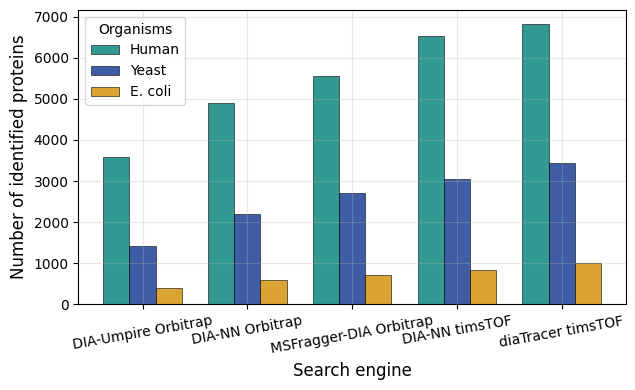

In [99]:
saveflag = True

files = [
'./search_results/fragpipe24_LFQbench_umpire/dia-quant-output/report.pg_matrix.tsv', 
'./search_results/fragpipe24_LFQbench_msfragger/dia-quant-output/report.pg_matrix.tsv',
'./search_results/diann231_LFQbench/report.pg_matrix.tsv', 
'./search_results/fragpipe24_LFQbenchTOF_diatracer/dia-quant-output/report.pg_matrix.tsv',
'./search_results/diann231_LFQbenchTOF/report.pg_matrix.tsv', 
]

names = ['DIA-Umpire Orbitrap', 'DIA-NN Orbitrap',  'MSFragger-DIA Orbitrap', 'DIA-NN timsTOF', 'diaTracer timsTOF']
num_prots = {}
num_prots_by_organism = {}

for file, name in zip(files, names):
    tdf = pd.read_csv(file, sep='\t', usecols=['Protein.Group'])
    tdf['Organism'] = tdf['Protein.Group'].map(lfqbench_organism_dict)
    # tdf['Organism'] = tdf['Protein.Ids'].apply(lambda x : ';'.join(set([prot_id_name_dct[p].split('_')[-1] for p in x.split(';')])))
    num_prots[name] = len(set(tdf['Protein.Group']))
    num_prots_by_organism[name] = {}
    for org in sorted(set(tdf['Organism'])) :
        num_prots_by_organism[name][org] = len(set(tdf[tdf['Organism'] == org]['Protein.Group']))

tools = list([key for key in num_prots_by_organism.keys() if not ';' in key])
organisms = ['Human', 'Yeast', 'Ecoli', ]
organism_name = {'Human':'Human', 'Yeast':'Yeast', 'Ecoli':'E. coli',}
colors = ['#008178', '#0F358D', '#D28C00', '#883B00', '#6482C6', ]

# Set up the bar positions
x = np.arange(len(tools))  # positions for tools
width = 0.25  # width of bars
multiplier = 0

# Create the plot
fig, ax = plt.subplots(figsize=(6.5, 4))

# Plot bars for each organism
for organism, c in zip(organisms, colors):
    values = [num_prots_by_organism[tool][organism] for tool in tools]
    offset = width * multiplier
    ax.bar(x + offset, values, width, label=organism_name[organism], color=c, edgecolor='black', linewidth=.5, alpha=0.8)
    multiplier += 1

# Customize the plot
ax.set_xlabel('Search engine', fontsize=12)
ax.set_ylabel('Number of identified proteins', fontsize=12)
# ax.set_title('Protein Counts by Tool and Organism', fontsize=14)
ax.set_xticks(x + width)
ax.set_xticklabels(tools)
# ax.set_yticks([0, ] + list(np.arange(500, 6500, 1000)))
# ax.legend()
ax.grid(True, alpha=0.3)

# legend_elements = [
#     Line2D([0], [0], color = 'w', markerfacecolor = colors[1], marker = 's', markersize = 5,
#               markeredgecolor = 'k',  markeredgewidth = .1, label = 'E. coli'),
#     Line2D([0], [0], color = 'w', markerfacecolor = colors[2], marker = 's', markersize = 5,
#               markeredgecolor = 'k',  markeredgewidth = .1, label = 'Yeast'),
#     Line2D([0], [0], color = 'w', markerfacecolor = colors[0], marker = 's', markersize = 5,
#               markeredgecolor = 'k',  markeredgewidth = .1, label = 'Human'),
#                 ]
ax.legend(fontsize = 10, loc='upper left', title='Organisms')
ax.tick_params(axis='x', which='major',  rotation=10) #labelsize=16,
fig.tight_layout()
fig.show()
if saveflag :
    fig.savefig('./figures/LFQ_identifications_3search_engines.svg')

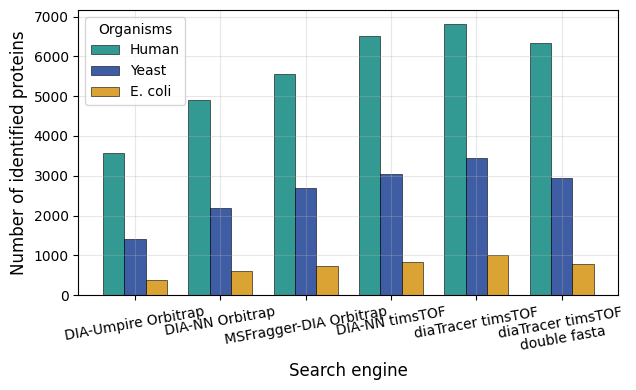

In [111]:
saveflag = True

files = [
'./search_results/fragpipe24_LFQbench_umpire/dia-quant-output/report.pg_matrix.tsv', 
'./search_results/fragpipe24_LFQbench_msfragger/dia-quant-output/report.pg_matrix.tsv',
'./search_results/diann231_LFQbench/report.pg_matrix.tsv', 
'./search_results/fragpipe24_LFQbenchTOF_diatracer/dia-quant-output/report.pg_matrix.tsv',
'./search_results/diann231_LFQbenchTOF/report.pg_matrix.tsv', 
'./search_results/fragpipe24_LFQbenchTOF_diatracer_triqler/dia-quant-output/report.pg_matrix.tsv',
]

names = ['DIA-Umpire Orbitrap', 'DIA-NN Orbitrap',  'MSFragger-DIA Orbitrap', 'DIA-NN timsTOF', 'diaTracer timsTOF', 'diaTracer timsTOF\ndouble fasta']
num_prots = {}
num_prots_by_organism = {}

for file, name in zip(files, names):
    tdf = pd.read_csv(file, sep='\t', usecols=['Protein.Group'])
    tdf['Organism'] = tdf['Protein.Group'].map(lfqbench_organism_dict)
    # tdf['Organism'] = tdf['Protein.Ids'].apply(lambda x : ';'.join(set([prot_id_name_dct[p].split('_')[-1] for p in x.split(';')])))
    num_prots[name] = len(set(tdf['Protein.Group']))
    num_prots_by_organism[name] = {}
    for org in sorted(set(tdf['Organism'])) :
        num_prots_by_organism[name][org] = len(set(tdf[tdf['Organism'] == org]['Protein.Group']))

tools = list([key for key in num_prots_by_organism.keys() if not ';' in key])
organisms = ['Human', 'Yeast', 'Ecoli', ]
organism_name = {'Human':'Human', 'Yeast':'Yeast', 'Ecoli':'E. coli',}
colors = ['#008178', '#0F358D', '#D28C00', '#883B00', '#6482C6', ]

# Set up the bar positions
x = np.arange(len(tools))  # positions for tools
width = 0.25  # width of bars
multiplier = 0

# Create the plot
fig, ax = plt.subplots(figsize=(6.5, 4))

# Plot bars for each organism
for organism, c in zip(organisms, colors):
    values = [num_prots_by_organism[tool][organism] for tool in tools]
    offset = width * multiplier
    ax.bar(x + offset, values, width, label=organism_name[organism], color=c, edgecolor='black', linewidth=.5, alpha=0.8)
    multiplier += 1

# Customize the plot
ax.set_xlabel('Search engine', fontsize=12)
ax.set_ylabel('Number of identified proteins', fontsize=12)
# ax.set_title('Protein Counts by Tool and Organism', fontsize=14)
ax.set_xticks(x + width)
ax.set_xticklabels(tools)
# ax.set_yticks([0, ] + list(np.arange(500, 6500, 1000)))
# ax.legend()
ax.grid(True, alpha=0.3)

# legend_elements = [
#     Line2D([0], [0], color = 'w', markerfacecolor = colors[1], marker = 's', markersize = 5,
#               markeredgecolor = 'k',  markeredgewidth = .1, label = 'E. coli'),
#     Line2D([0], [0], color = 'w', markerfacecolor = colors[2], marker = 's', markersize = 5,
#               markeredgecolor = 'k',  markeredgewidth = .1, label = 'Yeast'),
#     Line2D([0], [0], color = 'w', markerfacecolor = colors[0], marker = 's', markersize = 5,
#               markeredgecolor = 'k',  markeredgewidth = .1, label = 'Human'),
#                 ]
ax.legend(fontsize = 10, loc='upper left', title='Organisms')
ax.tick_params(axis='x', which='major',  rotation=10) #labelsize=16,
fig.tight_layout()
fig.show()
if saveflag :
    fig.savefig('./figures/LFQ_identifications_3search_engines.svg')

# Numbers of identifications UPS-Ecoli

# LFQbench timsTOF volcanos

0 ./quantitation/diann231_LFQbench_quant_manual_min.tsv
0 ./quantitation/diann231_LFQbench_quant_manual_min.tsv
2 ./quantitation/diann231_LFQbenchTOF_quant_manual_min.tsv
2 ./quantitation/diann231_LFQbenchTOF_quant_manual_min.tsv
4 ./quantitation/fragpipe24_LFQbenchTOF_diatracer_quant_manual_min.tsv
4 ./quantitation/fragpipe24_LFQbenchTOF_diatracer_quant_manual_min.tsv
0 ./quantitation/diann231_LFQbench_quant_directlfq_min.tsv
0 ./quantitation/diann231_LFQbench_quant_directlfq_min.tsv
2 ./quantitation/diann231_LFQbenchTOF_quant_directlfq_min.tsv
2 ./quantitation/diann231_LFQbenchTOF_quant_directlfq_min.tsv
4 ./quantitation/fragpipe24_LFQbenchTOF_diatracer_quant_directlfq_min.tsv
4 ./quantitation/fragpipe24_LFQbenchTOF_diatracer_quant_directlfq_min.tsv
0 ./quantitation/diann231_LFQbench_quant_alphastats_mean.tsv
0 ./quantitation/diann231_LFQbench_quant_alphastats_mean.tsv
2 ./quantitation/diann231_LFQbenchTOF_quant_alphastats_mean.tsv
2 ./quantitation/diann231_LFQbenchTOF_quant_alphasta

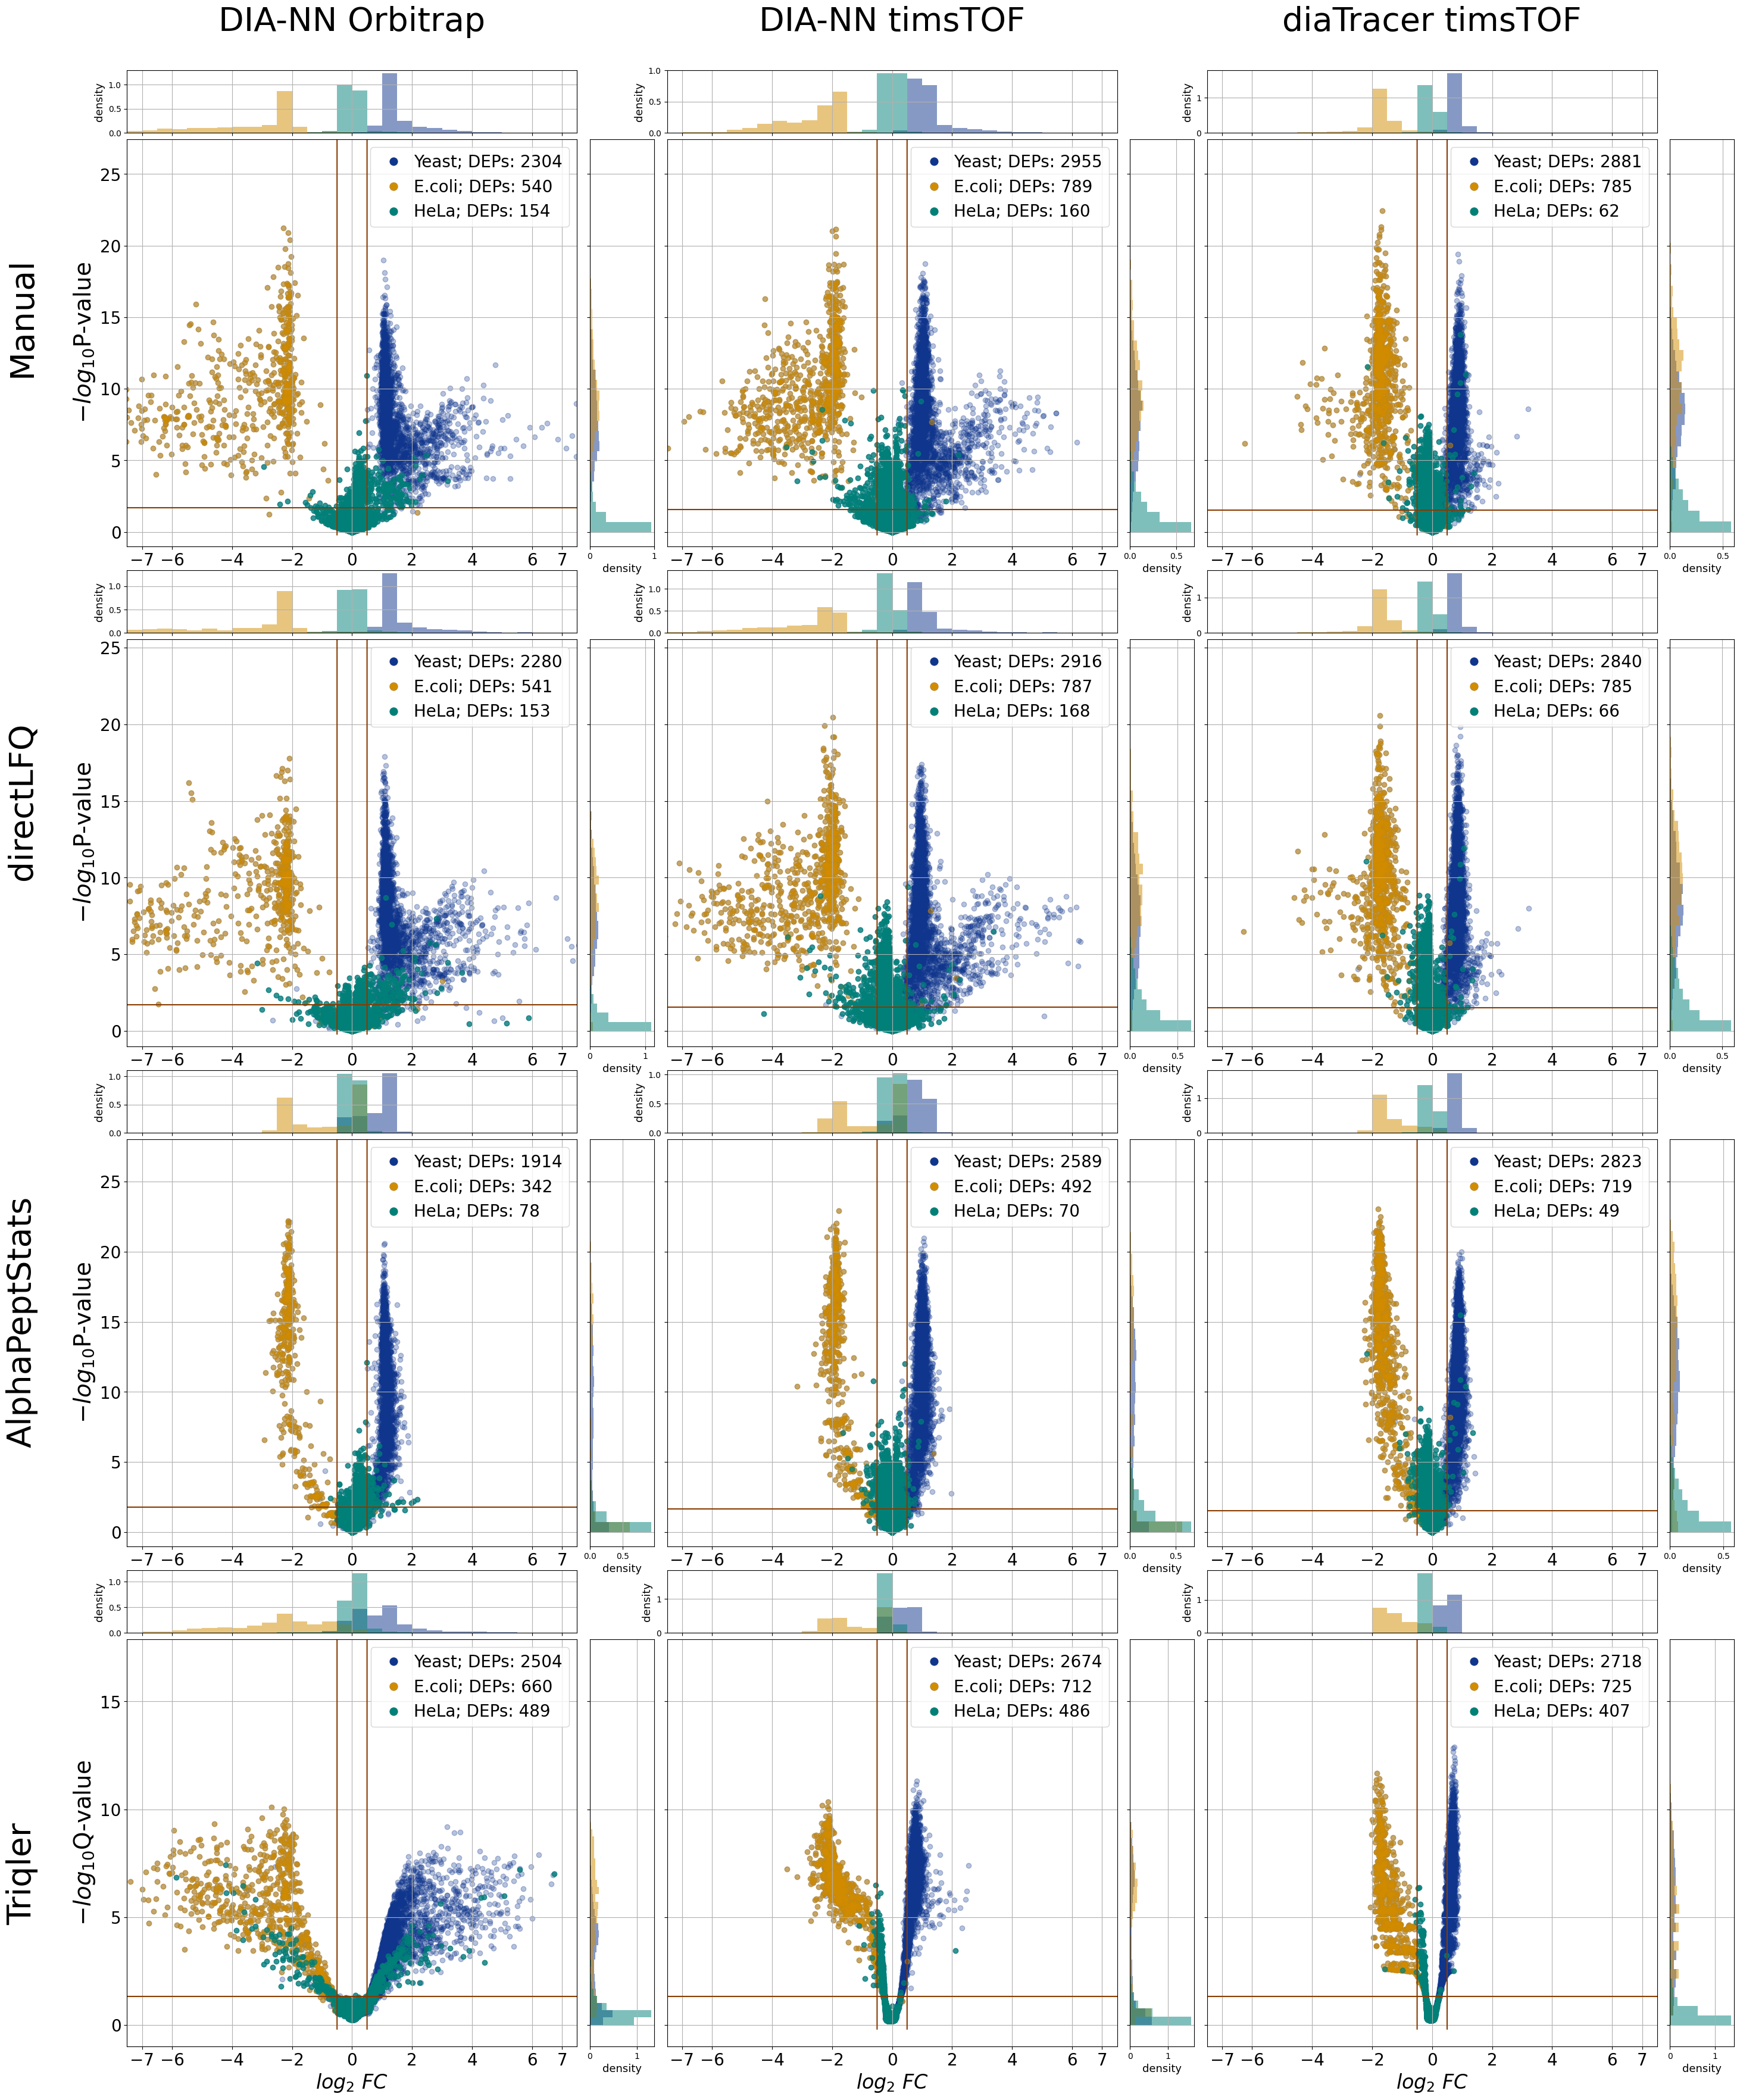

In [186]:
folder = './quantitation'
quant_tools = ['manual', 'directlfq', 'alphastats','triqler']

# quant_tools = ['manual', 'directLFQ', 'AlphaPeptStats','Triqler']
search_engines = {'diann':'DIA-NN Orbitrap',
                  'diann tof':'DIA-NN timsTOF', 
                  'diatracer':'diaTracer timsTOF', 
                  }

search_engines_file_mask = {  'diann':'diann231_LFQbench_quant_{}{}.tsv', 
                              'diann tof':'diann231_LFQbenchTOF_quant_{}{}.tsv', 
                              'diatracer':'fragpipe24_LFQbenchTOF_diatracer_quant_{}{}.tsv'}

quant_tools_full = {'manual':'Manual', 'directlfq':'directLFQ', 'alphastats':'AlphaPeptStats', 'triqler':'Triqler'}
alphastats_imp = 'mean'
imputation = {'alphastats':'_'+alphastats_imp, 'directlfq':'_min', 'manual':'_min', 'triqler':'_opt'}

fdr_col = {'manual':'pval', 'directlfq':'pval', 'alphastats':'pval','triqler':'q_value'}
fdr_pass = defaultdict(lambda:'FDR_pass')
fc_col = {'manual':'log2_FC', 'directlfq':'log2_FC', 'alphastats':'log2fc','triqler':'log2_FC'}
fc_pass = 'FC_pass'

colors = ['#008178', '#D28C00', '#0F358D', '#883B00', '#6482C6']
csfont = {'fontname':'sans-serif'}
base_fontsize = 20
cm = 1/2.54

fig = plt.figure(figsize=(30, 40))

h=0.2
space=0.01
zero_lvl = 0.9

xlim = [-7.5, 7.5]
xticks = [-7, -6, -4, -2, 0, 2, 4, 6, 7]
border_fc = 0.5


axes = []
for j in range(4) :
    bbot, ttop = zero_lvl-(j)*(space+h)-h, zero_lvl-(j)*(space+h)
    # print(bbot, ttop)
    axe1, axe2 = [], []
    gs1 = GridSpec(7, 21, bottom=bbot, top=ttop, left=0.05, right=0.95, wspace=0.2, hspace=0.1)
    mult = 7
    for i in range(3) :
        ax1 = fig.add_subplot(gs1[0, i*mult:(i+1)*mult-1])
        ax2 = fig.add_subplot(gs1[0, (i+1)*mult-1])
        ax3 = fig.add_subplot(gs1[1:, i*mult:(i+1)*mult-1])
        ax4 = fig.add_subplot(gs1[1:, (i+1)*mult-1])
        axe1.append(ax1)
        axe1.append(ax2)
        axe2.append(ax3)
        axe2.append(ax4)
    axes.append(axe1)
    axes.append(axe2)

mx_x = []
ll = 2

for j, quant in zip([0, 2, 4, 6], quant_tools) :
    up = []
    down = []
    mx_y = []
    reg_human = []
    reg_ecoli = []
    reg_yeast = []
    
    for i, engine in zip([0, 2, 4, ], search_engines) :
        filepath = path.join(folder, search_engines_file_mask[engine].format(quant, imputation[quant]))
        print(i, filepath)
        if quant == 'triqler' and engine == 'diatracer' :
            filepath = filepath.replace('_quant', '_triqler')
        elif quant == 'triqler' :
            filepath = filepath.replace('_quant', '')
        print(i, filepath)
        table = pd.read_csv(filepath, sep = '\t')
        fdr_col_name = fdr_col[quant]
        # table['log2_FC'] = np.log2(table['s1']/table['s2'])
        # table['FC'] = table['s1']/table['s2']
        if 'Protein.Group' in table.columns :
            prot_col = 'Protein.Group'
        else :
            prot_col = 'protein'
        # table['Human'] = table[prot_col].apply(lambda x: True if (x.find('HUMAN') >= 0 and x.find('ECOLI') < 0 and x.find('YEAST') < 0) else False)
        # table['Ecoli'] = table[prot_col].apply(lambda x: True if (x.find('HUMAN') < 0 and x.find('ECOLI') >= 0 and x.find('YEAST') < 0) else False)
        # table['Yeast'] = table[prot_col].apply(lambda x: True if (x.find('HUMAN') < 0 and x.find('ECOLI') < 0 and x.find('YEAST') >= 0) else False)
    
        table.sort_values(fdr_col_name, ascending=True, inplace=True)
    
        x = np.array(table[fc_col[quant]])
        y = np.array(-np.log10(table[fdr_col_name]))
        mx_y.append(max(y))
        mx_x.append(max(abs(x)))
        human_mask = np.array(table['Human'] )
        ecoli_mask = np.array(table['Ecoli'] )
        yeast_mask = np.array(table['Yeast'] )
    
        num_proteins = len(table)
        xlim_sum = np.abs(xlim[1] - xlim[0])
        p_line_x = np.arange(xlim[0], xlim[1], xlim_sum/1000)
        if fdr_pass[quant] == 'Bonf_pass' :
            pval = 0.05/num_proteins
        else : 
            pval = max(table[table[fdr_pass[quant]]][fdr_col_name])
        p_y = -np.log10(pval)
        p_line_y = p_y*np.ones(len(p_line_x))
        axes[j+1][i].plot(p_line_x , p_line_y, color=colors[3])
        # print(quant, fdr_pass[quant], pval, p_y)
        
        area = np.array((x, y))
        log10_bonfferroni = -np.log10(0.05/num_proteins)
        bonfferroni = 0.05/num_proteins
    
        mask = []
        for log_fc, p in zip(x, y) :
            if abs(log_fc) >= border_fc and p >= log10_bonfferroni :
                mask.append(True)
            else :
                mask.append(False)
        mask = np.array( mask )
    
        # print(reg_human)
    #    fc_cond = abs(x)>= 1
    #    p_cond = p >= -np.log10(0.05)
    
        # np.ma.masked_where показывает только False маскируя True
        numbins = int(xlim_sum*2)
        xbbins = [xlim[0] + i*xlim_sum/numbins for i in range(numbins) ]
        ybbins = [0 + i*max(y)/numbins for i in range(numbins) ]
        # Yeast
        axes[j+1][i].scatter( np.ma.masked_where( human_mask & ecoli_mask, x), np.ma.masked_where(  human_mask & ecoli_mask , y),
                    color = colors[2], alpha = 0.3, label= 'Yeast')
    
        axes[j][i].hist(x[np.logical_and(~human_mask, ~ecoli_mask)], color = colors[2], alpha = 0.5, bins=xbbins, density=True)
        
        axes[j+1][i+1].hist(y[np.logical_and(~human_mask, ~ecoli_mask)], color = colors[2], orientation='horizontal', alpha = 0.5, bins=ybbins, density=True)
        # Это - E.coli
        axes[j+1][i].scatter( np.ma.masked_where( ~ecoli_mask , x), np.ma.masked_where( ~ecoli_mask , y),
                    color = colors[1], alpha = 0.5, label= 'E.coli')
        axes[j][i].hist(x[ecoli_mask], color = colors[1], alpha = 0.5, bins=xbbins, density=True)
        
        axes[j+1][i+1].hist(y[ecoli_mask], color = colors[1], orientation='horizontal', alpha = 0.5, bins=ybbins, density=True)
    
        # Это - Human
        axes[j+1][i].scatter( np.ma.masked_where( ~human_mask , x), np.ma.masked_where( ~human_mask , y),
                    color = colors[0], alpha = 0.7, label= 'Human')
        axes[j][i].hist(x[human_mask], color = colors[0], alpha = 0.5, bins=xbbins, density=True)
        
        axes[j+1][i+1].hist(y[human_mask], color = colors[0], orientation='horizontal', alpha = 0.5, bins=ybbins, density=True)
        
        reg_human.append(len(table[(table[fdr_pass[quant]] & table[fc_pass] & table['Human'])]))
        reg_ecoli.append(len(table[(table[fdr_pass[quant]] & table[fc_pass] & table['Ecoli'])]))
        reg_yeast.append(len(table[(table[fdr_pass[quant]] & table[fc_pass] & table['Yeast'])]))
        # print(engine, quant, reg_human[-1], reg_ecoli[-1], reg_yeast[-1])
        fig.delaxes(axes[j][i+1])

        xlim_sum = sum([abs(el) for el in xlim])
        axes[j+1][i].set_xlim(xlim)
        axes[j][i].set_xlim(xlim)
        axes[j+1][i].set_xticks(xticks)
        axes[j][i].set_xticks(xticks)
        axes[j+1][i].tick_params(axis='both', which='major', labelsize=base_fontsize)
        if i == 0 :
            if quant == 'triqler' :
                ax_stat_name = 'Q-value'
                axes[j+1][i].text(-11, 7, quant_tools_full[quant], size=base_fontsize*2, rotation=90, ha='center', va='center')
            else :
                ax_stat_name = 'P-value'
                axes[j+1][i].text(-11, 15, quant_tools_full[quant], size=base_fontsize*2, rotation=90, ha='center', va='center')
            axes[j+1][i].set_ylabel(r'$-log_{10}$' + ax_stat_name, size = base_fontsize*1.4, **csfont)
        else :
            axes[j+1][i].set_ylabel(r'', size = base_fontsize*0.6, **csfont)
        if j == 6 :
            axes[j+1][i].set_xlabel(r'$log_{2}\ FC$', size = base_fontsize*1.2, **csfont)
        elif j == 0 :
            axes[j+1][i].text(0, 35, search_engines[engine], size=base_fontsize*2, ha='center')
        else :
            axes[j+1][i].set_xlabel(r'', size = base_fontsize*0.6, **csfont)
        axes[j][i].set_ylabel('density', size = base_fontsize*0.65, **csfont)
        axes[j+1][i+1].set_xlabel('density', size = base_fontsize*0.65, rotation=0, **csfont)
        # axes[j][i].set_title(search_engines[engine]+' '+quant, size = 28, **csfont)
        
        legend_elements = [
                Line2D([0], [0], color = 'w', markerfacecolor = colors[2], marker = 'o', markersize = 5,
                          markeredgecolor = 'k',  markeredgewidth = .1, label = 'Yeast; DEPs: {}'.format(reg_yeast[-1])),
                Line2D([0], [0], color = 'w', markerfacecolor = colors[1], marker = 'o', markersize = 5,
                          markeredgecolor = 'k',  markeredgewidth = .1, label = 'E.coli; DEPs: {}'.format(reg_ecoli[-1])),
                Line2D([0], [0], color = 'w', markerfacecolor = colors[0], marker = 'o', markersize = 5,
                          markeredgecolor = 'k',  markeredgewidth = .1, label = 'HeLa; DEPs: {}'.format(reg_human[-1])),
                            ]
        axes[j+1][i].legend(handles = legend_elements, fontsize = base_fontsize, markerscale = 2., loc='upper right', handletextpad=0.2)  
        
    for i, hum, enum, ynum in zip([0, 2, 4, ], reg_human, reg_ecoli,reg_yeast ) :
        axes[j+1][i].set_yticks(np.arange(0, max(mx_y)+5, 5))
        axes[j+1][i+1].set_yticks(np.arange(0, max(mx_y)+5, 5))
        axes[j+1][i].set_ylim([-1, max(mx_y)+5])
        axes[j+1][i+1].set_ylim([-1, max(mx_y)+5])
        fc_line_y = np.arange(-0.2, max(mx_y)+5+0.2, 0.01)
        fc_line_x1 = border_fc*np.ones(len(fc_line_y),)
        fc_line_x2 = -border_fc*np.ones(len(fc_line_y),)
        axes[j+1][i].plot(fc_line_x1 , fc_line_y, color=colors[3])
        axes[j+1][i].plot(fc_line_x2 , fc_line_y, color=colors[3])
        text_y = max(mx_y)*0.7
        # axes[j+1][i].text( 4.05, text_y, 'Yeast: \nE.coli: \nHeLa: ', size = 20, style='italic')
        # axes[j+1][i].text( 5.75, text_y, '{}\n{}\n{}'.format(ynum, enum, hum), size = 20, color='red')
        axes[j+1][i+1].tick_params(axis="y", labelleft=False)
        axes[j][i+1].tick_params(axis="y", labelleft=False)
        axes[j][i].tick_params(axis="x", labelbottom=False)
        axes[j+1][i+1].grid()
        axes[j+1][i].grid()
        axes[j][i].grid()
        if i > 0 :
            axes[j+1][i].tick_params(axis="y", labelleft=False)

savepath = './figures/LFQbenchTOF_volcano_3x4.svg'
plt.savefig(savepath, format=savepath.split('.')[-1], dpi=300, bbox_inches='tight')
plt.savefig(savepath.replace('.svg', '.png'), format='png', dpi=300, bbox_inches='tight')
fig.show()

# Fig 2D, S7 LFQbench TOF Heatmap of DEPs DIA-NN Triqler with different settings 

In [4]:
folder = './quantitation'
quant_tools = ['triqler', 
               # 'triqler_035',
               'triqler_029', 
                'triqler_027',
               'triqler_025',
               # 'triqler_032', 
               'triqler_opt_mins9']
search_engines = {#'diann':'DIA-NN Orbitrap',
                  # 'diann tof':'DIA-NN timsTOF', 
                  'diatracer':'diaTracer timsTOF', 
                  }

search_engines_file_mask = {  'diann':'diann231_LFQbench_quant_{}{}.tsv', 
                              'diann tof':'diann231_LFQbenchTOF_quant_{}{}.tsv', 
                                'diatracer':'fragpipe24_LFQbenchTOF_diatracer_quant_{}{}.tsv'
}



quant_tools_full = {'triqler':'Fixed\n(0.5)',
                    # 'triqler_output_st_mins9':'FC fixed (0.5)', 
                    'triqler_025':'\n(0.25)', 
                    'triqler_027':'\n(0.27)', 
                    'triqler_029':'\n(0.29)', 
                    'triqler_032':'\n(0.32)', 
                    'triqler_035':'\n(0.35)', 
                    # 'triqler_04':'FC empirical\n(0.40)', 
                    # 'triqler_043':'FC empirical\n(0.43)', 
                    # 'triqler_046':'FC empirical\n(0.46)', 
                    'triqler_opt_mins9':'Optimized\n(0.22)',}
alphastats_imp = 'mean'
imputation = {'triqler':'', 
              'triqler_output_st_mins9':'', 
              'triqler_025':'',
              'triqler_027':'',
              'triqler_029':'',
              'triqler_032':'',
              'triqler_035':'',
              'triqler_04':'',
              'triqler_043':'',
              'triqler_046':'',
              'triqler_opt_mins9':'',}
fdr_pass = defaultdict(lambda:'FDR_pass')
organisms = ['Yeast', 'Ecoli', 'Human']
# print(quant_tools, search_engines)
deps = {}
for search_engine in search_engines :
    deps[search_engine] = {}
    for quant_tool in quant_tools :
        print(search_engine, quant_tool)
        deps[search_engine][quant_tool] = {'Ecoli':0, 'Yeast':0, 'Human':0 }
        filepath = path.join(folder, search_engines_file_mask[search_engine].format(quant_tool, imputation[quant_tool]))
        if 'triqler' in quant_tool  and not 'diann' in search_engine :
            filepath = filepath.replace('_quant', '_triqler')
        elif 'triqler' in quant_tool :
            filepath = filepath.replace('_quant', '')
        # if quant_tool == 'triqler' :
        #     if search_engine in ['diann tof', 'diatracer'] :
        #         filepath = filepath.replace('.tsv', '_035.tsv')
            
        df = pd.read_csv(filepath, sep='\t')

        for org in organisms :
            deps[search_engine][quant_tool][org] = len(df[(df['Organism'] == org) & (df[fdr_pass[quant_tool]]) & (df['FC_pass'])])
            # fc_range = np.abs(df[(df['Organism'] == org) & (df[fdr_pass[quant_tool]]) & (df['FC_pass'])]['log2_FC'].max() - df[(df['Organism'] == org) & (df[fdr_pass[quant_tool]]) & (df['FC_pass'])]['log2_FC'].min())
        # print(fname, df['Search Engine'][0], df['Quantitation'][0], df['Imputation'][0], *[deps[search_engine][quant_tool][org] for org in organisms], sep='\t')
        print(filepath, fdr_pass[org], *[deps[search_engine][quant_tool][org] for org in organisms], sum([deps[search_engine][quant_tool][org] for org in organisms]), sep='\t')
print(deps)

diatracer triqler
./quantitation/fragpipe24_LFQbenchTOF_diatracer_triqler_triqler.tsv	FDR_pass	1560	649	5	2214
diatracer triqler_029
./quantitation/fragpipe24_LFQbenchTOF_diatracer_triqler_triqler_029.tsv	FDR_pass	2578	703	101	3382
diatracer triqler_027
./quantitation/fragpipe24_LFQbenchTOF_diatracer_triqler_triqler_027.tsv	FDR_pass	2614	709	140	3463
diatracer triqler_025
./quantitation/fragpipe24_LFQbenchTOF_diatracer_triqler_triqler_025.tsv	FDR_pass	2661	712	226	3599
diatracer triqler_opt_mins9
./quantitation/fragpipe24_LFQbenchTOF_diatracer_triqler_triqler_opt_mins9.tsv	FDR_pass	2721	722	404	3847
{'diatracer': {'triqler': {'Ecoli': 649, 'Yeast': 1560, 'Human': 5}, 'triqler_029': {'Ecoli': 703, 'Yeast': 2578, 'Human': 101}, 'triqler_027': {'Ecoli': 709, 'Yeast': 2614, 'Human': 140}, 'triqler_025': {'Ecoli': 712, 'Yeast': 2661, 'Human': 226}, 'triqler_opt_mins9': {'Ecoli': 722, 'Yeast': 2721, 'Human': 404}}}


In [5]:
filepath = './quantitation/fragpipe24_LFQbenchTOF_diatracer_triqler_triqler_027.tsv'
table = pd.read_csv(filepath, sep = '\t')
border_fc = table.loc[1, 'FC_thr']
print(border_fc)

0.27


triqler FDR_pass 0.04998 1.3012037482095689
triqler_027 FDR_pass 0.04993 1.3016384339448903
triqler_opt_mins9 FDR_pass 0.04995 1.301464507437999


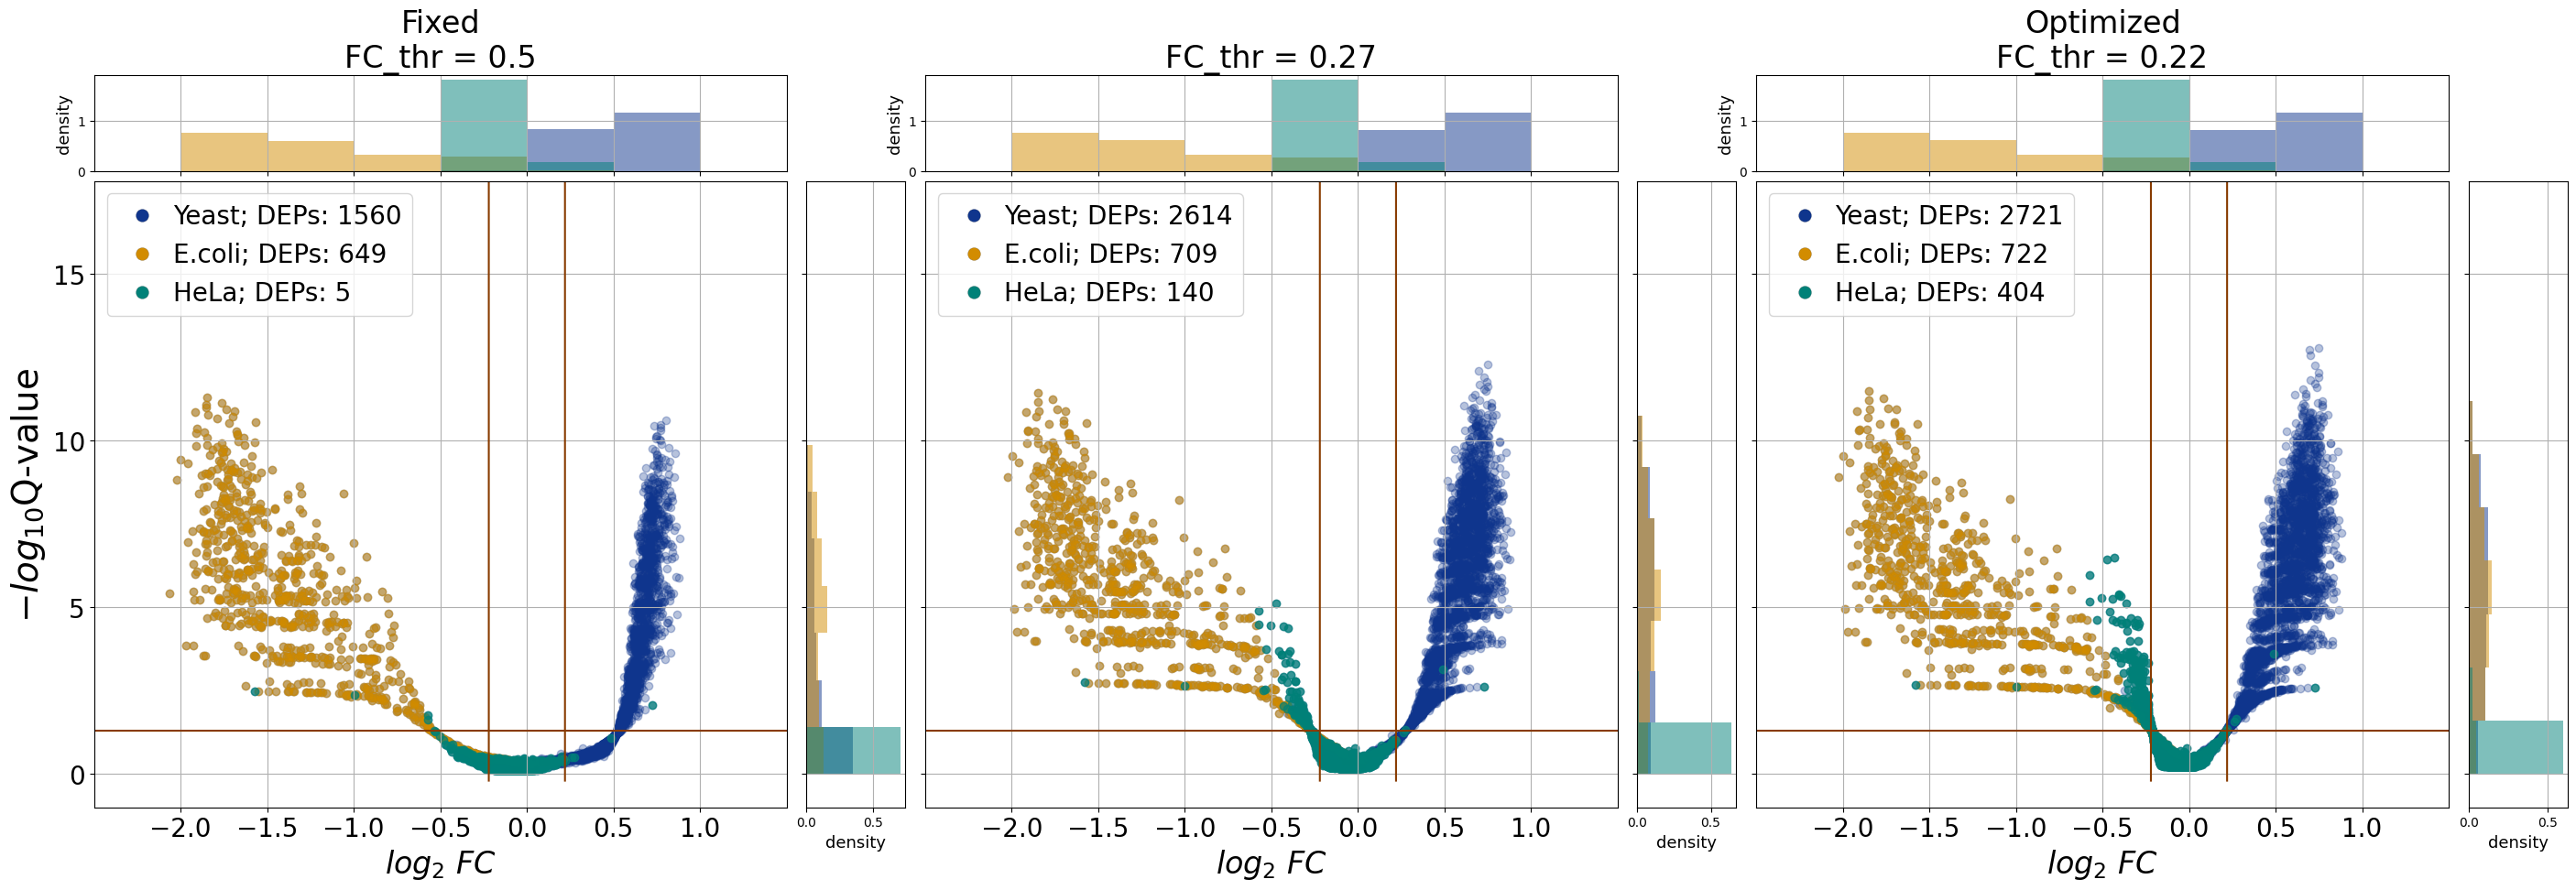

In [16]:
folder = './quantitation'
quant_tools = ['triqler', 'triqler_027', 'triqler_opt_mins9']

# quant_tools = ['manual', 'directLFQ', 'AlphaPeptStats','Triqler']
search_engines = {'diatracer':'diaTracer timsTOF', }

search_engines_file_mask = {  #'diann':'diann231_LFQbench_quant_{}{}.tsv', 
#                               'umpire':'fragpipe24_LFQbench_umpire_quant_{}{}.tsv', 
#                               'msfragger':'fragpipe24_LFQbench_msfragger_quant_{}{}.tsv'
                              'diatracer':'fragpipe24_LFQbenchTOF_diatracer_quant_{}{}.tsv',
                           }

quant_tools_full = {'triqler':'Fixed\nFC_thr = 0.5',
                    # 'triqler_output_st_mins9':'FC fixed (0.5)', 
                    'triqler_025':'\nFC_thr = 0.25', 
                    'triqler_027':'\nFC_thr = 0.27', 
                    'triqler_029':'\nFC_thr = 0.29', 
                    'triqler_032':'\nFC_thr = 0.32', 
                    'triqler_035':'\nFC_thr = 0.35', 
                    # 'triqler_04':'FC empirical\n(0.40)', 
                    # 'triqler_043':'FC empirical\n(0.43)', 
                    # 'triqler_046':'FC empirical\n(0.46)', 
                    'triqler_opt_mins9':'Optimized\nFC_thr = 0.22',}
imputation = defaultdict(lambda:'')
alphastats_imp = 'randomforest'
imputation.update({'alphastats':'_'+alphastats_imp, 'directlfq':'_min', 'manual':'_min', 'triqler':''})

fdr_col = defaultdict(lambda:'q_value')
# fdr_col = {'manual':'pval', 'directlfq':'pval', 'alphastats':'pval','triqler':'q_value'}
fdr_pass = defaultdict(lambda:'FDR_pass')
fc_col = defaultdict(lambda:'log2_FC')
# fc_col = {'manual':'log2_FC', 'directlfq':'log2_FC', 'alphastats':'log2fc','triqler':'log2_FC'}
fc_pass = 'FC_pass'

colors = ['#008178', '#D28C00', '#0F358D', '#883B00', '#6482C6']
csfont = {'fontname':'sans-serif'}
base_fontsize = 20
cm = 1/2.54

fig = plt.figure(figsize=(30, 40))

h=0.2
space=0.01
zero_lvl = 0.9

xlim = [-2.5, 1.5]
xticks = [-2, -1.5, -1, -0.5, 0, 0.5, 1, ]
border_fc = 0.5


axes = []
for j in range(len(search_engines)) :
    bbot, ttop = zero_lvl-(j)*(space+h)-h, zero_lvl-(j)*(space+h)
    # print(bbot, ttop)
    axe1, axe2 = [], []
    gs1 = GridSpec(7, 21, bottom=bbot, top=ttop, left=0.05, right=0.95, wspace=0.2, hspace=0.1)
    mult = 7
    for i in range(len(quant_tools)) :
        ax1 = fig.add_subplot(gs1[0, i*mult:(i+1)*mult-1])
        ax2 = fig.add_subplot(gs1[0, (i+1)*mult-1])
        ax3 = fig.add_subplot(gs1[1:, i*mult:(i+1)*mult-1])
        ax4 = fig.add_subplot(gs1[1:, (i+1)*mult-1])
        axe1.append(ax1)
        axe1.append(ax2)
        axe2.append(ax3)
        axe2.append(ax4)
    axes.append(axe1)
    axes.append(axe2)

mx_x = []
ll = 2

fc_thresholds = {}
for j, engine in zip([0, 2, 4, 6], search_engines) :
    up = []
    down = []
    mx_y = []
    reg_human = []
    reg_ecoli = []
    reg_yeast = []
    fc_thresholds[j] = {}
    for i, quant in zip([0, 2, 4, ], quant_tools) :
        filepath = path.join(folder, search_engines_file_mask[engine].format(quant, imputation[quant]))
        if 'triqler' in quant and not 'diann' in engine :
            filepath = filepath.replace('_quant', '_triqler')
        elif 'triqler' in quant :
            filepath = filepath.replace('_quant', '')
        table = pd.read_csv(filepath, sep = '\t')
        border_fc = table.loc[1, 'FC_thr']
        fc_thresholds[j][i] = border_fc
        fdr_col_name = fdr_col[quant]
        # table['log2_FC'] = np.log2(table['s1']/table['s2'])
        # table['FC'] = table['s1']/table['s2']
        if 'Protein.Group' in table.columns :
            prot_col = 'Protein.Group'
        else :
            prot_col = 'protein'
        # table['Human'] = table[prot_col].apply(lambda x: True if (x.find('HUMAN') >= 0 and x.find('ECOLI') < 0 and x.find('YEAST') < 0) else False)
        # table['Ecoli'] = table[prot_col].apply(lambda x: True if (x.find('HUMAN') < 0 and x.find('ECOLI') >= 0 and x.find('YEAST') < 0) else False)
        # table['Yeast'] = table[prot_col].apply(lambda x: True if (x.find('HUMAN') < 0 and x.find('ECOLI') < 0 and x.find('YEAST') >= 0) else False)
    
        table.sort_values(fdr_col_name, ascending=True, inplace=True)
    
        x = np.array(table[fc_col[quant]])
        y = np.array(-np.log10(table[fdr_col_name]))
        mx_y.append(max(y))
        mx_x.append(max(abs(x)))
        human_mask = np.array(table['Human'] )
        ecoli_mask = np.array(table['Ecoli'] )
        yeast_mask = np.array(table['Yeast'] )
    
        num_proteins = len(table)
        xlim_sum = np.abs(xlim[1] - xlim[0])
        p_line_x = np.arange(xlim[0], xlim[1], xlim_sum/1000)
        if fdr_pass[quant] == 'Bonf_pass' :
            pval = 0.05/num_proteins
        else : 
            pval = max(table[table[fdr_pass[quant]]][fdr_col_name])
        p_y = -np.log10(pval)
        p_line_y = p_y*np.ones(len(p_line_x))
        axes[j+1][i].plot(p_line_x , p_line_y, color=colors[3])
        print(quant, fdr_pass[quant], pval, p_y)
        
        area = np.array((x, y))
        log10_bonfferroni = -np.log10(0.05/num_proteins)
        bonfferroni = 0.05/num_proteins
    
        mask = []
        for log_fc, p in zip(x, y) :
            if abs(log_fc) >= border_fc and p >= log10_bonfferroni :
                mask.append(True)
            else :
                mask.append(False)
        mask = np.array( mask )
    
        # np.ma.masked_where показывает только False маскируя True
        numbins = int(xlim_sum*2)
        xbbins = [xlim[0] + i*xlim_sum/numbins for i in range(numbins) ]
        ybbins = [0 + i*max(y)/numbins for i in range(numbins) ]
        # Yeast
        axes[j+1][i].scatter( np.ma.masked_where( human_mask & ecoli_mask, x), np.ma.masked_where(  human_mask & ecoli_mask , y),
                    color = colors[2], alpha = 0.3, label= 'Yeast')
    
        axes[j][i].hist(x[np.logical_and(~human_mask, ~ecoli_mask)], color = colors[2], alpha = 0.5, bins=xbbins, density=True)
        
        axes[j+1][i+1].hist(y[np.logical_and(~human_mask, ~ecoli_mask)], color = colors[2], orientation='horizontal', alpha = 0.5, bins=ybbins, density=True)
        # Это - E.coli
        axes[j+1][i].scatter( np.ma.masked_where( ~ecoli_mask , x), np.ma.masked_where( ~ecoli_mask , y),
                    color = colors[1], alpha = 0.5, label= 'E.coli')
        axes[j][i].hist(x[ecoli_mask], color = colors[1], alpha = 0.5, bins=xbbins, density=True)
        
        axes[j+1][i+1].hist(y[ecoli_mask], color = colors[1], orientation='horizontal', alpha = 0.5, bins=ybbins, density=True)
    
        # Это - Human
        axes[j+1][i].scatter( np.ma.masked_where( ~human_mask , x), np.ma.masked_where( ~human_mask , y),
                    color = colors[0], alpha = 0.7, label= 'Human')
        axes[j][i].hist(x[human_mask], color = colors[0], alpha = 0.5, bins=xbbins, density=True)
        
        axes[j+1][i+1].hist(y[human_mask], color = colors[0], orientation='horizontal', alpha = 0.5, bins=ybbins, density=True)
        
        reg_human.append(len(table[(table[fdr_pass[quant]] & table[fc_pass] & table['Human'])]))
        reg_ecoli.append(len(table[(table[fdr_pass[quant]] & table[fc_pass] & table['Ecoli'])]))
        reg_yeast.append(len(table[(table[fdr_pass[quant]] & table[fc_pass] & table['Yeast'])]))
        # print(engine, quant, reg_human[-1], reg_ecoli[-1], reg_yeast[-1])
        fig.delaxes(axes[j][i+1])

        xlim_sum = sum([abs(el) for el in xlim])
        axes[j+1][i].set_xlim(xlim)
        axes[j][i].set_xlim(xlim)
        axes[j+1][i].set_xticks(xticks)
        axes[j][i].set_xticks(xticks)
        axes[j+1][i].tick_params(axis='both', which='major', labelsize=base_fontsize)
        if i == 0 :
            if 'triqler' in quant :
                ax_stat_name = 'Q-value'
                # axes[j+1][i].text(-11, 7, quant_tools_full[quant], size=base_fontsize*2, rotation=90, ha='center', va='center')
            else :
                ax_stat_name = 'P-value'
                # axes[j+1][i].text(-11, 15, quant_tools_full[quant], size=base_fontsize*2, rotation=90, ha='center', va='center')
            axes[j+1][i].set_ylabel(r'$-log_{10}$' + ax_stat_name, size = base_fontsize*1.4, **csfont)
        else :
            axes[j+1][i].set_ylabel(r'', size = base_fontsize*0.6, **csfont)
        # if j == 6 :
        if j == 0 :
            axes[j+1][i].set_xlabel(r'$log_{2}\ FC$', size = base_fontsize*1.2, **csfont)
            axes[j][i].set_title(quant_tools_full[quant], size = base_fontsize*1.2, **csfont)
        # elif j == 0 :
            # axes[j+1][i].text(0, 35, search_engines[engine], size=base_fontsize*2, ha='center')
        else :
            axes[j+1][i].set_xlabel(r'', size = base_fontsize*0.6, **csfont)
        axes[j][i].set_ylabel('density', size = base_fontsize*0.65, **csfont)
        axes[j+1][i+1].set_xlabel('density', size = base_fontsize*0.65, rotation=0, **csfont)
        # axes[j][i].set_title(search_engines[engine]+' '+quant, size = 28, **csfont)
        
        legend_elements = [
                Line2D([0], [0], color = 'w', markerfacecolor = colors[2], marker = 'o', markersize = 5,
                          markeredgecolor = 'k',  markeredgewidth = .1, label = 'Yeast; DEPs: {}'.format(reg_yeast[-1])),
                Line2D([0], [0], color = 'w', markerfacecolor = colors[1], marker = 'o', markersize = 5,
                          markeredgecolor = 'k',  markeredgewidth = .1, label = 'E.coli; DEPs: {}'.format(reg_ecoli[-1])),
                Line2D([0], [0], color = 'w', markerfacecolor = colors[0], marker = 'o', markersize = 5,
                          markeredgecolor = 'k',  markeredgewidth = .1, label = 'HeLa; DEPs: {}'.format(reg_human[-1])),
                            ]
        axes[j+1][i].legend(handles = legend_elements, fontsize = base_fontsize, markerscale = 2., loc='upper left', handletextpad=0.2)  
        
    for i, hum, enum, ynum in zip([0, 2, 4, ], reg_human, reg_ecoli,reg_yeast ) :
        axes[j+1][i].set_yticks(np.arange(0, max(mx_y)+5, 5))
        axes[j+1][i+1].set_yticks(np.arange(0, max(mx_y)+5, 5))
        axes[j+1][i].set_ylim([-1, max(mx_y)+5])
        axes[j+1][i+1].set_ylim([-1, max(mx_y)+5])
        fc_line_y = np.arange(-0.2, max(mx_y)+5+0.2, 0.01)
        fc_line_x1 = border_fc*np.ones(len(fc_line_y),)
        fc_line_x2 = -border_fc*np.ones(len(fc_line_y),)
        axes[j+1][i].plot(fc_line_x1 , fc_line_y, color=colors[3])
        axes[j+1][i].plot(fc_line_x2 , fc_line_y, color=colors[3])
        text_y = max(mx_y)*0.7
        # axes[j+1][i].text( 4.05, text_y, 'Yeast: \nE.coli: \nHeLa: ', size = 20, style='italic')
        # axes[j+1][i].text( 5.75, text_y, '{}\n{}\n{}'.format(ynum, enum, hum), size = 20, color='red')
        axes[j+1][i+1].tick_params(axis="y", labelleft=False)
        axes[j][i+1].tick_params(axis="y", labelleft=False)
        axes[j][i].tick_params(axis="x", labelbottom=False)
        axes[j+1][i+1].grid()
        axes[j+1][i].grid()
        axes[j][i].grid()
        if i > 0 :
            axes[j+1][i].tick_params(axis="y", labelleft=False)

savepath = './figures/LFQ_triqler_fc_thr_volcano.svg'
plt.savefig(savepath, format=savepath.split('.')[-1], dpi=300, bbox_inches='tight')
fig.show()

0 0
0 1
0 2
0 3
0 4
[0.2, 3.0, 4.0, 6.3, 10.5]


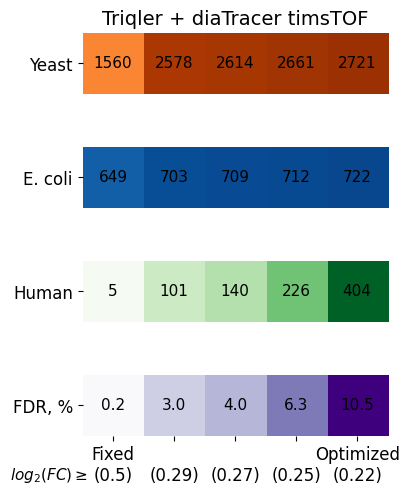

In [304]:
colormap_dict = {'Yeast':'Oranges', 'Ecoli':'Blues', 'Human':'Greens', 'fdr':'Purples'}
org_name = {'Yeast':'Yeast', 'Ecoli':'E. coli', 'Human':'Human'}
deps_lists = {}
for org in organisms :
    deps_lists[org] = [deps[search_engine][quant_tool][org] for search_engine in search_engines for quant_tool in quant_tools]
deps_lists['fdr'] = [round(deps[search_engine][quant_tool]['Human']/(deps[search_engine][quant_tool]['Human']
                                                               + deps[search_engine][quant_tool]['Ecoli']
                                                               + deps[search_engine][quant_tool]['Yeast'])*100,
                          1)
                     for search_engine in search_engines 
                     for quant_tool in quant_tools
                    ]

cm = 1/2.54
fig, axes = plt.subplots(4, 1, figsize=(10*cm, 15*cm), gridspec_kw={'wspace':0.1, 'hspace':0.01, 'height_ratios':[0.25, 0.25, 0.25, 0.25]} )
for ax, org in zip(axes, organisms) :
    se = 0
    for search_engine in search_engines :
    # for search_engine, ax in zip(search_engines, axe) :
        se += 1
        ylabels = [org_name[org]]
        xlabels = [quant_tools_full[quant_tool] for quant_tool in quant_tools]
        
        # org = 'Human'
        data = np.array([ [deps[search_engine][quant_tool][org] for quant_tool in quant_tools] ])
        
        im = ax.imshow(data/np.max(deps_lists[org]), cmap=mpl.colormaps[colormap_dict[org]], vmin=0, vmax=1.1)
        ax.set_xticks([])

        if se == 1 :
            ax.set_yticks(range(len(ylabels)), labels=ylabels, size=12)
        else :
            ax.set_yticks([])
            
        if org == 'Yeast' :
            ax.set_title('Triqler + ' + search_engines[search_engine], size=14)
        # 
        for i in range(len(ylabels)):
            for j in range(len(xlabels)):
                # print(i, j)
                text = ax.text(j, i, data[i][j],
                               ha="center", va="center", color="black", size=11)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['bottom'].set_visible(False)
        ax.spines['left'].set_visible(False)
        # ax.set_title("Harvest of local farmers (in tons/year)")
        # fig.tight_layout()
        # plt.show()
i = 0
# for ax in axes[-1] :
ax = axes[-1]
ylabels = ['FDR, %']
if i == 0 :
    ax.set_yticks(range(len(ylabels)), labels=ylabels, size=12)
else :
    ax.set_yticks([])
im = ax.imshow([deps_lists['fdr'][i*6:(i+1)*6]], cmap=mpl.colormaps[colormap_dict['fdr']], vmin=0, vmax=10)
xlabels = [quant_tools_full[quant_tool] for quant_tool in quant_tools]  
ax.set_xticks(range(len(xlabels)), labels=xlabels, rotation=0, ha="center", rotation_mode="anchor", size=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)
for _ in range(len(search_engines)) :
    for j in range(len(xlabels)):
        print(i, j)
        text = ax.text(j, 0, str(deps_lists['fdr'][i*5+j]),
                       ha="center", va="center", color="black", size=11)
i += 1
text = ax.text(-1.05, 1.15, '$log_2 (FC)\geq$',
               ha="center", va="center", color="black", size=11)
print(deps_lists['fdr'])
savepath = './figures/LFQbenchTOF_diaTracer_Triqler_heatmap_fc.svg'
plt.savefig(savepath, format=savepath.split('.')[-1])

# LFQbench Heatmap of DEPs Triqler opt FC threshold DIA-NN

In [170]:
folder = './quantitation'
quant_tools = ['triqler', 'triqler_opt', 'triqler_opt_mins9']
search_engines = {
    'diann':'DIA-NN Orbitrap',
    # 'diann tof':'DIA-NN timsTOF', 
    # 'diatracer':'diaTracer timsTOF', 
                  }

search_engines_file_mask = {  'diann':'diann231_LFQbench_quant_{}{}.tsv', 
                              # 'diann tof':'diann231_LFQbenchTOF_quant_{}{}.tsv', 
                              # 'diatracer':'fragpipe24_LFQbenchTOF_diatracer_quant_{}{}.tsv'
                           }



quant_tools_full = {'triqler':'Triqler',
                    'triqler_opt':'Triqler opt', 
                    'triqler_opt_mins9':'Triqler opt mins 9',}
alphastats_imp = 'mean'
imputation = {'triqler':'', 
              # 'triqler_output_st_mins9':'', 
              'triqler_opt':'',
              'triqler_opt_mins9':'',}
fdr_pass = defaultdict(lambda:'FDR_pass')
organisms = ['Yeast', 'Ecoli', 'Human']
# print(quant_tools, search_engines)
deps = {}
for search_engine in search_engines :
    deps[search_engine] = {}
    for quant_tool in quant_tools :
        print(search_engine, quant_tool)
        deps[search_engine][quant_tool] = {'Ecoli':0, 'Yeast':0, 'Human':0 }
        filepath = path.join(folder, search_engines_file_mask[search_engine].format(quant_tool, imputation[quant_tool]))
        if 'triqler' in quant_tool  and not 'diann' in search_engine :
            filepath = filepath.replace('_quant', '_triqler')
        elif 'triqler' in quant_tool :
            filepath = filepath.replace('_quant', '')
        # if quant_tool == 'triqler' :
        #     if search_engine in ['diann tof', 'diatracer'] :
        #         filepath = filepath.replace('.tsv', '_035.tsv')
            
        df = pd.read_csv(filepath, sep='\t')

        for org in organisms :
            deps[search_engine][quant_tool][org] = len(df[(df['Organism'] == org) & (df[fdr_pass[quant_tool]]) & (df['FC_pass'])])
            # fc_range = np.abs(df[(df['Organism'] == org) & (df[fdr_pass[quant_tool]]) & (df['FC_pass'])]['log2_FC'].max() - df[(df['Organism'] == org) & (df[fdr_pass[quant_tool]]) & (df['FC_pass'])]['log2_FC'].min())
        # print(fname, df['Search Engine'][0], df['Quantitation'][0], df['Imputation'][0], *[deps[search_engine][quant_tool][org] for org in organisms], sep='\t')
        print(filepath, fdr_pass[org], *[deps[search_engine][quant_tool][org] for org in organisms], sum([deps[search_engine][quant_tool][org] for org in organisms]), sep='\t')
print(deps)

diann triqler
./quantitation/diann231_LFQbench_triqler.tsv	FDR_pass	2192	528	218	2938
diann triqler_opt
./quantitation/diann231_LFQbench_triqler_opt.tsv	FDR_pass	2504	660	489	3653
diann triqler_opt_mins9
./quantitation/diann231_LFQbench_triqler_opt_mins9.tsv	FDR_pass	2223	531	278	3032
{'diann': {'triqler': {'Ecoli': 528, 'Yeast': 2192, 'Human': 218}, 'triqler_opt': {'Ecoli': 660, 'Yeast': 2504, 'Human': 489}, 'triqler_opt_mins9': {'Ecoli': 531, 'Yeast': 2223, 'Human': 278}}}


0 0
0 1
0 2
[7.4, 13.4, 9.2]


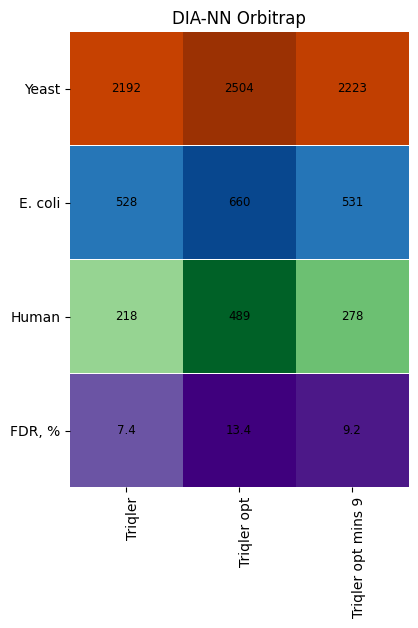

In [171]:
colormap_dict = {'Yeast':'Oranges', 'Ecoli':'Blues', 'Human':'Greens', 'fdr':'Purples'}
org_name = {'Yeast':'Yeast', 'Ecoli':'E. coli', 'Human':'Human'}
deps_lists = {}
for org in organisms :
    deps_lists[org] = [deps[search_engine][quant_tool][org] for search_engine in search_engines for quant_tool in quant_tools]
deps_lists['fdr'] = [round(deps[search_engine][quant_tool]['Human']/(deps[search_engine][quant_tool]['Human']
                                                               + deps[search_engine][quant_tool]['Ecoli']
                                                               + deps[search_engine][quant_tool]['Yeast'])*100,
                          1)
                     for search_engine in search_engines 
                     for quant_tool in quant_tools
                    ]

cm = 1/2.54
fig, axes = plt.subplots(4, 1, figsize=(15*cm, 15*cm), gridspec_kw={'wspace':0.1, 'hspace':0.01, 'height_ratios':[0.25, 0.25, 0.25, 0.25]} )
for ax, org in zip(axes, organisms) :
    se = 0
    for search_engine in search_engines :
    # for search_engine, ax in zip(search_engines, axe) :
        se += 1
        ylabels = [org_name[org]]
        xlabels = [quant_tools_full[quant_tool] for quant_tool in quant_tools]
        
        # org = 'Human'
        data = np.array([ [deps[search_engine][quant_tool][org] for quant_tool in quant_tools] ])
        
        im = ax.imshow(data/np.max(deps_lists[org]), cmap=mpl.colormaps[colormap_dict[org]], vmin=0, vmax=1.1)
        # Show all ticks and label them with the respective list entries
        # if org == 'Human' :
        #     ax.set_xticks(range(len(xlabels)), labels=xlabels, rotation=90, ha="right", rotation_mode="anchor")
        # else :
        ax.set_xticks([])

        if se == 1 :
            ax.set_yticks(range(len(ylabels)), labels=ylabels)
        else :
            ax.set_yticks([])
            
        if org == 'Yeast' :
            ax.set_title(search_engines[search_engine])
        # 
        # Loop over data dimensions and create text annotations.
        for i in range(len(ylabels)):
            for j in range(len(xlabels)):
                # print(i, j)
                text = ax.text(j, i, data[i][j],
                               ha="center", va="center", color="black", size=8.5)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['bottom'].set_visible(False)
        ax.spines['left'].set_visible(False)
        # ax.set_title("Harvest of local farmers (in tons/year)")
        # fig.tight_layout()
        # plt.show()
i = 0
# for ax in axes[-1] :
ax = axes[-1]
ylabels = ['FDR, %']
if i == 0 :
    ax.set_yticks(range(len(ylabels)), labels=ylabels)
else :
    ax.set_yticks([])
im = ax.imshow([deps_lists['fdr'][i*5:(i+1)*5]], cmap=mpl.colormaps[colormap_dict['fdr']], vmin=0, vmax=10)
xlabels = [quant_tools_full[quant_tool] for quant_tool in quant_tools]  
ax.set_xticks(range(len(xlabels)), labels=xlabels, rotation=90, ha="right", rotation_mode="anchor")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)
for _ in range(len(search_engines)) :
    for j in range(len(xlabels)):
        print(i, j)
        text = ax.text(j, 0, str(deps_lists['fdr'][i*5+j]),
                       ha="center", va="center", color="black", size=8.5)
i += 1
    
print(deps_lists['fdr'])
# savepath = './figures/LFQbenchTOF_deps_heatmap_mean.svg'
plt.savefig(savepath, format=savepath.split('.')[-1])

# LFQbench timsTOF volcanos Triqler 0.35 FC threshold 

0 ./quantitation/diann231_LFQbench_quant_manual_min.tsv
0 ./quantitation/diann231_LFQbench_quant_manual_min.tsv
2 ./quantitation/diann231_LFQbenchTOF_quant_manual_min.tsv
2 ./quantitation/diann231_LFQbenchTOF_quant_manual_min.tsv
4 ./quantitation/fragpipe24_LFQbenchTOF_diatracer_quant_manual_min.tsv
4 ./quantitation/fragpipe24_LFQbenchTOF_diatracer_quant_manual_min.tsv
0 ./quantitation/diann231_LFQbench_quant_directlfq_min.tsv
0 ./quantitation/diann231_LFQbench_quant_directlfq_min.tsv
2 ./quantitation/diann231_LFQbenchTOF_quant_directlfq_min.tsv
2 ./quantitation/diann231_LFQbenchTOF_quant_directlfq_min.tsv
4 ./quantitation/fragpipe24_LFQbenchTOF_diatracer_quant_directlfq_min.tsv
4 ./quantitation/fragpipe24_LFQbenchTOF_diatracer_quant_directlfq_min.tsv
0 ./quantitation/diann231_LFQbench_quant_alphastats_mean.tsv
0 ./quantitation/diann231_LFQbench_quant_alphastats_mean.tsv
2 ./quantitation/diann231_LFQbenchTOF_quant_alphastats_mean.tsv
2 ./quantitation/diann231_LFQbenchTOF_quant_alphasta

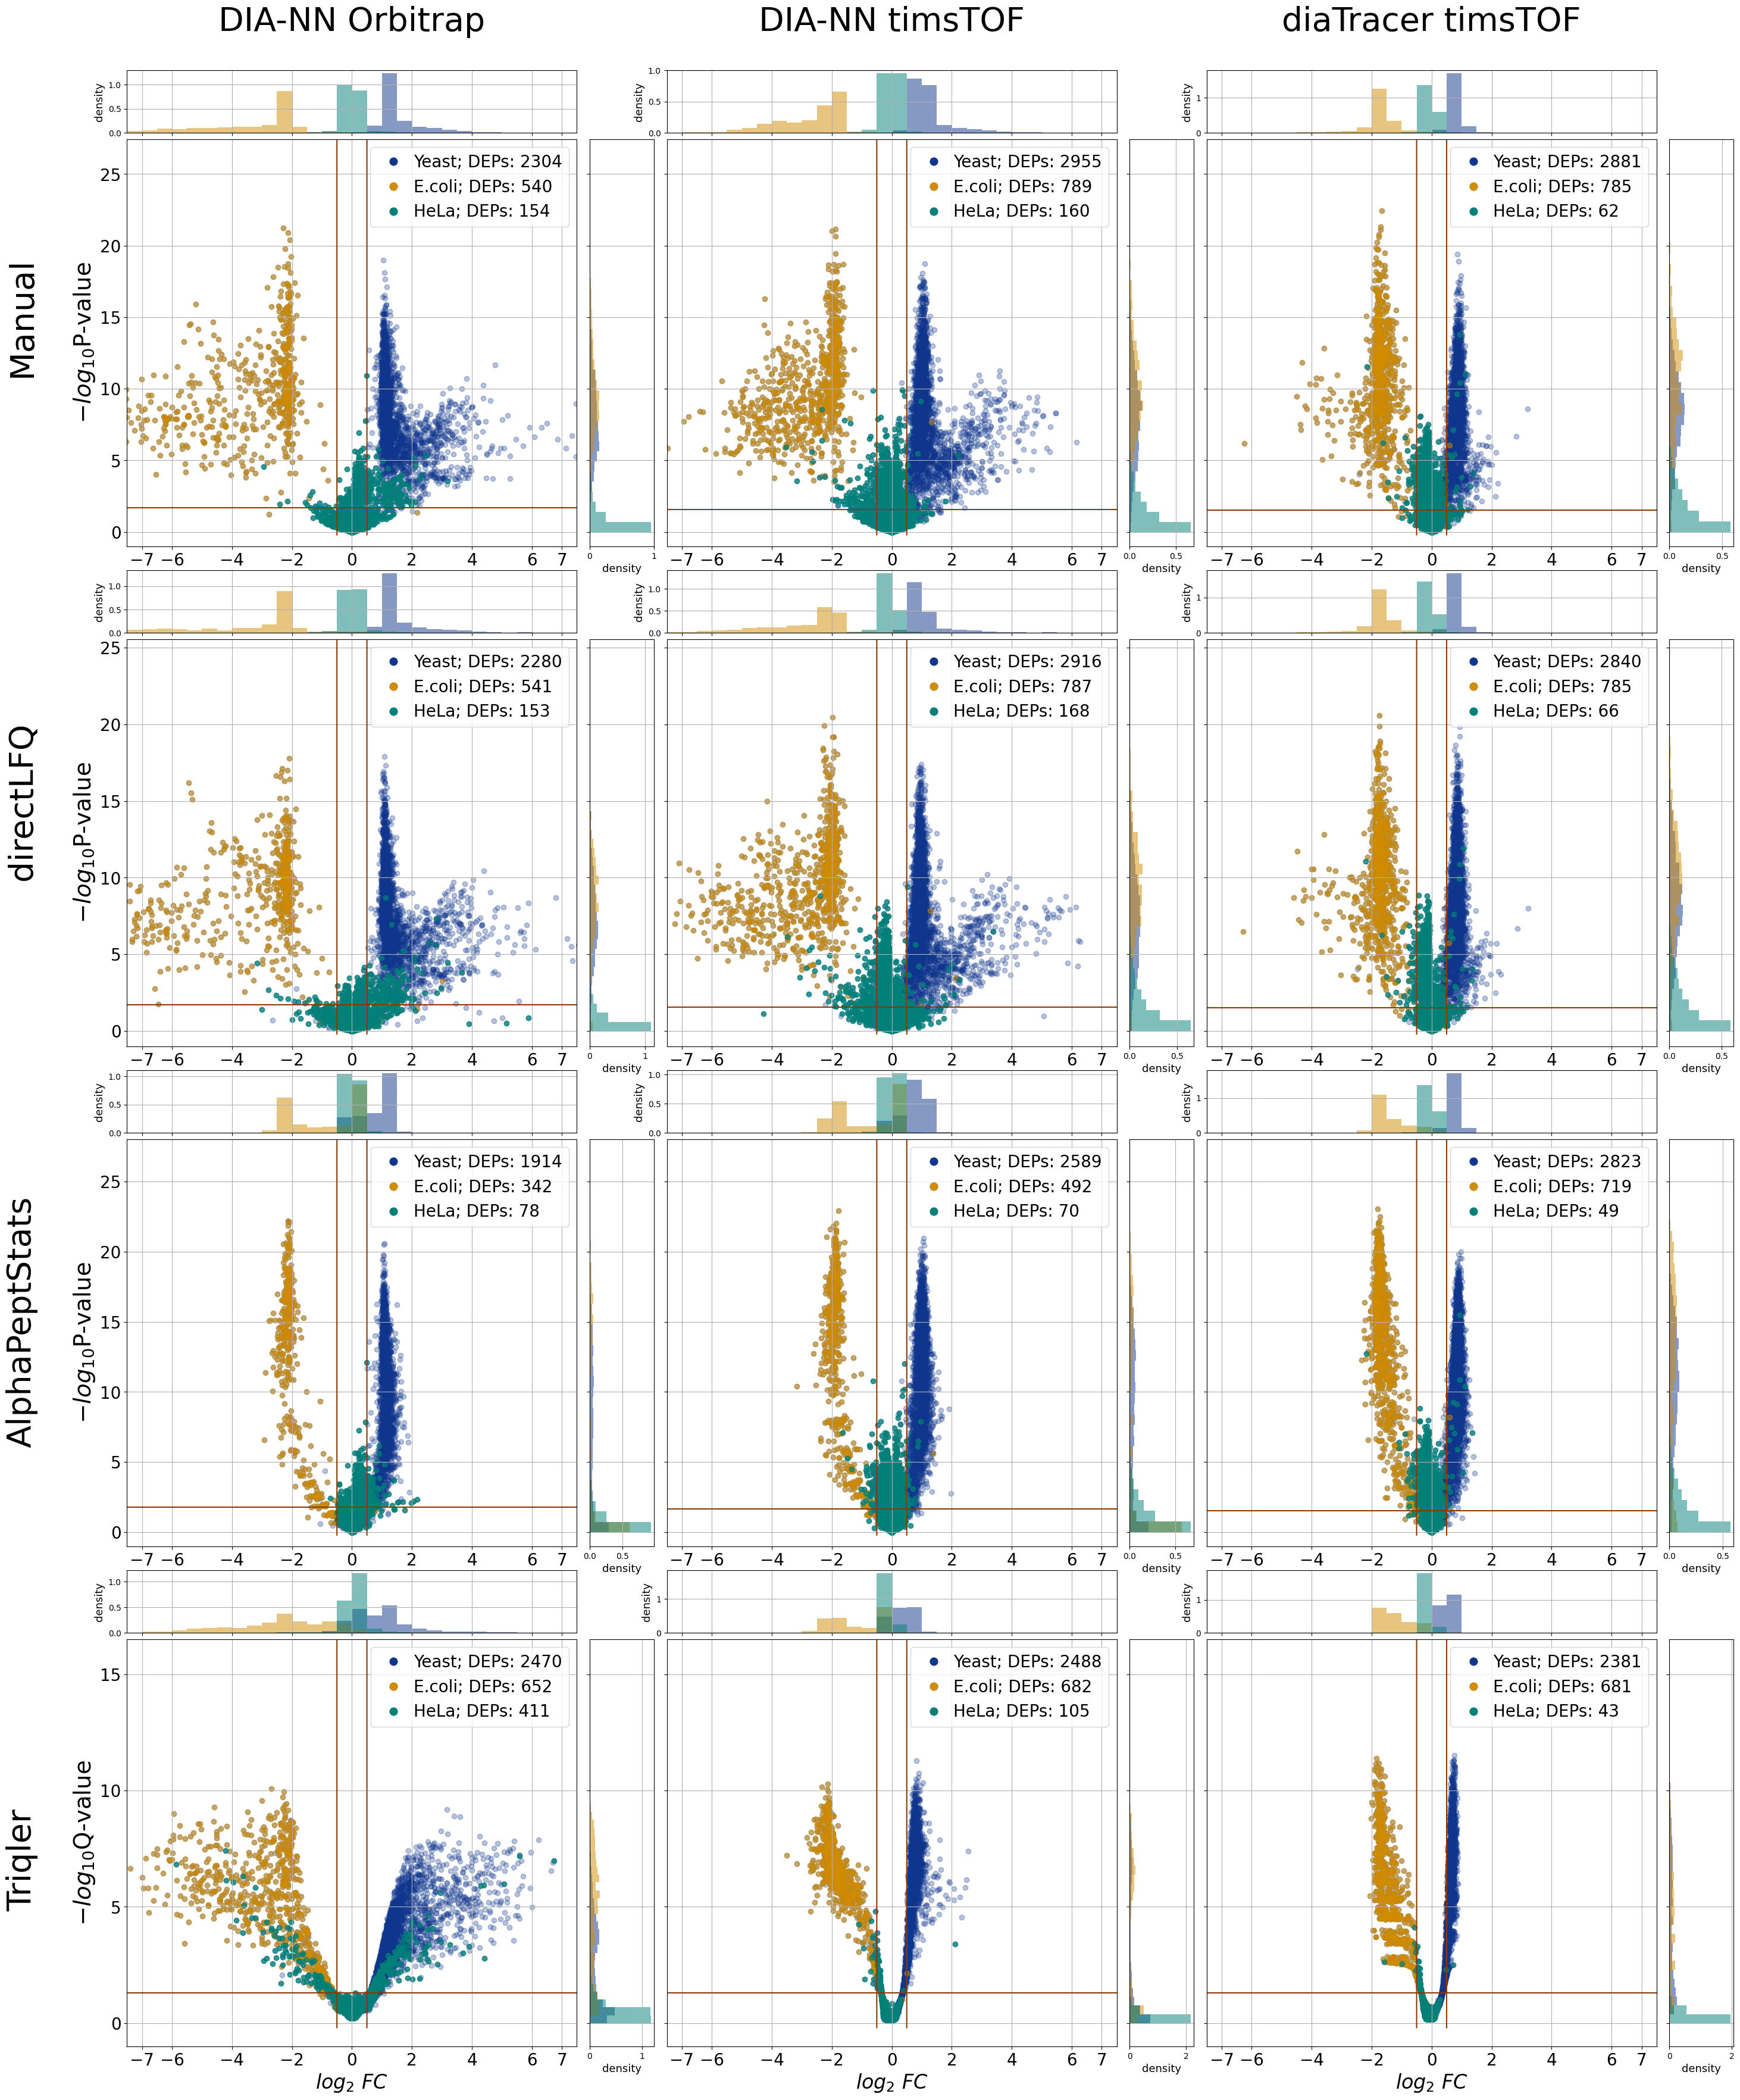

In [191]:
folder = './quantitation'
quant_tools = ['manual', 'directlfq', 'alphastats','triqler']

# quant_tools = ['manual', 'directLFQ', 'AlphaPeptStats','Triqler']
search_engines = {'diann':'DIA-NN Orbitrap',
                  'diann tof':'DIA-NN timsTOF', 
                  'diatracer':'diaTracer timsTOF', 
                  }

search_engines_file_mask = {  'diann':'diann231_LFQbench_quant_{}{}.tsv', 
                              'diann tof':'diann231_LFQbenchTOF_quant_{}{}.tsv', 
                              'diatracer':'fragpipe24_LFQbenchTOF_diatracer_quant_{}{}.tsv'}

quant_tools_full = {'manual':'Manual', 'directlfq':'directLFQ', 'alphastats':'AlphaPeptStats', 'triqler':'Triqler'}
alphastats_imp = 'mean'
imputation = {'alphastats':'_'+alphastats_imp, 'directlfq':'_min', 'manual':'_min', 'triqler':''}

fdr_col = {'manual':'pval', 'directlfq':'pval', 'alphastats':'pval','triqler':'q_value'}
fdr_pass = defaultdict(lambda:'FDR_pass')
fc_col = {'manual':'log2_FC', 'directlfq':'log2_FC', 'alphastats':'log2fc','triqler':'log2_FC'}
fc_pass = 'FC_pass'

colors = ['#008178', '#D28C00', '#0F358D', '#883B00', '#6482C6']
csfont = {'fontname':'sans-serif'}
base_fontsize = 20
cm = 1/2.54

fig = plt.figure(figsize=(30, 40))

h=0.2
space=0.01
zero_lvl = 0.9

xlim = [-7.5, 7.5]
xticks = [-7, -6, -4, -2, 0, 2, 4, 6, 7]
border_fc = 0.5


axes = []
for j in range(4) :
    bbot, ttop = zero_lvl-(j)*(space+h)-h, zero_lvl-(j)*(space+h)
    # print(bbot, ttop)
    axe1, axe2 = [], []
    gs1 = GridSpec(7, 21, bottom=bbot, top=ttop, left=0.05, right=0.95, wspace=0.2, hspace=0.1)
    mult = 7
    for i in range(3) :
        ax1 = fig.add_subplot(gs1[0, i*mult:(i+1)*mult-1])
        ax2 = fig.add_subplot(gs1[0, (i+1)*mult-1])
        ax3 = fig.add_subplot(gs1[1:, i*mult:(i+1)*mult-1])
        ax4 = fig.add_subplot(gs1[1:, (i+1)*mult-1])
        axe1.append(ax1)
        axe1.append(ax2)
        axe2.append(ax3)
        axe2.append(ax4)
    axes.append(axe1)
    axes.append(axe2)

mx_x = []
ll = 2

for j, quant in zip([0, 2, 4, 6], quant_tools) :
    up = []
    down = []
    mx_y = []
    reg_human = []
    reg_ecoli = []
    reg_yeast = []
    
    for i, engine in zip([0, 2, 4, ], search_engines) :
        filepath = path.join(folder, search_engines_file_mask[engine].format(quant, imputation[quant]))
        print(i, filepath)
        if quant == 'triqler' and engine == 'diatracer' :
            filepath = filepath.replace('_quant', '_triqler')
        elif quant == 'triqler' :
            filepath = filepath.replace('_quant', '')
        if quant == 'triqler' :
            if engine in ['diann tof', 'diatracer'] :
                filepath = filepath.replace('.tsv', '_035.tsv')
        print(i, filepath)
        table = pd.read_csv(filepath, sep = '\t')
        fdr_col_name = fdr_col[quant]
        # table['log2_FC'] = np.log2(table['s1']/table['s2'])
        # table['FC'] = table['s1']/table['s2']
        if 'Protein.Group' in table.columns :
            prot_col = 'Protein.Group'
        else :
            prot_col = 'protein'
        # table['Human'] = table[prot_col].apply(lambda x: True if (x.find('HUMAN') >= 0 and x.find('ECOLI') < 0 and x.find('YEAST') < 0) else False)
        # table['Ecoli'] = table[prot_col].apply(lambda x: True if (x.find('HUMAN') < 0 and x.find('ECOLI') >= 0 and x.find('YEAST') < 0) else False)
        # table['Yeast'] = table[prot_col].apply(lambda x: True if (x.find('HUMAN') < 0 and x.find('ECOLI') < 0 and x.find('YEAST') >= 0) else False)
    
        table.sort_values(fdr_col_name, ascending=True, inplace=True)
    
        x = np.array(table[fc_col[quant]])
        y = np.array(-np.log10(table[fdr_col_name]))
        mx_y.append(max(y))
        mx_x.append(max(abs(x)))
        human_mask = np.array(table['Human'] )
        ecoli_mask = np.array(table['Ecoli'] )
        yeast_mask = np.array(table['Yeast'] )
    
        num_proteins = len(table)
        xlim_sum = np.abs(xlim[1] - xlim[0])
        p_line_x = np.arange(xlim[0], xlim[1], xlim_sum/1000)
        if fdr_pass[quant] == 'Bonf_pass' :
            pval = 0.05/num_proteins
        else : 
            pval = max(table[table[fdr_pass[quant]]][fdr_col_name])
        p_y = -np.log10(pval)
        p_line_y = p_y*np.ones(len(p_line_x))
        axes[j+1][i].plot(p_line_x , p_line_y, color=colors[3])
        # print(quant, fdr_pass[quant], pval, p_y)
        
        area = np.array((x, y))
        log10_bonfferroni = -np.log10(0.05/num_proteins)
        bonfferroni = 0.05/num_proteins
    
        mask = []
        for log_fc, p in zip(x, y) :
            if abs(log_fc) >= border_fc and p >= log10_bonfferroni :
                mask.append(True)
            else :
                mask.append(False)
        mask = np.array( mask )
    
        # print(reg_human)
    #    fc_cond = abs(x)>= 1
    #    p_cond = p >= -np.log10(0.05)
    
        # np.ma.masked_where показывает только False маскируя True
        numbins = int(xlim_sum*2)
        xbbins = [xlim[0] + i*xlim_sum/numbins for i in range(numbins) ]
        ybbins = [0 + i*max(y)/numbins for i in range(numbins) ]
        # Yeast
        axes[j+1][i].scatter( np.ma.masked_where( human_mask & ecoli_mask, x), np.ma.masked_where(  human_mask & ecoli_mask , y),
                    color = colors[2], alpha = 0.3, label= 'Yeast')
    
        axes[j][i].hist(x[np.logical_and(~human_mask, ~ecoli_mask)], color = colors[2], alpha = 0.5, bins=xbbins, density=True)
        
        axes[j+1][i+1].hist(y[np.logical_and(~human_mask, ~ecoli_mask)], color = colors[2], orientation='horizontal', alpha = 0.5, bins=ybbins, density=True)
        # Это - E.coli
        axes[j+1][i].scatter( np.ma.masked_where( ~ecoli_mask , x), np.ma.masked_where( ~ecoli_mask , y),
                    color = colors[1], alpha = 0.5, label= 'E.coli')
        axes[j][i].hist(x[ecoli_mask], color = colors[1], alpha = 0.5, bins=xbbins, density=True)
        
        axes[j+1][i+1].hist(y[ecoli_mask], color = colors[1], orientation='horizontal', alpha = 0.5, bins=ybbins, density=True)
    
        # Это - Human
        axes[j+1][i].scatter( np.ma.masked_where( ~human_mask , x), np.ma.masked_where( ~human_mask , y),
                    color = colors[0], alpha = 0.7, label= 'Human')
        axes[j][i].hist(x[human_mask], color = colors[0], alpha = 0.5, bins=xbbins, density=True)
        
        axes[j+1][i+1].hist(y[human_mask], color = colors[0], orientation='horizontal', alpha = 0.5, bins=ybbins, density=True)
        
        reg_human.append(len(table[(table[fdr_pass[quant]] & table[fc_pass] & table['Human'])]))
        reg_ecoli.append(len(table[(table[fdr_pass[quant]] & table[fc_pass] & table['Ecoli'])]))
        reg_yeast.append(len(table[(table[fdr_pass[quant]] & table[fc_pass] & table['Yeast'])]))
        # print(engine, quant, reg_human[-1], reg_ecoli[-1], reg_yeast[-1])
        fig.delaxes(axes[j][i+1])

        xlim_sum = sum([abs(el) for el in xlim])
        axes[j+1][i].set_xlim(xlim)
        axes[j][i].set_xlim(xlim)
        axes[j+1][i].set_xticks(xticks)
        axes[j][i].set_xticks(xticks)
        axes[j+1][i].tick_params(axis='both', which='major', labelsize=base_fontsize)
        if i == 0 :
            if quant == 'triqler' :
                ax_stat_name = 'Q-value'
                axes[j+1][i].text(-11, 7, quant_tools_full[quant], size=base_fontsize*2, rotation=90, ha='center', va='center')
            else :
                ax_stat_name = 'P-value'
                axes[j+1][i].text(-11, 15, quant_tools_full[quant], size=base_fontsize*2, rotation=90, ha='center', va='center')
            axes[j+1][i].set_ylabel(r'$-log_{10}$' + ax_stat_name, size = base_fontsize*1.4, **csfont)
        else :
            axes[j+1][i].set_ylabel(r'', size = base_fontsize*0.6, **csfont)
        if j == 6 :
            axes[j+1][i].set_xlabel(r'$log_{2}\ FC$', size = base_fontsize*1.2, **csfont)
        elif j == 0 :
            axes[j+1][i].text(0, 35, search_engines[engine], size=base_fontsize*2, ha='center')
        else :
            axes[j+1][i].set_xlabel(r'', size = base_fontsize*0.6, **csfont)
        axes[j][i].set_ylabel('density', size = base_fontsize*0.65, **csfont)
        axes[j+1][i+1].set_xlabel('density', size = base_fontsize*0.65, rotation=0, **csfont)
        # axes[j][i].set_title(search_engines[engine]+' '+quant, size = 28, **csfont)
        
        legend_elements = [
                Line2D([0], [0], color = 'w', markerfacecolor = colors[2], marker = 'o', markersize = 5,
                          markeredgecolor = 'k',  markeredgewidth = .1, label = 'Yeast; DEPs: {}'.format(reg_yeast[-1])),
                Line2D([0], [0], color = 'w', markerfacecolor = colors[1], marker = 'o', markersize = 5,
                          markeredgecolor = 'k',  markeredgewidth = .1, label = 'E.coli; DEPs: {}'.format(reg_ecoli[-1])),
                Line2D([0], [0], color = 'w', markerfacecolor = colors[0], marker = 'o', markersize = 5,
                          markeredgecolor = 'k',  markeredgewidth = .1, label = 'HeLa; DEPs: {}'.format(reg_human[-1])),
                            ]
        axes[j+1][i].legend(handles = legend_elements, fontsize = base_fontsize, markerscale = 2., loc='upper right', handletextpad=0.2)  
        
    for i, hum, enum, ynum in zip([0, 2, 4, ], reg_human, reg_ecoli,reg_yeast ) :
        axes[j+1][i].set_yticks(np.arange(0, max(mx_y)+5, 5))
        axes[j+1][i+1].set_yticks(np.arange(0, max(mx_y)+5, 5))
        axes[j+1][i].set_ylim([-1, max(mx_y)+5])
        axes[j+1][i+1].set_ylim([-1, max(mx_y)+5])
        fc_line_y = np.arange(-0.2, max(mx_y)+5+0.2, 0.01)
        fc_line_x1 = border_fc*np.ones(len(fc_line_y),)
        fc_line_x2 = -border_fc*np.ones(len(fc_line_y),)
        axes[j+1][i].plot(fc_line_x1 , fc_line_y, color=colors[3])
        axes[j+1][i].plot(fc_line_x2 , fc_line_y, color=colors[3])
        text_y = max(mx_y)*0.7
        # axes[j+1][i].text( 4.05, text_y, 'Yeast: \nE.coli: \nHeLa: ', size = 20, style='italic')
        # axes[j+1][i].text( 5.75, text_y, '{}\n{}\n{}'.format(ynum, enum, hum), size = 20, color='red')
        axes[j+1][i+1].tick_params(axis="y", labelleft=False)
        axes[j][i+1].tick_params(axis="y", labelleft=False)
        axes[j][i].tick_params(axis="x", labelbottom=False)
        axes[j+1][i+1].grid()
        axes[j+1][i].grid()
        axes[j][i].grid()
        if i > 0 :
            axes[j+1][i].tick_params(axis="y", labelleft=False)

savepath = './figures/LFQbenchTOF_volcano_3x4.svg'
plt.savefig(savepath, format=savepath.split('.')[-1], dpi=300, bbox_inches='tight')
fig.show()